# Bray–Curtis NMDS (Non-metric Multidimensional Scaling)

> Source for the algorithm outline: https://uw.pressbooks.pub/appliedmultivariatestatistics/chapter/nmds/

## Brief introduction
NMDS is a <span style="color:red">distance-based</span> ordination method: you start from an $n\times n$ dissimilarity (distance) matrix (e.g., Bray–Curtis on community composition), and then place samples in a low-dimensional space (usually 2D/3D). The key idea is **rank preservation**: NMDS tries to arrange points so that pairs of samples that are more similar in the original dissimilarities end up closer together in the ordination, and pairs that are more dissimilar end up farther apart. Because it works from a distance matrix, NMDS is flexible about the choice of distance measure and is commonly used for visualization / data reduction.

## Steps (from the UW Pressbooks chapter, paraphrased)
### Pre-NMDS (initial) steps
1. Start with either (a) a community matrix (samples × taxa) or (b) a precomputed dissimilarity matrix. If you already have a dissimilarity matrix, you can skip most preprocessing steps.
2. Apply any transformations / standardizations you want **before** NMDS (the chapter notes `metaMDS()` can auto-transform, but recommends turning that off for clarity).
3. Convert the community matrix into a dissimilarity matrix using <span style="color:red">an appropriate distance</span> (Bray–Curtis is a common default).
4. Choose the NMDS <span style="color:red">solver</spam>/engine (e.g., `monoMDS` vs `isoMDS` in `vegan`).
5. Decide how to handle many pairs with identical/maximum dissimilarities in long gradients (e.g., weak ties / step-across approaches, depending on the engine).

### NMDS (algorithm) steps
1. Choose the target dimensionality $k$ (e.g., 2D or 3D).
2. Pick <span style="color:red">a starting configuration</span> (random starts, or initialize from another ordination like PCoA, or the spatial related coordinates if they are spatial-correlated).
3. Compute Euclidean distances among samples in the current ordination space.
4. Compare those fitted ordination distances to the original dissimilarities using a monotonic (rank-based) relationship; <span style="color:red">summarize mismatch as **stress**</spam>.
5. Check whether the fit is good enough (stopping criteria / **convergence rules**).
6. If not converged, update point positions to reduce stress (iterative optimization, e.g., steepest descent).
7. <span style="color:red">Repeat</span> steps 3–6 until convergence or a maximum iteration limit is reached.
8. Repeat the whole run from <span style="color:red">different starting configurations</span> to reduce the risk of getting stuck in **a local minimum****; keep the best (lowest-stress) solution.

### Post-NMDS steps
1. Optionally re-center / rotate / rescale the final configuration to **aid** visualization (axes are arbitrary in NMDS).
2. Optionally compute **species scores** (e.g., weighted-average scores) if you want to overlay taxa patterns on the ordination.

In [ ]:
# ── Imports ────────────────────────────────────────────────────────────────────
import sys, pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist, squareform
from sklearn.manifold import MDS            # metric / non-metric MDS
from matplotlib.lines import Line2D

# make sure the project src package is importable
SRC = pathlib.Path("../src").resolve()
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from zci.io.readers import extract_block
from zci.models.clustering import TAXA_COLUMNS

print("TAXA_COLUMNS:", TAXA_COLUMNS)
print("imports ok ✓")

TAXA_COLUMNS: ['Acari', 'Amphipoda', 'Caenis', 'Ceratopogonidae', 'Chironomidae', 'Dreissena', 'Gastropoda', 'Hexagenia', 'Hirudinea', 'Hydropsychidae', 'Hydrozoa', 'Nematoda', 'Oligochaeta', 'Other Trichoptera', 'Sphaeriidae', 'Turbellaria']
imports ok ✓


## 1 · Load the complete raw data

In [77]:
# Read the master data file (3-level MultiIndex columns, StationID as index)
DATA_PATH = "../data/processed/complete_env_taxa_chemical_Feb_3.xlsx"
data = pd.read_excel(DATA_PATH, header=[0, 1, 2], index_col=0)
print("data shape:", data.shape)

# Extract the taxa block (octave-transformed abundances, 16 taxa)
taxa_all = extract_block(data, "taxa", "raw")[list(TAXA_COLUMNS)]
print("taxa_all shape:", taxa_all.shape)
taxa_all.head()

data shape: (233, 56)
taxa_all shape: (233, 16)


var,Acari,Amphipoda,Caenis,Ceratopogonidae,Chironomidae,Dreissena,Gastropoda,Hexagenia,Hirudinea,Hydropsychidae,Hydrozoa,Nematoda,Oligochaeta,Other Trichoptera,Sphaeriidae,Turbellaria
StationID,,,,,,,,,,,,,,,,
003ABC,3.203427e-16,4.529993e+00,3.203427e-16,3.203427e-16,1.655598,6.082918,3.203427e-16,3.091164e-01,3.203427e-16,2.438439e+00,3.203427e-16,0.563546,2.269984,3.203427e-16,3.203427e-16,3.203427e-16
004ABC,8.019817e-01,3.203427e-16,3.203427e-16,3.203427e-16,6.242625,0.801982,4.560146e-01,3.203427e-16,3.203427e-16,3.203427e-16,3.203427e-16,3.512091,3.808504,3.203427e-16,3.203427e-16,3.203427e-16
005ABC,1.010022e+00,3.203427e-16,3.203427e-16,3.203427e-16,4.733464,0.172158,4.649067e-01,8.159494e-01,3.203427e-16,3.203427e-16,3.203427e-16,5.519382,4.820163,3.203427e-16,3.203427e-16,3.203427e-16
007ABC,3.203427e-16,1.840242e+00,3.394136e-02,3.203427e-16,2.271083,6.475708,3.203427e-16,9.995729e-01,2.302695e-01,3.203427e-16,1.820930e+00,0.181596,1.449187,3.203427e-16,3.203427e-16,3.203427e-16
008A,3.203427e-16,4.224262e+00,3.203427e-16,3.203427e-16,2.499653,6.266368,2.463713e-01,1.284384e-01,3.203427e-16,1.284384e-01,3.203427e-16,0.246371,1.082238,3.203427e-16,3.203427e-16,3.203427e-16


## 2 · Load pollution scores (stage 01) and cluster labels (stage 03)

In [ ]:
# ── Stage 01: pollution score ─────────────────────────────────────────────────
STAGE1_PATH = "../results/01_pollution_assessment/artifacts/01_updated_data.xlsx"
stage1 = pd.read_excel(STAGE1_PATH, header=[0, 1, 2], index_col=0)
pollution_score = stage1.loc[:, ("01_pollution_assessment", "raw", "Pollution_Score")]
pollution_score.name = "Pollution_Score"
print("Pollution scores shape:", pollution_score.shape)

# ── Stage 03: cluster labels for ALL sites (ref + non-ref via LDA) ───────────
STAGE3_PATH = "../results/03_LDA_Classification/artifacts/03_updated_data.xlsx"
stage3 = pd.read_excel(STAGE3_PATH, header=[0, 1, 2], index_col=0)
cluster_label = stage3.loc[:, ("03_lda_classification", "raw", "Predicted_Cluster")]
cluster_label.name = "Cluster"
is_reference = stage3.loc[:, ("03_lda_classification", "raw", "Is_Reference")]
is_reference.name = "Is_Reference"
print("Cluster labels shape:", cluster_label.shape)
print("Cluster value counts:\n", cluster_label.value_counts().sort_index())

Pollution scores shape: (233,)
Cluster labels shape: (233,)
Cluster value counts:
 Cluster
1    204
2     29
Name: count, dtype: int64


## 3 · Merge into a single site-level DataFrame

In [79]:
# Build a site-level metadata frame joined on StationID (the shared index)
site_meta = pd.DataFrame({
    "Pollution_Score": pollution_score,
    "Cluster":         cluster_label.astype(int),
    "Is_Reference":    is_reference.astype(int),
})

# Restrict to sites that appear in both the taxa matrix and the metadata
common_idx = taxa_all.index.intersection(site_meta.index)
site_meta = site_meta.loc[common_idx]
taxa      = taxa_all.loc[common_idx]

print(f"Sites retained: {len(common_idx)}")
print(f"\nSite metadata head:\n{site_meta.head()}")
print(f"\nCluster counts:\n{site_meta['Cluster'].value_counts().sort_index()}")

Sites retained: 233

Site metadata head:
           Pollution_Score  Cluster  Is_Reference
StationID                                        
003ABC            2.904155        1             0
004ABC            2.177275        1             1
005ABC            2.465428        1             0
007ABC            3.635129        1             0
008A              2.676289        1             0

Cluster counts:
Cluster
1    204
2     29
Name: count, dtype: int64


## 4 · Bray-Curtis NMDS within each cluster

For each cluster we:
1. Subset the taxa matrix to the sites belonging to that cluster.
2. Compute the pairwise **Bray-Curtis dissimilarity** matrix.
3. Run **non-metric MDS** (NMDS) on the dissimilarity matrix (2-D, random init).
4. Report stress and plot the ordination, colouring points by Reference / Non-Reference status and sizing by Pollution Score.

> The starting configuration here is **random** (`init=None`).  
> Later you can swap in a PCoA-based or other initialization and re-run to check convergence.

In [80]:
# ── Helper: run NMDS on a Bray-Curtis dissimilarity matrix ────────────────────
def run_nmds_braycurtis(
    taxa_df: pd.DataFrame,
    n_components: int = 2,
    max_iter: int = 300,
    n_init: int = 10,
    random_state: int = 42,
    init: np.ndarray | None = None,
):
    """
    Compute Bray-Curtis dissimilarity, then fit non-metric MDS.

    Parameters
    ----------
    taxa_df : DataFrame (sites × taxa)
    n_components : target dimensionality
    max_iter : maximum iterations per run
    n_init : number of random restarts (ignored when init is provided)
    random_state : seed
    init : optional starting configuration (n_sites × n_components)

    Returns
    -------
    coords : DataFrame  – NMDS coordinates (sites × dims)
    stress  : float      – final stress (Kruskal stress-1)
    dist_mat: DataFrame  – Bray-Curtis distance matrix
    """
    # 1. Bray-Curtis distance matrix
    bc_dists = pdist(taxa_df.values, metric="braycurtis")
    bc_square = squareform(bc_dists)
    dist_df = pd.DataFrame(bc_square, index=taxa_df.index, columns=taxa_df.index)

    # 2. Non-metric MDS
    #    NOTE: sklearn ≥1.8 restricts the *constructor* `init` to strings
    #    ('random', 'classical_mds').  Custom ndarray inits must be passed
    #    to fit_transform(X, init=...) instead.
    nmds = MDS(
        n_components=n_components,
        metric_mds=False,             # non-metric
        metric="precomputed",
        max_iter=max_iter,
        n_init=1 if init is not None else n_init,
        init="random",                # placeholder string for constructor
        random_state=random_state,
        normalized_stress="auto",
    )
    coords_arr = nmds.fit_transform(bc_square, init=init)

    coords = pd.DataFrame(
        coords_arr,
        index=taxa_df.index,
        columns=[f"NMDS{i+1}" for i in range(n_components)],
    )
    return coords, nmds.stress_, dist_df


print("run_nmds_braycurtis() defined ✓")

run_nmds_braycurtis() defined ✓


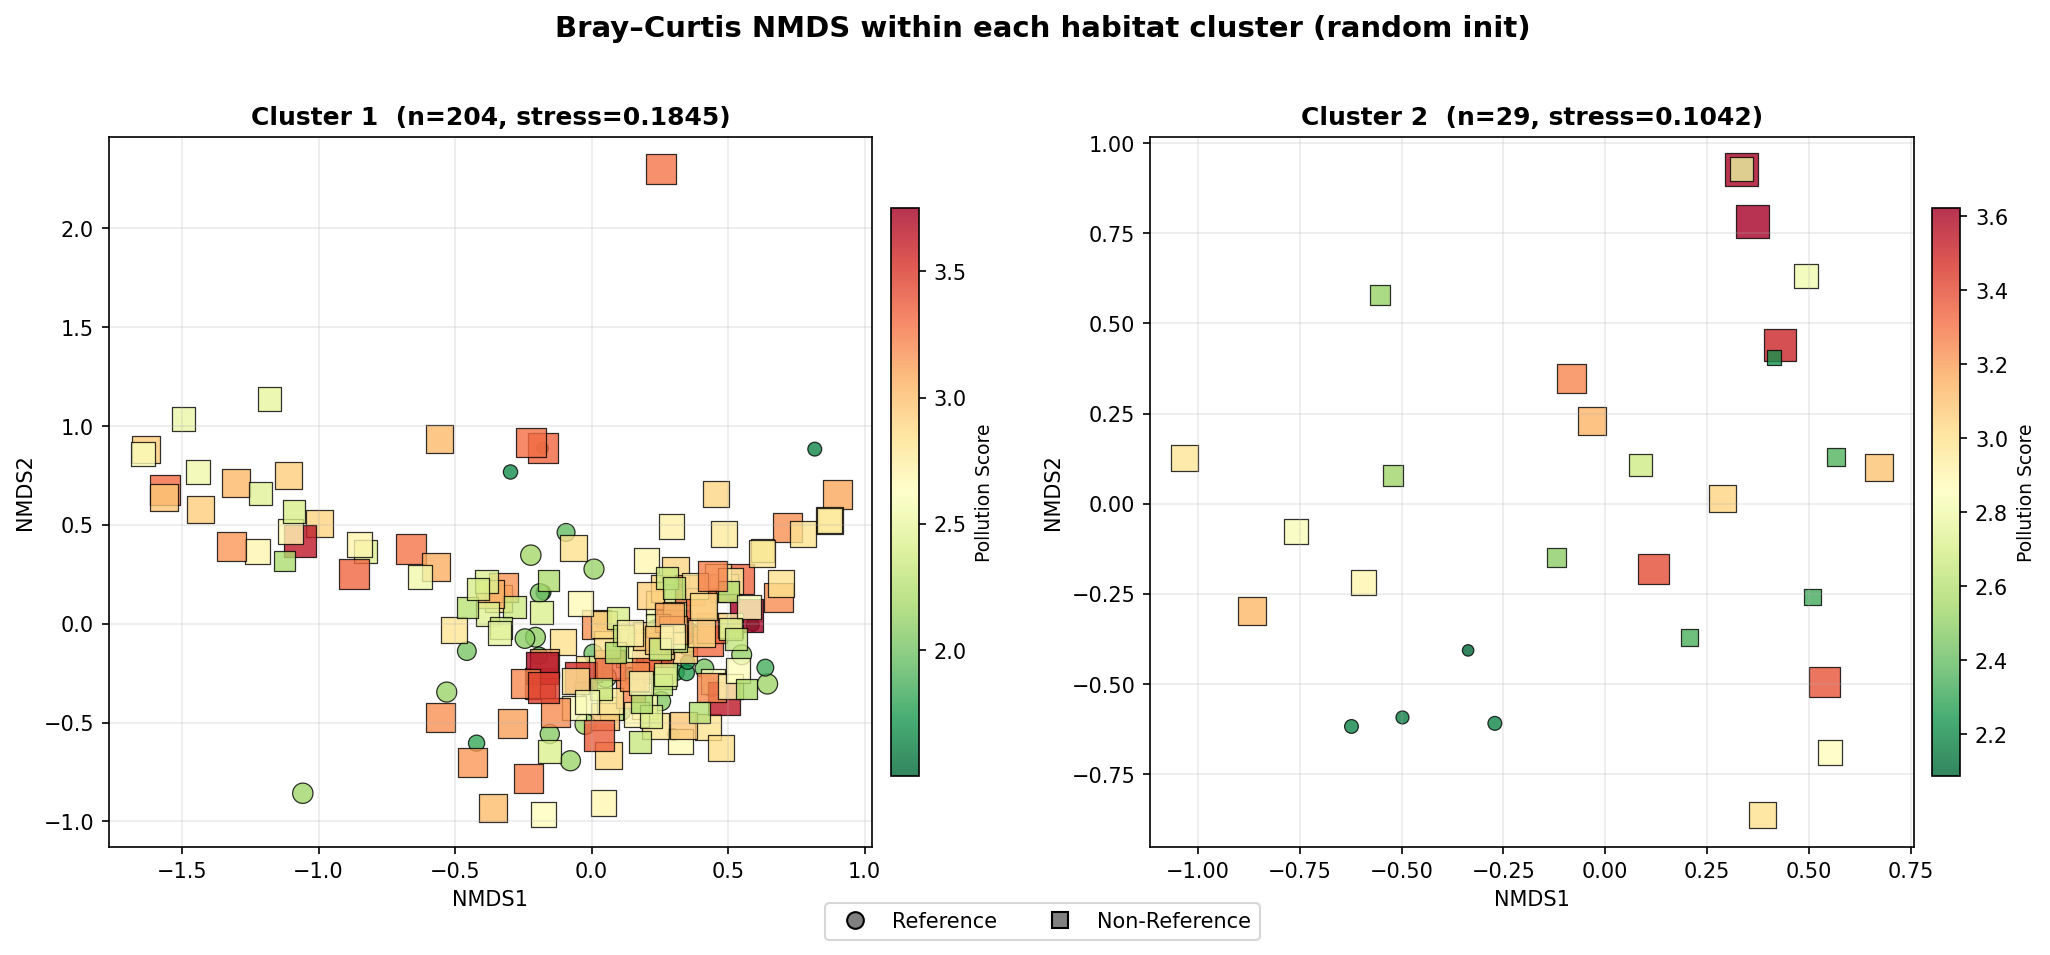


 Cluster   n_sites      Stress
------------------------------------------------------------
       1       204      0.1845
       2        29      0.1042


In [81]:
# ── Run NMDS per cluster and plot ─────────────────────────────────────────────

clusters = sorted(site_meta["Cluster"].unique())
n_clusters = len(clusters)

fig, axes = plt.subplots(1, n_clusters, figsize=(7 * n_clusters, 6), dpi=150)
if n_clusters == 1:
    axes = [axes]

# Store results so you can re-use / re-init later
nmds_results = {}  # cluster -> (coords, stress, dist_mat)

for ax, cl in zip(axes, clusters):
    # ---- subset ----
    cl_sites = site_meta.index[site_meta["Cluster"] == cl]
    taxa_cl  = taxa.loc[cl_sites]
    meta_cl  = site_meta.loc[cl_sites]

    # ---- NMDS (random start) ----
    coords, stress, dist_mat = run_nmds_braycurtis(
        taxa_cl,
        n_components=2,
        max_iter=300,
        n_init=10,
        random_state=42,
    )
    nmds_results[cl] = (coords, stress, dist_mat)

    # ---- plot ----
    ref_mask = meta_cl["Is_Reference"] == 1
    ps = meta_cl["Pollution_Score"]
    # normalise pollution score for marker size (30–250)
    ps_norm = (ps - ps.min()) / (ps.max() - ps.min() + 1e-9) * 220 + 30

    # reference sites  → circles, non-ref → squares
    ax.scatter(
        coords.loc[ref_mask, "NMDS1"], coords.loc[ref_mask, "NMDS2"],
        s=ps_norm[ref_mask], c=ps[ref_mask], cmap="RdYlGn_r",
        marker="o", edgecolors="k", linewidths=0.6, alpha=0.8,
        vmin=ps.min(), vmax=ps.max(),
    )
    sc = ax.scatter(
        coords.loc[~ref_mask, "NMDS1"], coords.loc[~ref_mask, "NMDS2"],
        s=ps_norm[~ref_mask], c=ps[~ref_mask], cmap="RdYlGn_r",
        marker="s", edgecolors="k", linewidths=0.6, alpha=0.8,
        vmin=ps.min(), vmax=ps.max(),
    )

    ax.set_title(f"Cluster {cl}  (n={len(cl_sites)}, stress={stress:.4f})",
                 fontsize=12, fontweight="bold")
    ax.set_xlabel("NMDS1")
    ax.set_ylabel("NMDS2")
    ax.grid(alpha=0.25)

    # colour-bar for pollution score
    cb = fig.colorbar(sc, ax=ax, shrink=0.8, pad=0.02)
    cb.set_label("Pollution Score", fontsize=9)

# shared legend
legend_handles = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor="gray",
           markeredgecolor="k", markersize=8, label="Reference"),
    Line2D([0], [0], marker="s", color="w", markerfacecolor="gray",
           markeredgecolor="k", markersize=8, label="Non-Reference"),
]
fig.legend(handles=legend_handles, loc="lower center", ncol=2, fontsize=10,
           frameon=True, bbox_to_anchor=(0.5, -0.02))

fig.suptitle("Bray–Curtis NMDS within each habitat cluster (random init)",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

# ── Summary table ────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print(f"{'Cluster':>8}  {'n_sites':>8}  {'Stress':>10}")
print("-" * 60)
for cl in clusters:
    coords, stress, _ = nmds_results[cl]
    print(f"{cl:>8}  {len(coords):>8}  {stress:>10.4f}")
print("=" * 60)

## 5 · Shepard (stress) plots – evaluating NMDS fit

For each cluster we plot the **original Bray-Curtis dissimilarities** against the **Euclidean distances in ordination space**.  
A tight monotonic relationship → good NMDS fit.

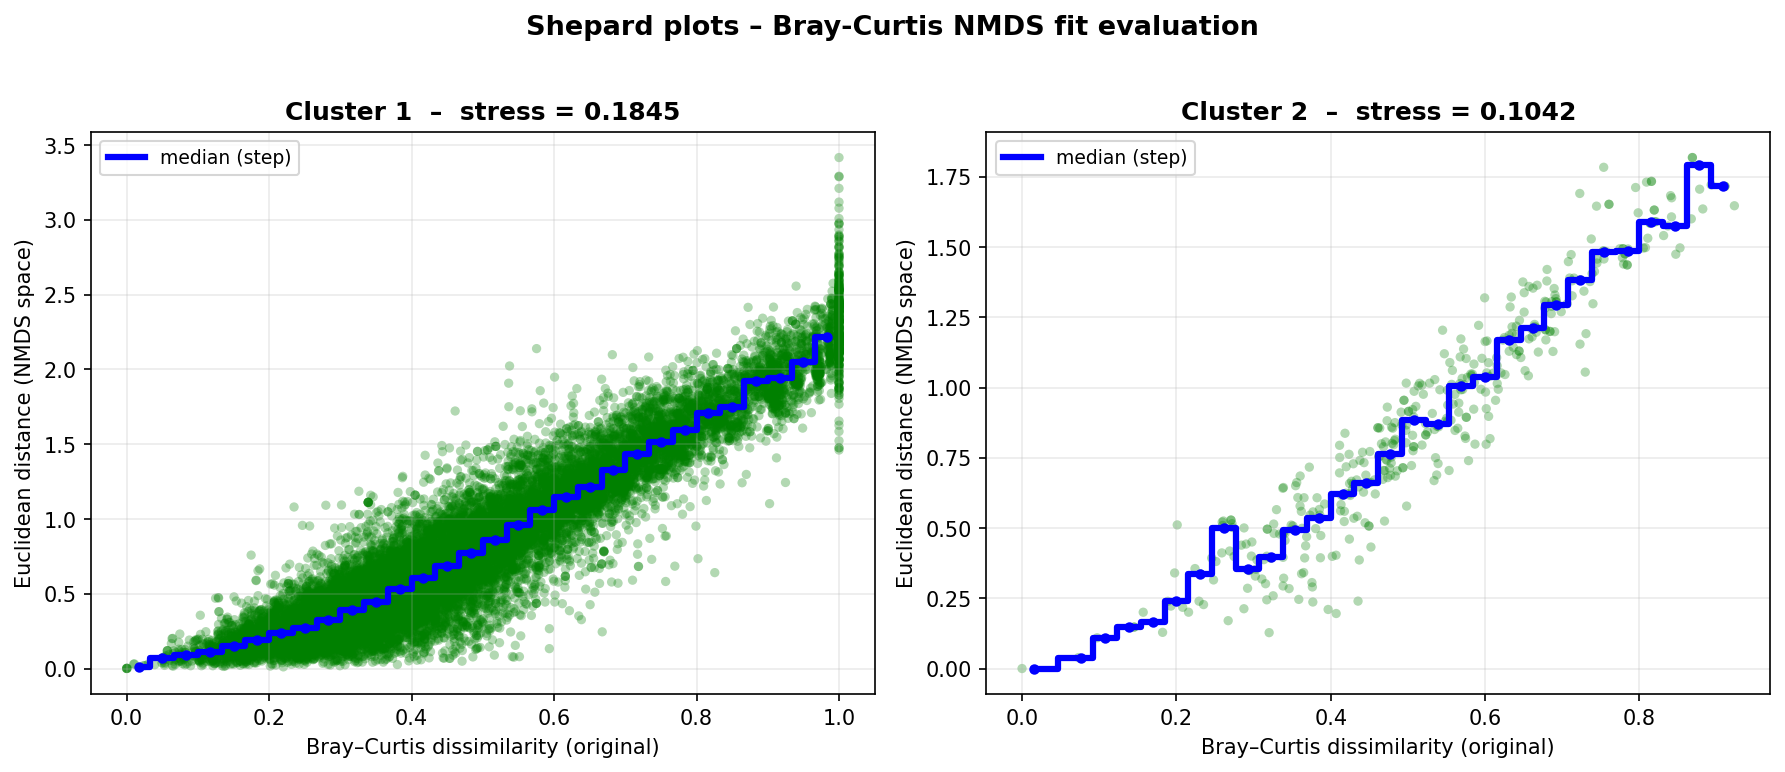

In [82]:
# ── Shepard plots per cluster – step curve through bin medians ─────────────────
from scipy.spatial.distance import pdist as _pdist, squareform as _sqf

N_BINS = 30   # number of equal-width bins along the BC dissimilarity axis

fig, axes = plt.subplots(1, n_clusters, figsize=(6 * n_clusters, 5), dpi=150)
if n_clusters == 1:
    axes = [axes]

for ax, cl in zip(axes, clusters):
    coords, stress, dist_mat = nmds_results[cl]

    # original BC distances (upper triangle, condensed)
    orig = dist_mat.values[np.triu_indices(len(dist_mat), k=1)]

    # ordination-space Euclidean distances
    ord_dists = _sqf(_pdist(coords.values, metric="euclidean"))
    ordi = ord_dists[np.triu_indices(len(coords), k=1)]
    
    # scatter plot of all points
    ax.scatter(orig, ordi, alpha=0.3, s=20, color="green", edgecolors="none")
    # Bin BC values; compute median ordination distance per bin
    bin_edges = np.linspace(orig.min(), orig.max(), N_BINS + 1)
    bin_idx   = np.clip(np.digitize(orig, bin_edges) - 1, 0, N_BINS - 1)

    bin_x, bin_y = [], []
    for b in range(N_BINS):
        mask = bin_idx == b
        if mask.sum() > 0:
            bin_x.append((bin_edges[b] + bin_edges[b + 1]) / 2)
            bin_y.append(np.median(ordi[mask]))

    bin_x = np.array(bin_x)
    bin_y = np.array(bin_y)

    # Step curve – horizontal segment at each bin's median, transitioning at bin boundaries
    ax.step(bin_x, bin_y, where="mid", color="blue", lw=3.0, label="median (step)")
    ax.plot(bin_x, bin_y, "o", color="blue", ms=4, zorder=3)

    ax.set_xlabel("Bray–Curtis dissimilarity (original)")
    ax.set_ylabel("Euclidean distance (NMDS space)")
    ax.set_title(f"Cluster {cl}  –  stress = {stress:.4f}", fontweight="bold")
    ax.grid(alpha=0.25)
    ax.legend(fontsize=9)

fig.suptitle("Shepard plots – Bray-Curtis NMDS fit evaluation",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


## 6 · (Next) Re-run with custom starting configuration

To try a **different initialization** (e.g., PCoA, prior ordination coordinates, or spatial coordinates), pass it via the `init` parameter of `run_nmds_braycurtis()`:

```python
# Example: PCoA-based init for a given cluster
from sklearn.manifold import MDS as _MDS
pcoa = _MDS(n_components=2, dissimilarity="precomputed", normalized_stress="auto")
init_coords = pcoa.fit_transform(nmds_results[cl][2].values)  # metric MDS on BC matrix

coords_new, stress_new, _ = run_nmds_braycurtis(
    taxa.loc[site_meta["Cluster"] == cl],
    init=init_coords,
    max_iter=500,
)
```

You can iterate: compare stresses across different inits and increase `max_iter` until convergence.

## 6a · Re-run NMDS with PCoA-based starting configuration

Instead of random starting coordinates we use **metric MDS (≈ PCoA)** on each cluster's Bray-Curtis distance matrix as the initial configuration, then refine with non-metric MDS.  This often converges faster and avoids poor local minima.

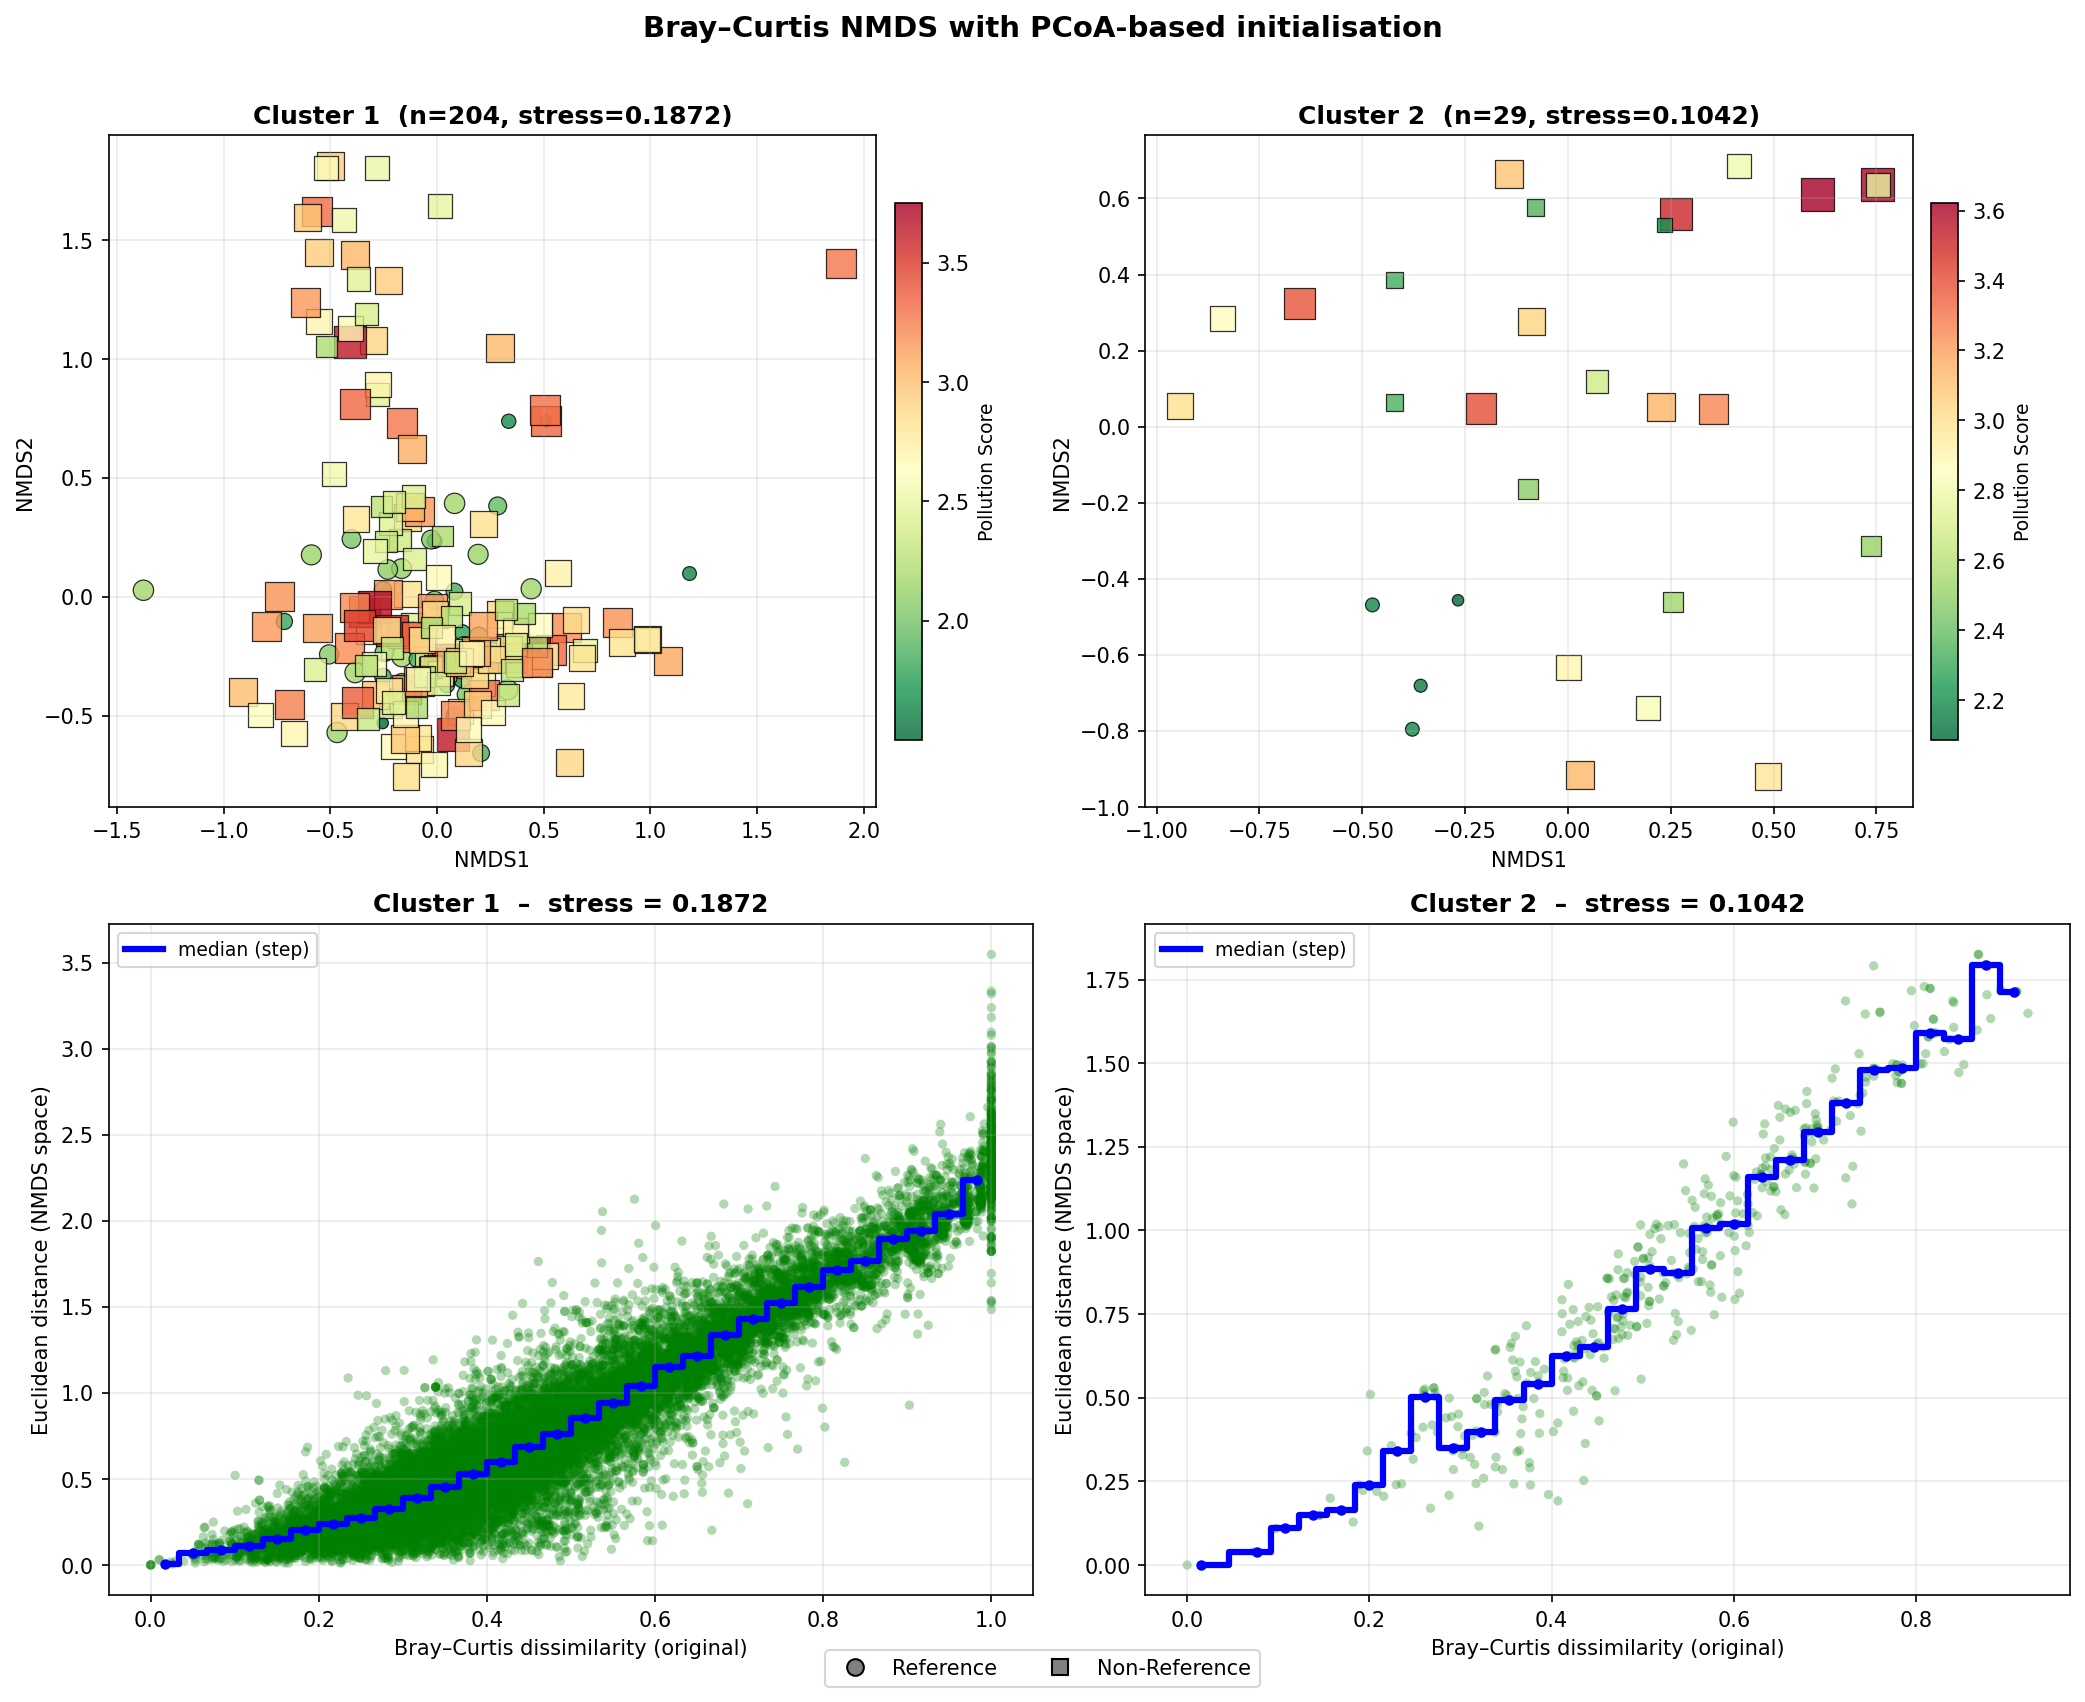


 Cluster   n_sites    Stress (PCoA init)
------------------------------------------------------------
       2        29              0.104192


In [83]:
# ── PCoA-initialised NMDS per cluster ─────────────────────────────────────────
from sklearn.manifold import MDS as _MDS
from scipy.spatial.distance import pdist as _pdist, squareform as _sqf

nmds_results_pcoa = {}  # cluster -> (coords, stress, dist_mat)

# ── Row 1: ordination plots  |  Row 2: Shepard plots ─────────────────────────
fig, axes = plt.subplots(2, n_clusters, figsize=(7 * n_clusters, 11), dpi=150)
if n_clusters == 1:
    axes = axes.reshape(2, 1)

for col_i, cl in enumerate(clusters):
    # ---- subset (same sites as the random-init run) ----
    cl_sites = site_meta.index[site_meta["Cluster"] == cl]
    taxa_cl  = taxa.loc[cl_sites]
    meta_cl  = site_meta.loc[cl_sites]
    bc_mat   = nmds_results[cl][2].values            # reuse stored BC matrix

    # ---- PCoA (metric MDS) → initial coordinates ----
    pcoa = _MDS(
        n_components=2,
        metric="precomputed",
        n_init=4,
        init="random",
        normalized_stress="auto",
        random_state=42,
    )
    init_coords = pcoa.fit_transform(bc_mat)

    # ---- NMDS with PCoA init ----
    coords, stress, dist_mat = run_nmds_braycurtis(
        taxa_cl,
        n_components=2,
        max_iter=500,
        init=init_coords,
        random_state=42,
    )
    nmds_results_pcoa[cl] = (coords, stress, dist_mat)

    # ==================== top row: ordination ====================
    ax = axes[0, col_i]
    ref_mask = meta_cl["Is_Reference"] == 1
    ps = meta_cl["Pollution_Score"]
    ps_norm = (ps - ps.min()) / (ps.max() - ps.min() + 1e-9) * 220 + 30

    ax.scatter(
        coords.loc[ref_mask, "NMDS1"], coords.loc[ref_mask, "NMDS2"],
        s=ps_norm[ref_mask], c=ps[ref_mask], cmap="RdYlGn_r",
        marker="o", edgecolors="k", linewidths=0.6, alpha=0.8,
        vmin=ps.min(), vmax=ps.max(),
    )
    sc = ax.scatter(
        coords.loc[~ref_mask, "NMDS1"], coords.loc[~ref_mask, "NMDS2"],
        s=ps_norm[~ref_mask], c=ps[~ref_mask], cmap="RdYlGn_r",
        marker="s", edgecolors="k", linewidths=0.6, alpha=0.8,
        vmin=ps.min(), vmax=ps.max(),
    )
    ax.set_title(f"Cluster {cl}  (n={len(cl_sites)}, stress={stress:.4f})",
                 fontsize=12, fontweight="bold")
    ax.set_xlabel("NMDS1")
    ax.set_ylabel("NMDS2")
    ax.grid(alpha=0.25)
    cb = fig.colorbar(sc, ax=ax, shrink=0.8, pad=0.02)
    cb.set_label("Pollution Score", fontsize=9)

    # ==================== bottom row: Shepard step-curve ====================
    ax2 = axes[1, col_i]
    orig = dist_mat.values[np.triu_indices(len(dist_mat), k=1)]
    ord_dists = _sqf(_pdist(coords.values, metric="euclidean"))
    ordi = ord_dists[np.triu_indices(len(coords), k=1)]
    # scatter plot of all pairwise points
    ax2.scatter(orig, ordi, alpha=0.3, s=20, color="green", edgecolors="none")

    bin_edges = np.linspace(orig.min(), orig.max(), N_BINS + 1)
    bin_idx   = np.clip(np.digitize(orig, bin_edges) - 1, 0, N_BINS - 1)
    bx, by = [], []
    for b in range(N_BINS):
        m = bin_idx == b
        if m.sum() > 0:
            bx.append((bin_edges[b] + bin_edges[b + 1]) / 2)
            by.append(np.median(ordi[m]))
    bx, by = np.array(bx), np.array(by)

    ax2.step(bx, by, where="mid", color="blue", lw=3.0, label="median (step)")
    ax2.plot(bx, by, "o", color="blue", ms=4, zorder=3)
    ax2.set_xlabel("Bray–Curtis dissimilarity (original)")
    ax2.set_ylabel("Euclidean distance (NMDS space)")
    ax2.set_title(f"Cluster {cl}  –  stress = {stress:.4f}", fontweight="bold")
    ax2.grid(alpha=0.25)
    ax2.legend(fontsize=9)

# shared legend for ordination row
legend_handles = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor="gray",
           markeredgecolor="k", markersize=8, label="Reference"),
    Line2D([0], [0], marker="s", color="w", markerfacecolor="gray",
           markeredgecolor="k", markersize=8, label="Non-Reference"),
]
fig.legend(handles=legend_handles, loc="lower center", ncol=2, fontsize=10,
           frameon=True, bbox_to_anchor=(0.5, -0.01))

fig.suptitle("Bray–Curtis NMDS with PCoA-based initialisation",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

# quick stress summary
print("\n" + "=" * 60)
print(f"{'Cluster':>8}  {'n_sites':>8}  {'Stress (PCoA init)':>20}")
print("-" * 60)
c, s, _ = nmds_results_pcoa[cl]
print(f"{cl:>8}  {len(c):>8}  {s:>20.6f}")
print("=" * 60)
    

## 6b · Compare Random-init vs PCoA-init NMDS

Side-by-side comparison of stress values and Procrustes-style visual overlay to see whether the PCoA-based initialization improved the NMDS solution.

 Cluster   n_sites   Stress (random)     Stress (PCoA)    Δ stress
------------------------------------------------------------------------
       1       204          0.184492          0.187194   +0.002702  ← worse
       2        29          0.104176          0.104192   +0.000016  ← worse


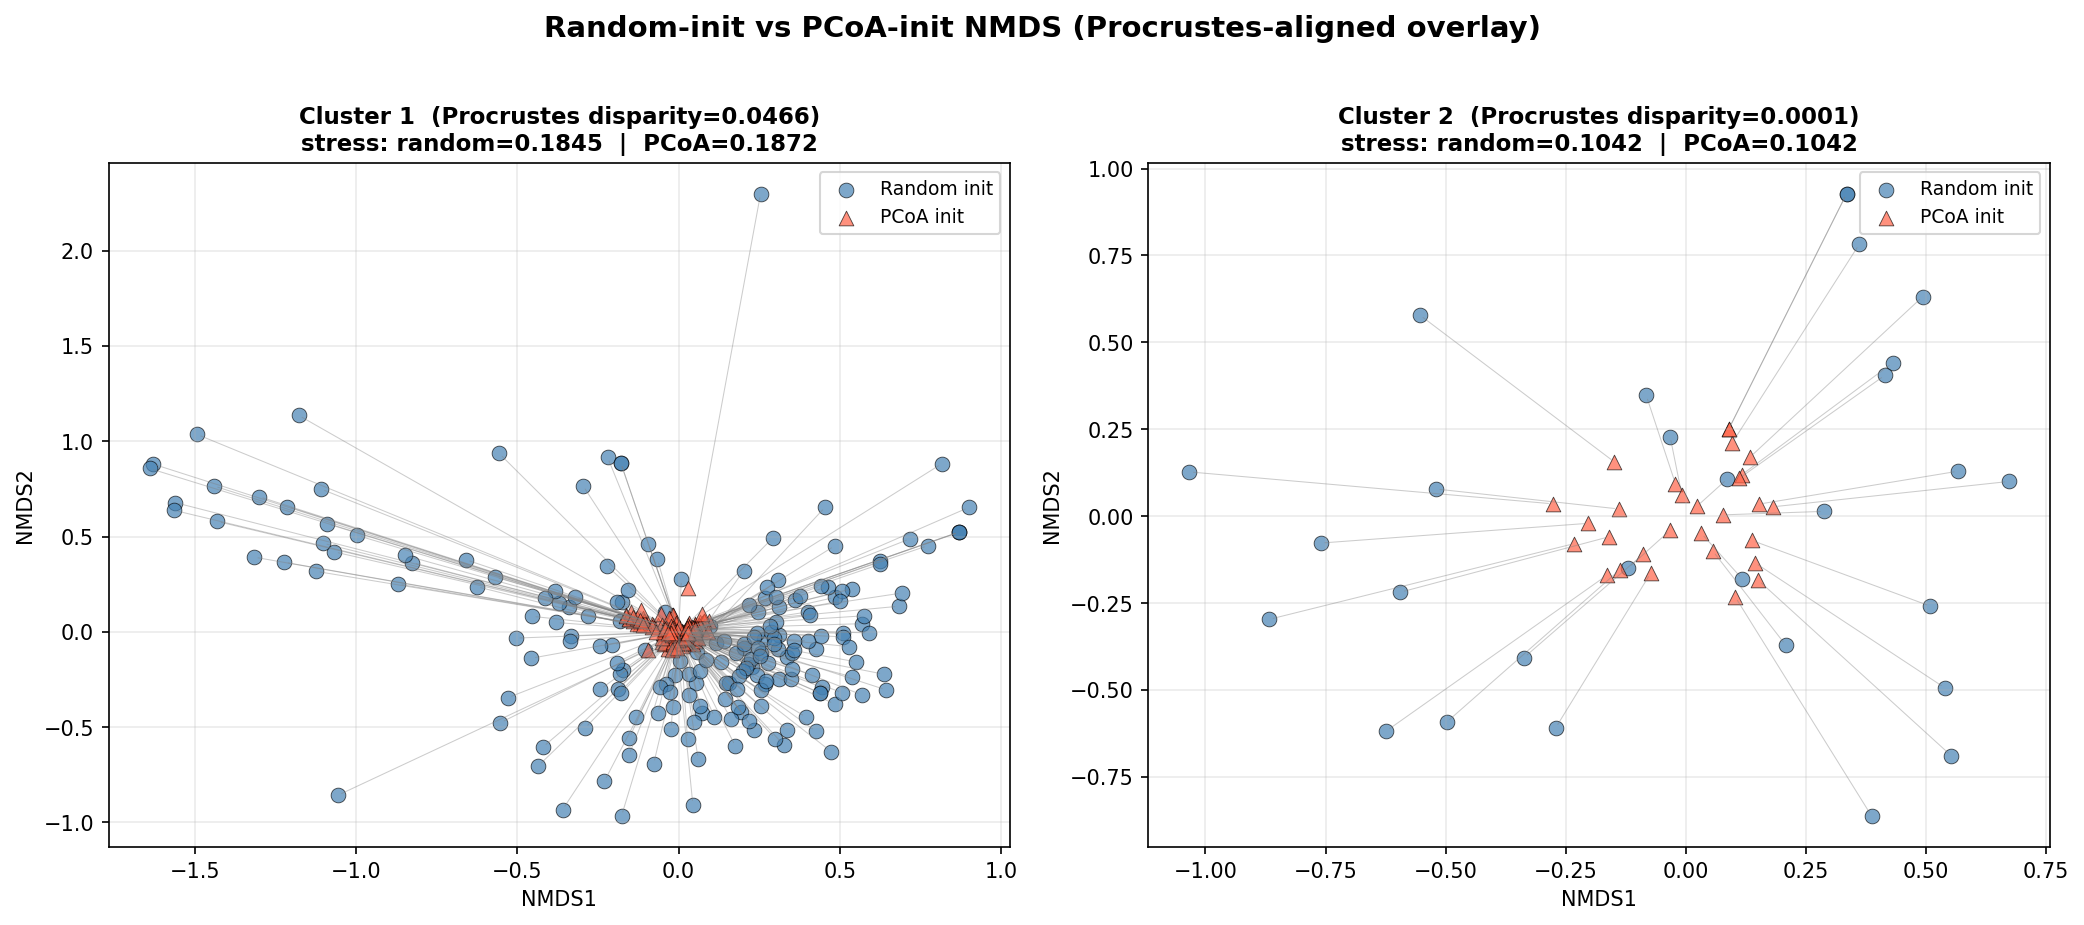

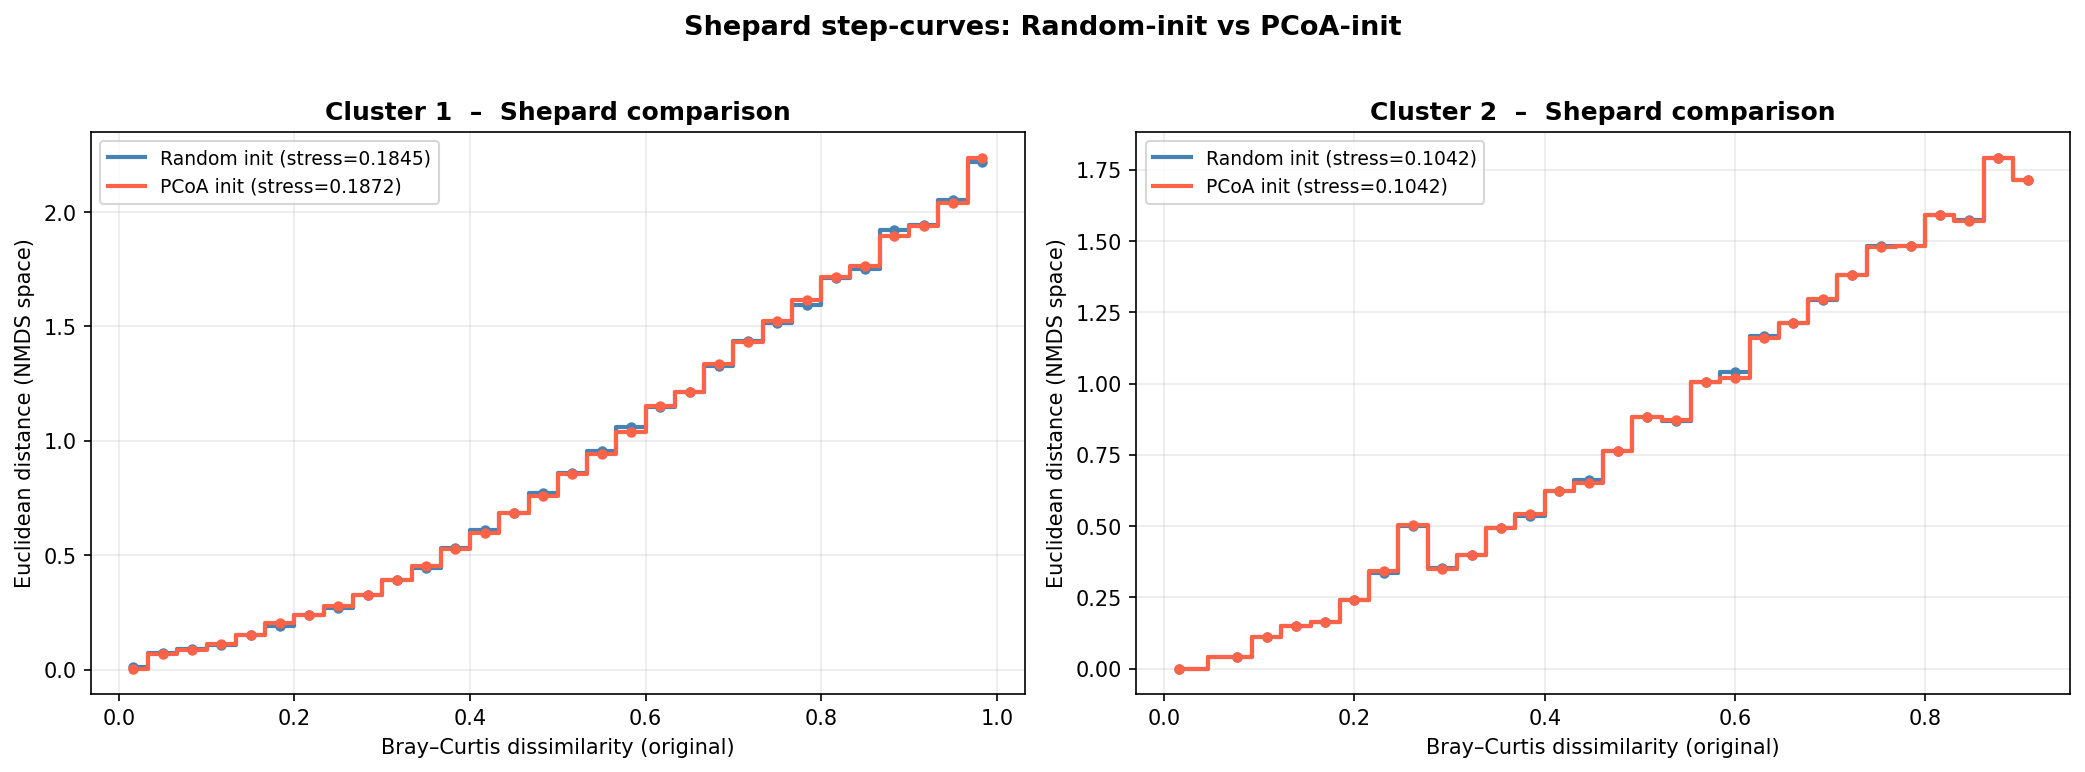

In [84]:
# ── Comparison: Random-init vs PCoA-init ──────────────────────────────────────
from scipy.spatial import procrustes

# ── 1. Stress comparison table ────────────────────────────────────────────────
print("=" * 72)
print(f"{'Cluster':>8}  {'n_sites':>8}  {'Stress (random)':>16}  {'Stress (PCoA)':>16}  {'Δ stress':>10}")
print("-" * 72)
for cl in clusters:
    s_rand = nmds_results[cl][1]
    s_pcoa = nmds_results_pcoa[cl][1]
    delta  = s_pcoa - s_rand
    tag    = "← improved" if delta < -1e-6 else ("≈ same" if abs(delta) < 1e-6 else "← worse")
    print(f"{cl:>8}  {len(nmds_results[cl][0]):>8}  {s_rand:>16.6f}  {s_pcoa:>16.6f}  {delta:>+10.6f}  {tag}")
print("=" * 72)

# ── 2. Side-by-side ordination overlay (Procrustes-aligned) ──────────────────
fig, axes = plt.subplots(1, n_clusters, figsize=(7 * n_clusters, 6), dpi=150)
if n_clusters == 1:
    axes = [axes]

for ax, cl in zip(axes, clusters):
    coords_rand = nmds_results[cl][0].values
    coords_pcoa = nmds_results_pcoa[cl][0].values

    # Procrustes rotation so the two solutions share orientation
    _, aligned_pcoa, disparity = procrustes(coords_rand, coords_pcoa)

    # Plot random-init points
    ax.scatter(coords_rand[:, 0], coords_rand[:, 1],
               s=50, c="steelblue", marker="o", alpha=0.7,
               edgecolors="k", linewidths=0.4, label="Random init")

    # Plot PCoA-init points (Procrustes-aligned)
    ax.scatter(aligned_pcoa[:, 0], aligned_pcoa[:, 1],
               s=50, c="tomato", marker="^", alpha=0.7,
               edgecolors="k", linewidths=0.4, label="PCoA init")

    # Arrows connecting corresponding sites
    for r, p in zip(coords_rand, aligned_pcoa):
        ax.annotate("", xy=p, xytext=r,
                     arrowprops=dict(arrowstyle="-", color="gray",
                                     lw=0.5, alpha=0.4))

    s_rand = nmds_results[cl][1]
    s_pcoa = nmds_results_pcoa[cl][1]
    ax.set_title(
        f"Cluster {cl}  (Procrustes disparity={disparity:.4f})\n"
        f"stress: random={s_rand:.4f}  |  PCoA={s_pcoa:.4f}",
        fontsize=11, fontweight="bold",
    )
    ax.set_xlabel("NMDS1")
    ax.set_ylabel("NMDS2")
    ax.grid(alpha=0.25)
    ax.legend(fontsize=9, loc="best")

fig.suptitle("Random-init vs PCoA-init NMDS (Procrustes-aligned overlay)",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

# ── 3. Shepard step-curves side-by-side ──────────────────────────────────────
fig, axes = plt.subplots(1, n_clusters, figsize=(7 * n_clusters, 5), dpi=150)
if n_clusters == 1:
    axes = [axes]

for ax, cl in zip(axes, clusters):
    for label, res, colour in [
        ("Random init", nmds_results[cl], "steelblue"),
        ("PCoA init",   nmds_results_pcoa[cl], "tomato"),
    ]:
        coords_r, stress_r, dist_mat_r = res
        orig_r = dist_mat_r.values[np.triu_indices(len(dist_mat_r), k=1)]
        ord_d  = _sqf(_pdist(coords_r.values, metric="euclidean"))
        ordi_r = ord_d[np.triu_indices(len(coords_r), k=1)]

        bin_edges = np.linspace(orig_r.min(), orig_r.max(), N_BINS + 1)
        bin_idx   = np.clip(np.digitize(orig_r, bin_edges) - 1, 0, N_BINS - 1)
        bx, by = [], []
        for b in range(N_BINS):
            m = bin_idx == b
            if m.sum() > 0:
                bx.append((bin_edges[b] + bin_edges[b + 1]) / 2)
                by.append(np.median(ordi_r[m]))
        bx, by = np.array(bx), np.array(by)

        ax.step(bx, by, where="mid", color=colour, lw=2.0,
                label=f"{label} (stress={stress_r:.4f})")
        ax.plot(bx, by, "o", color=colour, ms=4, zorder=3)

    ax.set_xlabel("Bray–Curtis dissimilarity (original)")
    ax.set_ylabel("Euclidean distance (NMDS space)")
    ax.set_title(f"Cluster {cl}  –  Shepard comparison", fontweight="bold")
    ax.grid(alpha=0.25)
    ax.legend(fontsize=9)

fig.suptitle("Shepard step-curves: Random-init vs PCoA-init",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## 7 · Method 1 — Iterative NMDS Refinement (chain restarts)

**Idea.**  Take the *best* random-init NMDS solution from §4 and feed it back as the starting configuration for a *new* NMDS run.  Repeat this "warm-restart" 2–3 times.

*Why it can help:*  
The first NMDS run with `n_init=10` random starts already picks the lowest-stress solution, but that solution is only guaranteed to be a **local** minimum.  By re-starting from it with fresh optimisation (possibly with more iterations or a tighter tolerance), the solver may refine the configuration further — analogous to **simulated annealing** or **iterative polishing** in numerical optimisation.

Each successive pass starts from a configuration that is already "close" to a good solution, so it tends to converge quickly and may shave off residual stress.

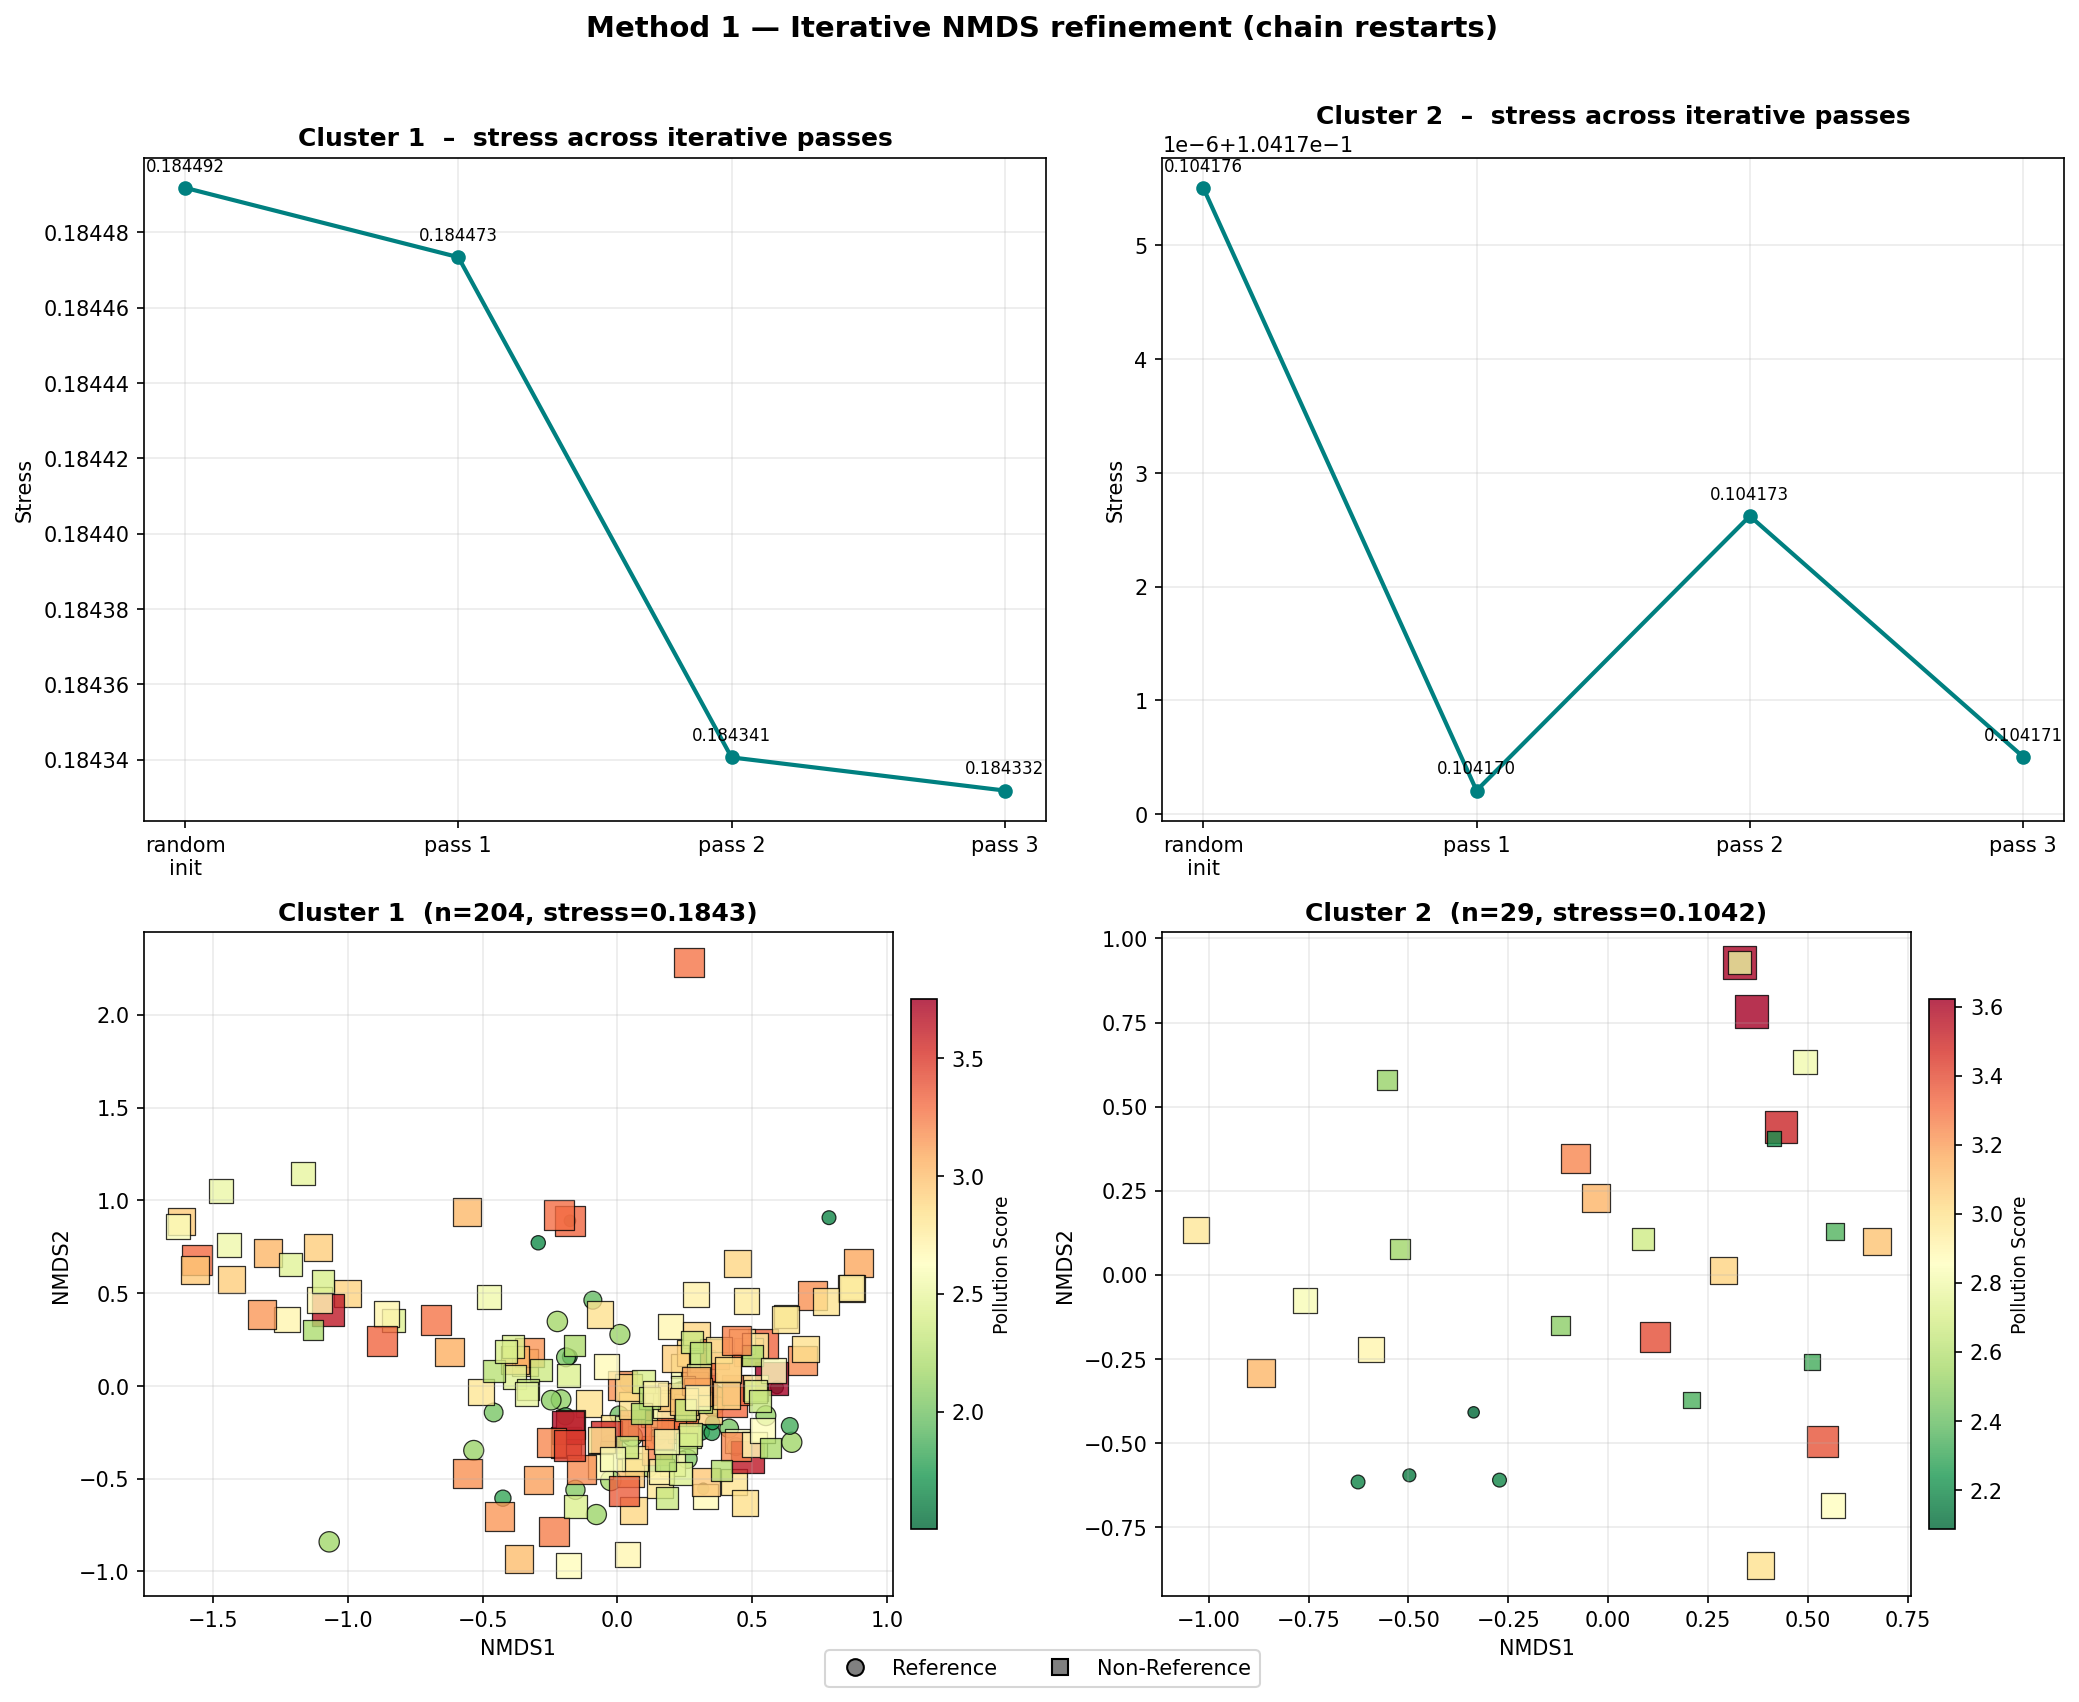


 Cluster    Pass        Stress     Δ from prev
------------------------------------------------------------------------
       1  random      0.184492      +0.0000000  
       1  pass 1      0.184473      -0.0000184  ↓ improved
       1  pass 2      0.184341      -0.0001328  ↓ improved
       1  pass 3      0.184332      -0.0000088  ↓ improved
------------------------------------------------------------------------
       2  random      0.104176      +0.0000000  
       2  pass 1      0.104170      -0.0000053  ↓ improved
       2  pass 2      0.104173      +0.0000024  ↑ worse
       2  pass 3      0.104171      -0.0000021  ↓ improved
------------------------------------------------------------------------


In [85]:
# ── Method 1: Iterative NMDS refinement (chain restarts) ──────────────────────
N_PASSES = 3          # number of warm-restart passes after the initial run
MAX_ITER_PASS = 500   # iterations per pass (generous, since we start near a minimum)

nmds_results_iter = {}   # cluster -> list of (coords, stress, dist_mat) per pass

fig_ord, axes_ord = plt.subplots(2, n_clusters,
                                  figsize=(7 * n_clusters, 11), dpi=150)
if n_clusters == 1:
    axes_ord = axes_ord.reshape(2, 1)

for col_i, cl in enumerate(clusters):
    cl_sites = site_meta.index[site_meta["Cluster"] == cl]
    taxa_cl  = taxa.loc[cl_sites]
    meta_cl  = site_meta.loc[cl_sites]

    # Start from the random-init result (pass 0)
    prev_coords, prev_stress, prev_dist = nmds_results[cl]
    chain = [(prev_coords.copy(), prev_stress, prev_dist)]

    for p in range(1, N_PASSES + 1):
        coords_p, stress_p, dist_p = run_nmds_braycurtis(
            taxa_cl,
            n_components=2,
            max_iter=MAX_ITER_PASS,
            init=prev_coords.values,    # warm-start from previous solution
            random_state=42,
        )
        chain.append((coords_p, stress_p, dist_p))
        prev_coords = coords_p          # feed forward

    nmds_results_iter[cl] = chain       # length = N_PASSES + 1

    # ── top row: stress convergence curve ──────────────────────────────
    ax_top = axes_ord[0, col_i]
    stresses = [s for _, s, _ in chain]
    ax_top.plot(range(len(stresses)), stresses, "o-", color="teal", lw=2)
    for i, s in enumerate(stresses):
        ax_top.annotate(f"{s:.6f}", (i, s), textcoords="offset points",
                        xytext=(0, 8), ha="center", fontsize=8)
    ax_top.set_xticks(range(len(stresses)))
    ax_top.set_xticklabels(["random\ninit"] + [f"pass {i}" for i in range(1, N_PASSES + 1)])
    ax_top.set_ylabel("Stress")
    ax_top.set_title(f"Cluster {cl}  –  stress across iterative passes",
                     fontweight="bold")
    ax_top.grid(alpha=0.25)

    # ── bottom row: final ordination ──────────────────────────────────
    ax_bot = axes_ord[1, col_i]
    final_coords = chain[-1][0]
    final_stress = chain[-1][1]
    ref_mask = meta_cl["Is_Reference"] == 1
    ps = meta_cl["Pollution_Score"]
    ps_norm = (ps - ps.min()) / (ps.max() - ps.min() + 1e-9) * 220 + 30

    ax_bot.scatter(
        final_coords.loc[ref_mask, "NMDS1"], final_coords.loc[ref_mask, "NMDS2"],
        s=ps_norm[ref_mask], c=ps[ref_mask], cmap="RdYlGn_r",
        marker="o", edgecolors="k", linewidths=0.6, alpha=0.8,
        vmin=ps.min(), vmax=ps.max(),
    )
    sc = ax_bot.scatter(
        final_coords.loc[~ref_mask, "NMDS1"], final_coords.loc[~ref_mask, "NMDS2"],
        s=ps_norm[~ref_mask], c=ps[~ref_mask], cmap="RdYlGn_r",
        marker="s", edgecolors="k", linewidths=0.6, alpha=0.8,
        vmin=ps.min(), vmax=ps.max(),
    )
    ax_bot.set_title(f"Cluster {cl}  (n={len(cl_sites)}, stress={final_stress:.4f})",
                     fontsize=12, fontweight="bold")
    ax_bot.set_xlabel("NMDS1"); ax_bot.set_ylabel("NMDS2")
    ax_bot.grid(alpha=0.25)
    cb = fig_ord.colorbar(sc, ax=ax_bot, shrink=0.8, pad=0.02)
    cb.set_label("Pollution Score", fontsize=9)

legend_handles = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor="gray",
           markeredgecolor="k", markersize=8, label="Reference"),
    Line2D([0], [0], marker="s", color="w", markerfacecolor="gray",
           markeredgecolor="k", markersize=8, label="Non-Reference"),
]
fig_ord.legend(handles=legend_handles, loc="lower center", ncol=2,
               fontsize=10, frameon=True, bbox_to_anchor=(0.5, -0.01))
fig_ord.suptitle("Method 1 — Iterative NMDS refinement (chain restarts)",
                 fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

# ── Summary ───────────────────────────────────────────────────────────────────
print("\n" + "=" * 72)
print(f"{'Cluster':>8}  {'Pass':>6}  {'Stress':>12}  {'Δ from prev':>14}")
print("-" * 72)
for cl in clusters:
    chain = nmds_results_iter[cl]
    for i, (_, s, _) in enumerate(chain):
        label = "random" if i == 0 else f"pass {i}"
        delta = s - chain[i - 1][1] if i > 0 else 0.0
        tag   = "" if i == 0 else ("↓ improved" if delta < -1e-7 else ("≈ same" if abs(delta) < 1e-7 else "↑ worse"))
        print(f"{cl:>8}  {label:>6}  {s:>12.6f}  {delta:>+14.7f}  {tag}")
    print("-" * 72)
print("=" * 72)

## 8 · Method 2 — Spatial-coordinate initialisation (geographic prior)

### How and why

In ecological ordination the **geographic coordinates** of sampling sites can serve as a meaningful starting configuration for NMDS because community composition is often **spatially autocorrelated** — nearby sites tend to share similar taxa assemblages (Tobler's First Law of Geography).  By placing samples at their real-world (lon, lat) positions in the initial 2-D configuration we give the iterative optimiser a head start: the starting arrangement already captures much of the **broad-scale spatial gradient** in community similarity, so the algorithm only needs to adjust for the finer, non-spatial components of dissimilarity.

> This idea is discussed in several community-ecology texts (e.g., Legendre & Legendre, *Numerical Ecology*, §9.3; Borcard *et al.*, *Numerical Ecology with R*).  The rationale is that if the dominant axis of community variation is geographic (e.g., an upstream → downstream pollution gradient), then geographic coordinates provide a better starting guess than random noise, reducing the risk of converging to a poor local minimum.

**Implementation steps**

1. Extract `Longitude` and `Latitude` for each site from the master data file (these are already in decimal degrees).
2. For each cluster subset, build a 2-column matrix `[Longitude, Latitude]`.
3. **Centre and scale** the coordinates to zero mean and unit variance — this ensures the spatial spread is comparable to a typical NMDS configuration and avoids numerical issues.
4. Pass the scaled coordinates as `init` to `run_nmds_braycurtis()` and let non-metric MDS refine from there.

Geographic coordinates shape: (233, 2)
var    Longitude  Latitude
count   233.0000  233.0000
mean    -82.8988   42.3521
std       0.2757    0.2321
min     -83.1928   42.0413
25%     -83.1259   42.1724
50%     -83.0515   42.3180
75%     -82.5946   42.5373
max     -82.4094   43.0058


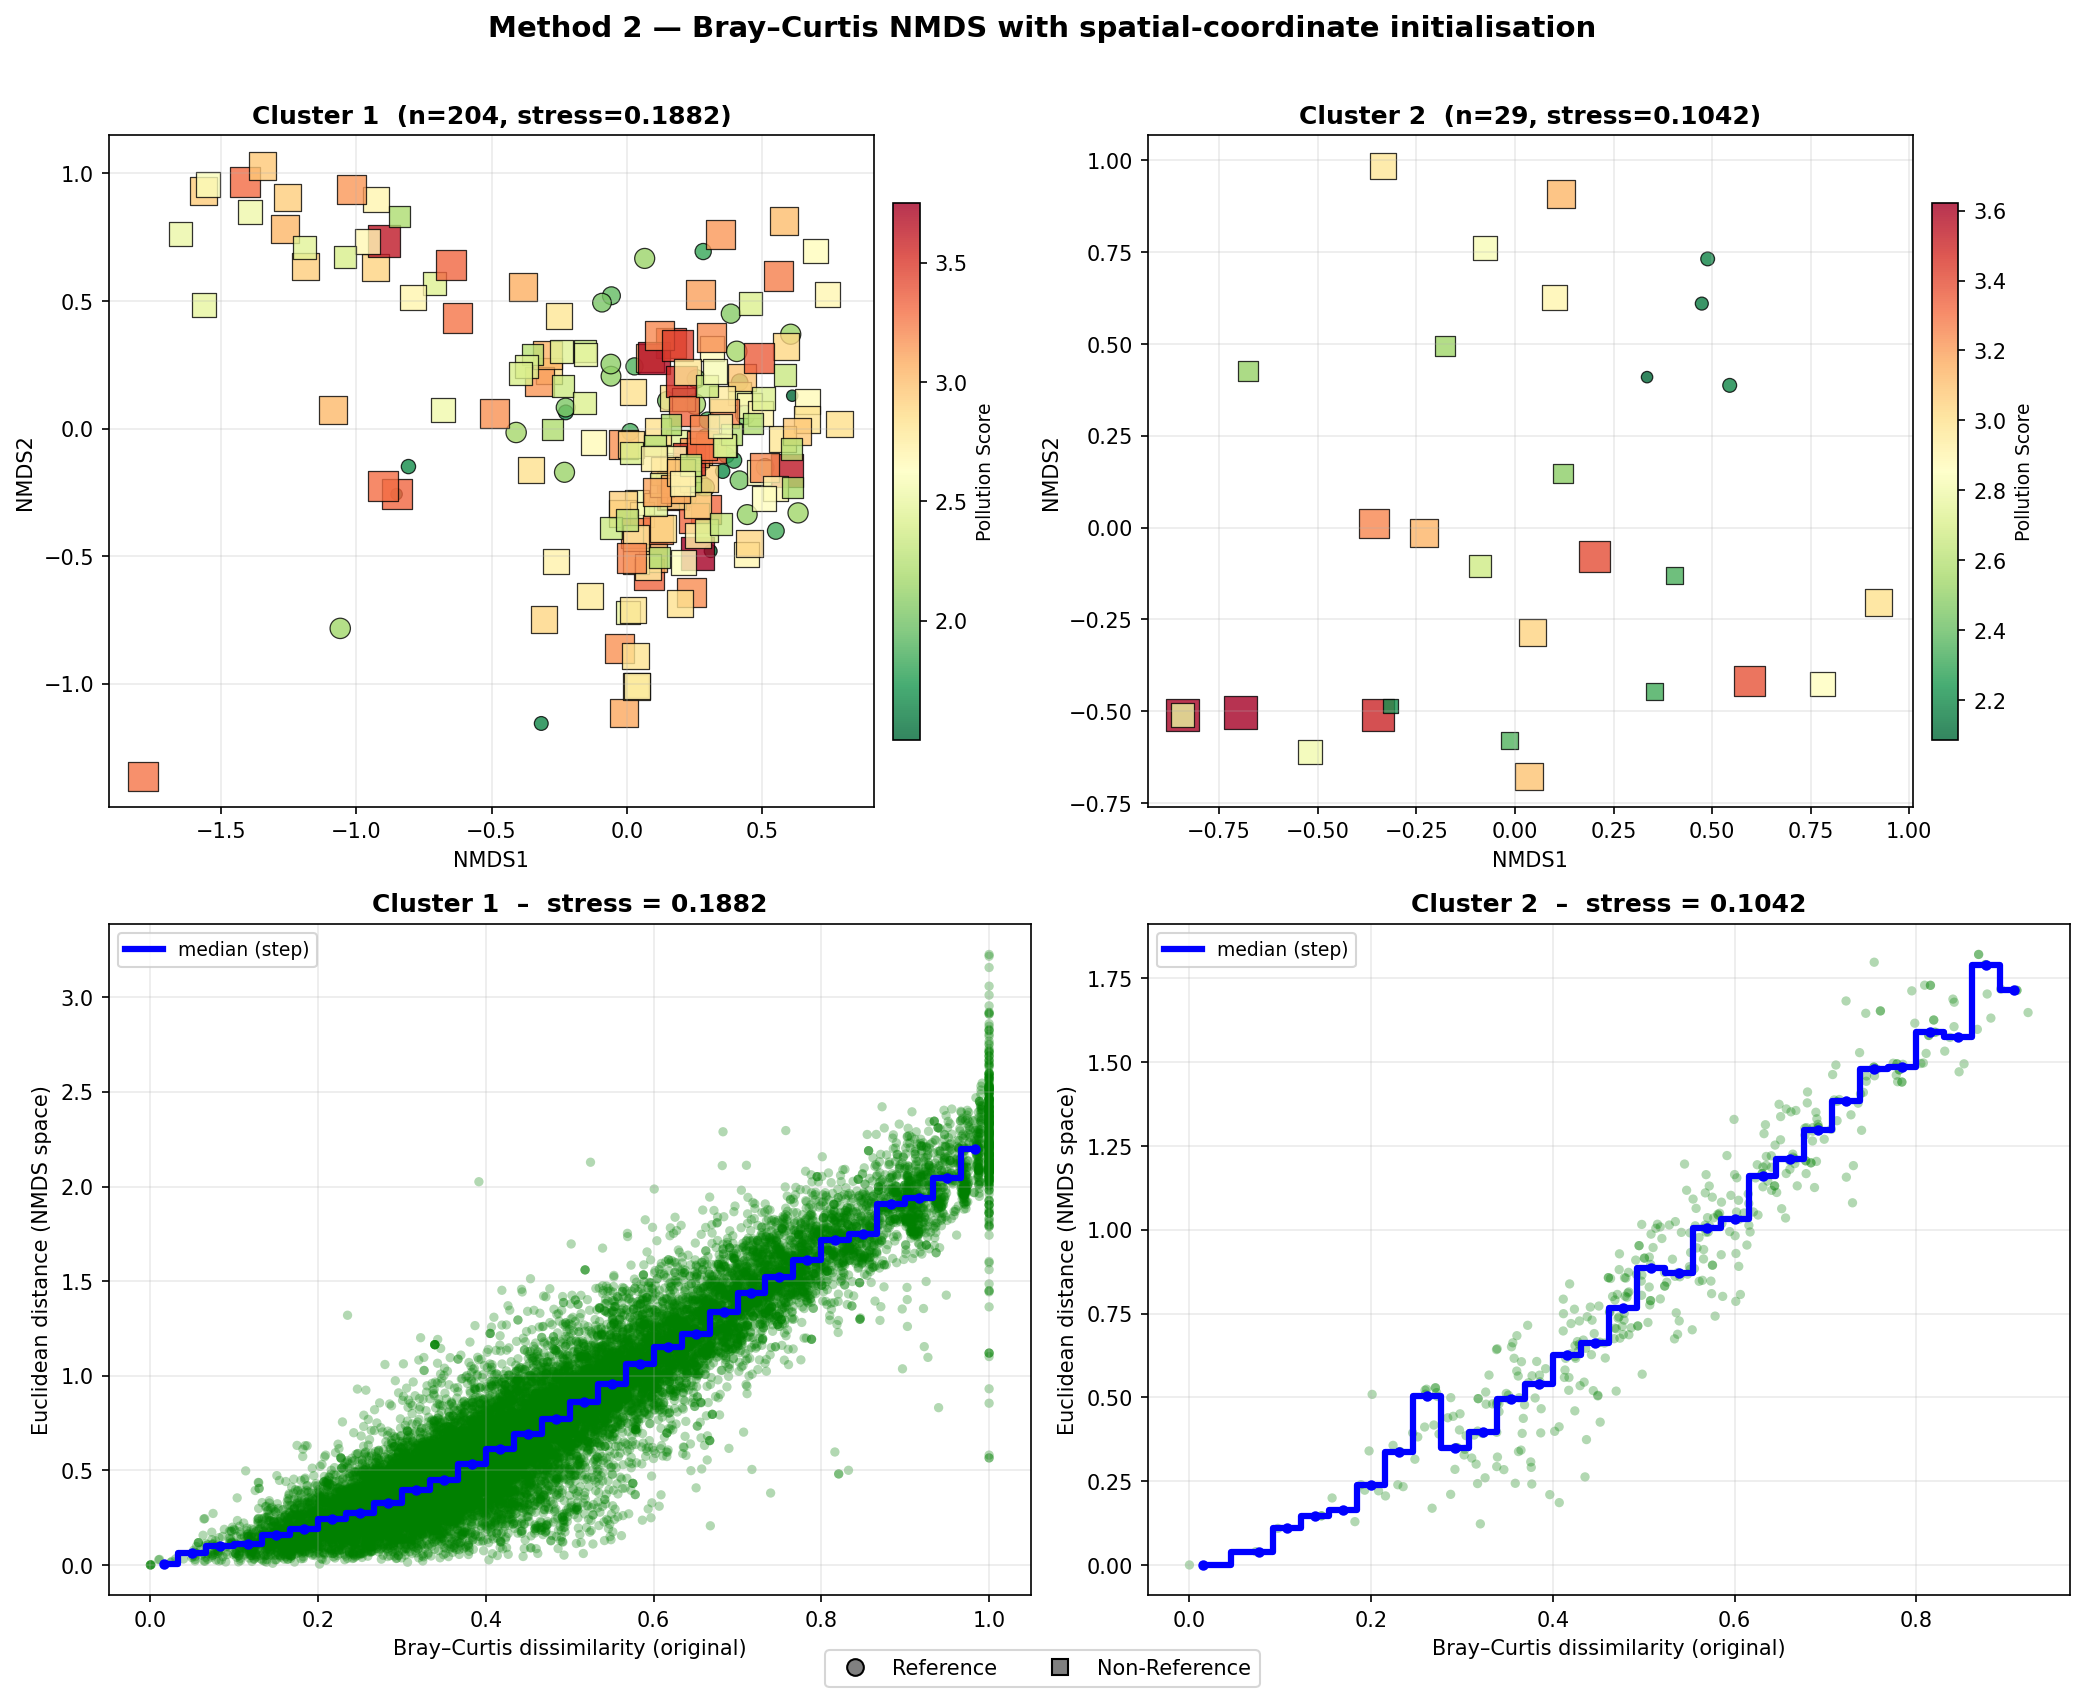


 Cluster   n_sites   Stress (spatial init)
------------------------------------------------------------
       1       204                0.188203
       2        29                0.104178


In [86]:
# ── Method 2: Spatial-coordinate initialisation ───────────────────────────────

# 1. Extract geographic coordinates from the master data
sample_info = extract_block(data, "sample_info", "raw")
geo_coords  = sample_info.loc[common_idx, ["Longitude", "Latitude"]].copy()
print("Geographic coordinates shape:", geo_coords.shape)
print(geo_coords.describe().round(4))

nmds_results_spatial = {}   # cluster -> (coords, stress, dist_mat)

fig, axes = plt.subplots(2, n_clusters, figsize=(7 * n_clusters, 11), dpi=150)
if n_clusters == 1:
    axes = axes.reshape(2, 1)

for col_i, cl in enumerate(clusters):
    cl_sites = site_meta.index[site_meta["Cluster"] == cl]
    taxa_cl  = taxa.loc[cl_sites]
    meta_cl  = site_meta.loc[cl_sites]

    # 2. Build spatial init matrix (Longitude → NMDS1, Latitude → NMDS2)
    spatial_raw = geo_coords.loc[cl_sites, ["Longitude", "Latitude"]].values

    # 3. Centre and scale to z-scores so the spread matches a typical NMDS config
    spatial_init = (spatial_raw - spatial_raw.mean(axis=0)) / (spatial_raw.std(axis=0) + 1e-12)

    # 4. NMDS with spatial init
    coords, stress, dist_mat = run_nmds_braycurtis(
        taxa_cl,
        n_components=2,
        max_iter=500,
        init=spatial_init,
        random_state=42,
    )
    nmds_results_spatial[cl] = (coords, stress, dist_mat)

    # ==================== top row: ordination ====================
    ax = axes[0, col_i]
    ref_mask = meta_cl["Is_Reference"] == 1
    ps = meta_cl["Pollution_Score"]
    ps_norm = (ps - ps.min()) / (ps.max() - ps.min() + 1e-9) * 220 + 30

    ax.scatter(
        coords.loc[ref_mask, "NMDS1"], coords.loc[ref_mask, "NMDS2"],
        s=ps_norm[ref_mask], c=ps[ref_mask], cmap="RdYlGn_r",
        marker="o", edgecolors="k", linewidths=0.6, alpha=0.8,
        vmin=ps.min(), vmax=ps.max(),
    )
    sc = ax.scatter(
        coords.loc[~ref_mask, "NMDS1"], coords.loc[~ref_mask, "NMDS2"],
        s=ps_norm[~ref_mask], c=ps[~ref_mask], cmap="RdYlGn_r",
        marker="s", edgecolors="k", linewidths=0.6, alpha=0.8,
        vmin=ps.min(), vmax=ps.max(),
    )
    ax.set_title(f"Cluster {cl}  (n={len(cl_sites)}, stress={stress:.4f})",
                 fontsize=12, fontweight="bold")
    ax.set_xlabel("NMDS1"); ax.set_ylabel("NMDS2")
    ax.grid(alpha=0.25)
    cb = fig.colorbar(sc, ax=ax, shrink=0.8, pad=0.02)
    cb.set_label("Pollution Score", fontsize=9)

    # ==================== bottom row: Shepard plot ====================
    ax2 = axes[1, col_i]
    orig = dist_mat.values[np.triu_indices(len(dist_mat), k=1)]
    ord_dists = _sqf(_pdist(coords.values, metric="euclidean"))
    ordi = ord_dists[np.triu_indices(len(coords), k=1)]

    ax2.scatter(orig, ordi, alpha=0.3, s=20, color="green", edgecolors="none")

    bin_edges = np.linspace(orig.min(), orig.max(), N_BINS + 1)
    bin_idx   = np.clip(np.digitize(orig, bin_edges) - 1, 0, N_BINS - 1)
    bx, by = [], []
    for b in range(N_BINS):
        m = bin_idx == b
        if m.sum() > 0:
            bx.append((bin_edges[b] + bin_edges[b + 1]) / 2)
            by.append(np.median(ordi[m]))
    bx, by = np.array(bx), np.array(by)

    ax2.step(bx, by, where="mid", color="blue", lw=3.0, label="median (step)")
    ax2.plot(bx, by, "o", color="blue", ms=4, zorder=3)
    ax2.set_xlabel("Bray–Curtis dissimilarity (original)")
    ax2.set_ylabel("Euclidean distance (NMDS space)")
    ax2.set_title(f"Cluster {cl}  –  stress = {stress:.4f}", fontweight="bold")
    ax2.grid(alpha=0.25)
    ax2.legend(fontsize=9)

legend_handles = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor="gray",
           markeredgecolor="k", markersize=8, label="Reference"),
    Line2D([0], [0], marker="s", color="w", markerfacecolor="gray",
           markeredgecolor="k", markersize=8, label="Non-Reference"),
]
fig.legend(handles=legend_handles, loc="lower center", ncol=2,
           fontsize=10, frameon=True, bbox_to_anchor=(0.5, -0.01))
fig.suptitle("Method 2 — Bray–Curtis NMDS with spatial-coordinate initialisation",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

# ── Summary ───────────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print(f"{'Cluster':>8}  {'n_sites':>8}  {'Stress (spatial init)':>22}")
print("-" * 60)
for cl in clusters:
    c, s, _ = nmds_results_spatial[cl]
    print(f"{cl:>8}  {len(c):>8}  {s:>22.6f}")
print("=" * 60)

## 9 · Grand comparison — all initialisation strategies

| Strategy | Description |
|----------|-------------|
| **Random** | 10 random starts, keep lowest stress (§4) |
| **PCoA** | metric MDS → warm-start non-metric MDS (§6a) |
| **Iterative** | chain 3 warm-restarts from random solution (§7) |
| **Spatial** | centred/scaled (lon, lat) as starting config (§8) |

Below we compare:
1. A **stress bar chart** across strategies for each cluster.
2. **Procrustes-aligned overlays** of the best-stress solution versus the random baseline.
3. **Shepard step-curves** for all four strategies on the same axes.

 Cluster        Random          PCoA     Iterative       Spatial
----------------------------------------------------------------
       1      0.184492      0.187194      0.184332      0.188203   ← best: Iterative
       2      0.104176      0.104192      0.104171      0.104178   ← best: Iterative


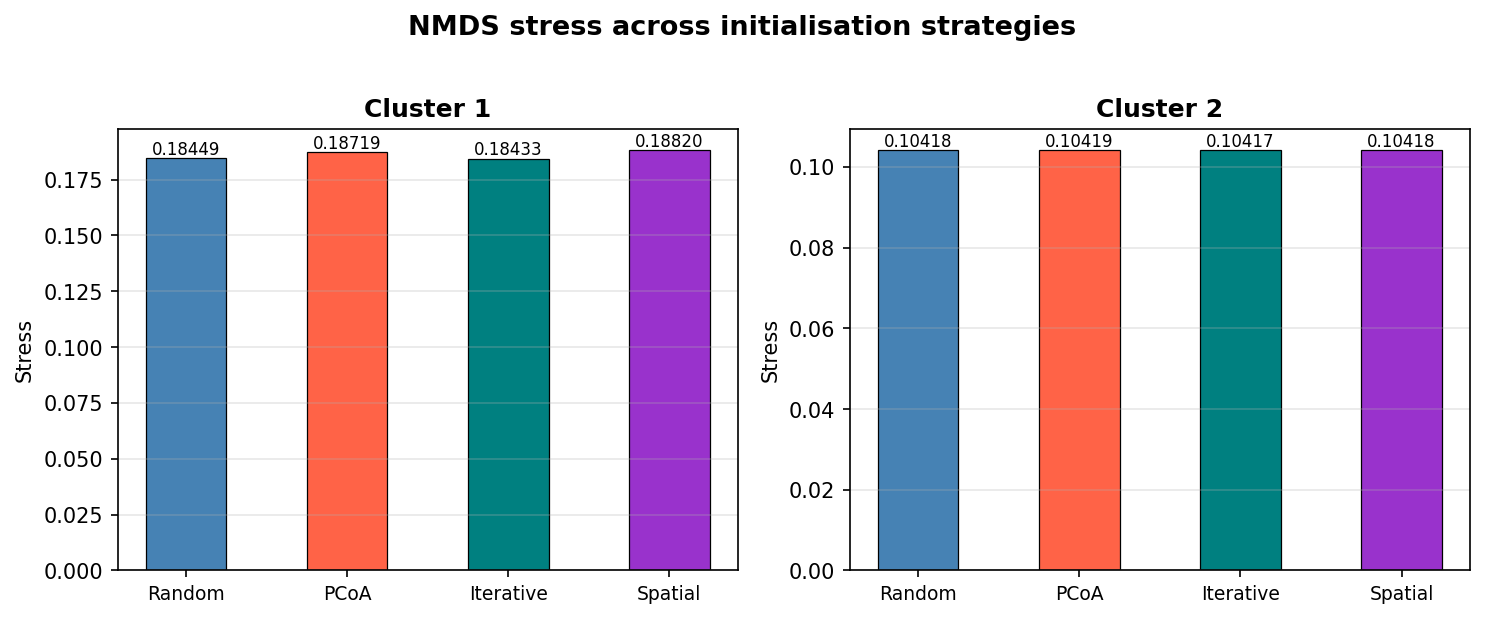

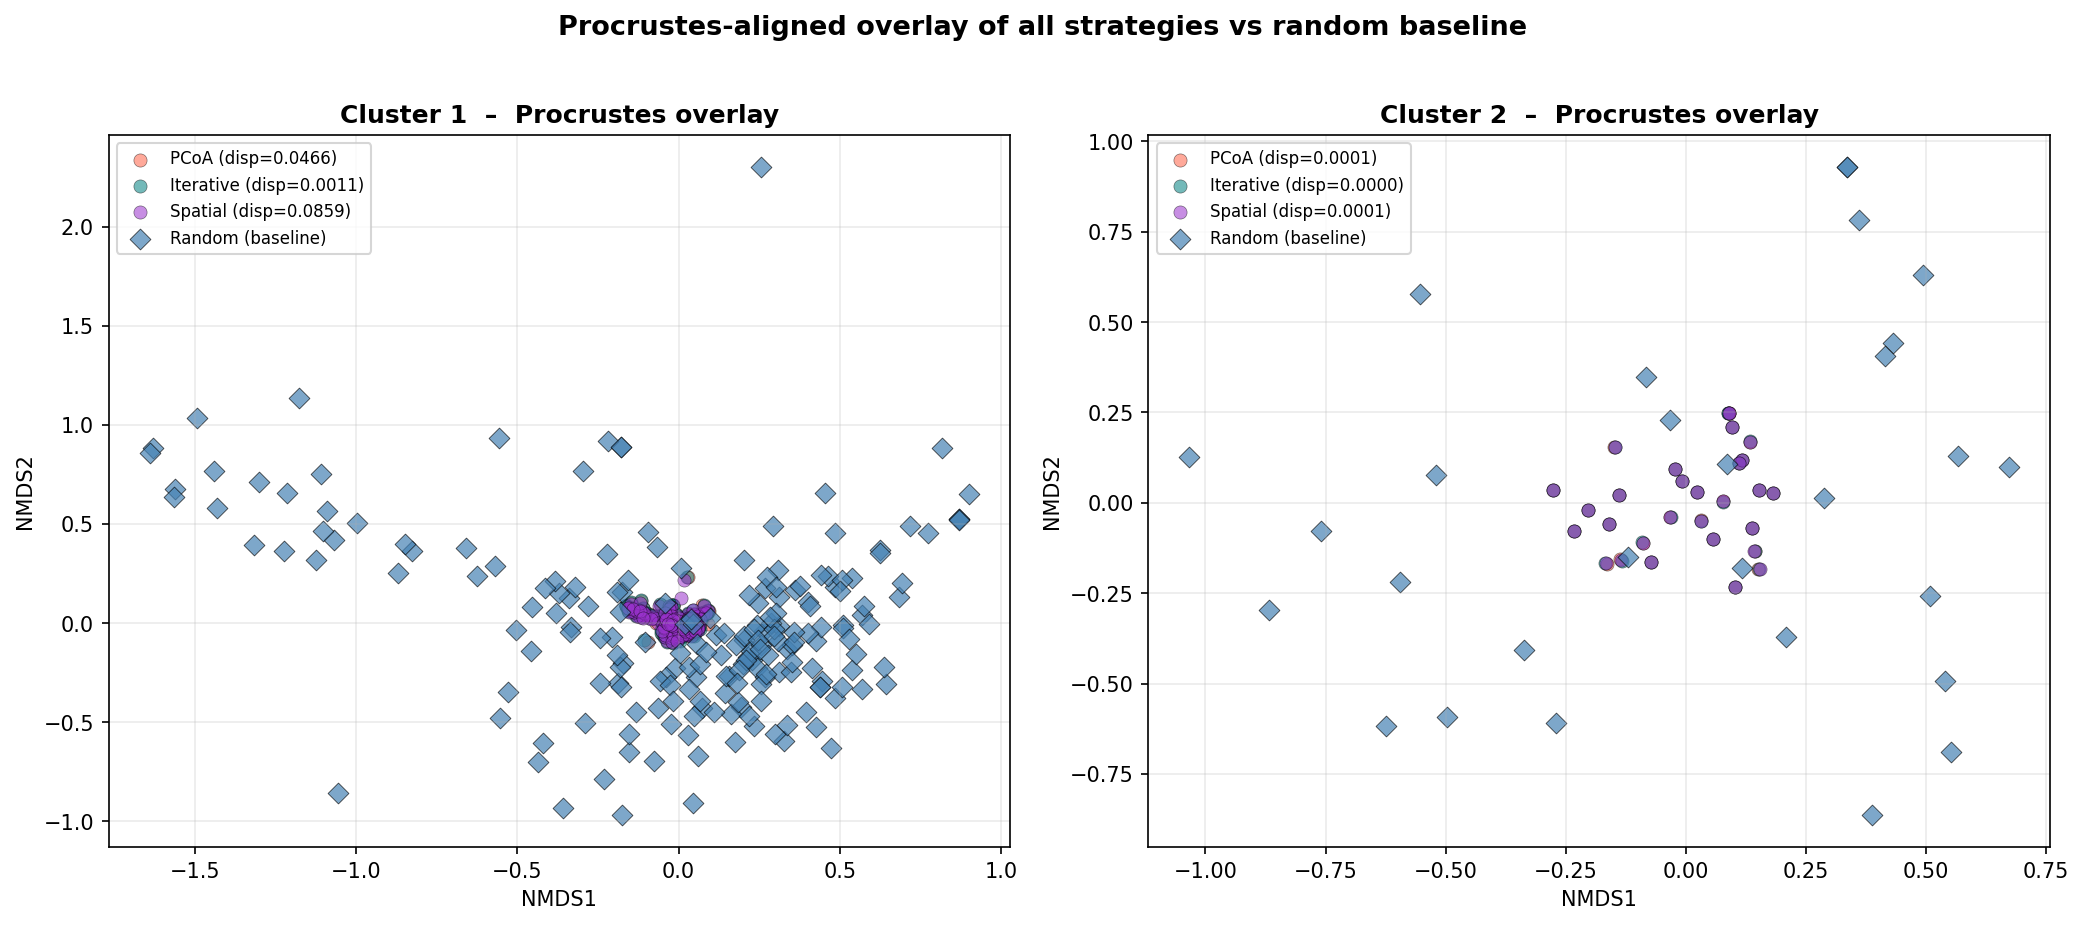

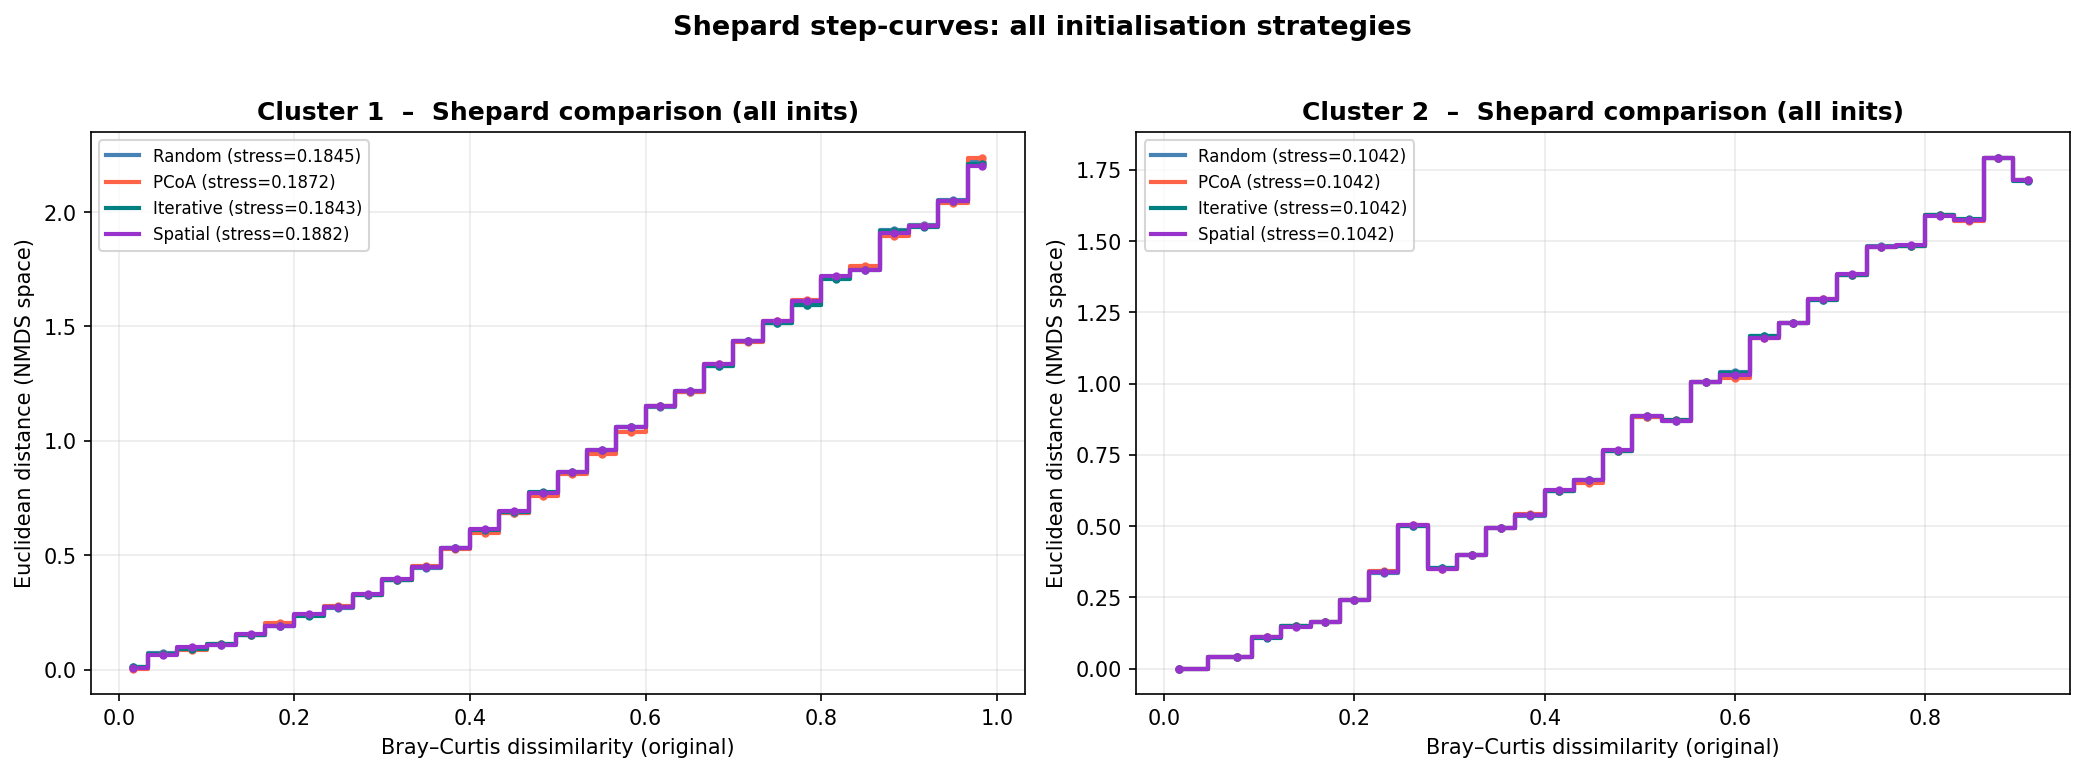

In [87]:
# ── Grand comparison: all four initialisation strategies ───────────────────────
from scipy.spatial import procrustes as _procrustes

# Collect (label, result_dict, colour) tuples for each strategy
strategies = [
    ("Random",    nmds_results,                          "steelblue"),
    ("PCoA",      nmds_results_pcoa,                     "tomato"),
    ("Iterative", {cl: nmds_results_iter[cl][-1] for cl in clusters}, "teal"),
    ("Spatial",   nmds_results_spatial,                  "darkorchid"),
]

# ── 1. Stress comparison table ────────────────────────────────────────────────
header = f"{'Cluster':>8}" + "".join(f"  {lab:>12}" for lab, *_ in strategies)
print("=" * len(header))
print(header)
print("-" * len(header))
for cl in clusters:
    row = f"{cl:>8}"
    stresses_cl = []
    for lab, res_dict, _ in strategies:
        s = res_dict[cl][1]
        stresses_cl.append(s)
        row += f"  {s:>12.6f}"
    best = min(stresses_cl)
    best_lab = strategies[stresses_cl.index(best)][0]
    row += f"   ← best: {best_lab}"
    print(row)
print("=" * len(header))

# ── 2. Stress bar chart ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, n_clusters, figsize=(5 * n_clusters, 4), dpi=150)
if n_clusters == 1:
    axes = [axes]

bar_width = 0.18
x_base = np.arange(len(strategies))

for ax, cl in zip(axes, clusters):
    stresses = [res[cl][1] for _, res, _ in strategies]
    colours  = [c for _, _, c in strategies]
    labels   = [l for l, _, _ in strategies]

    bars = ax.bar(x_base, stresses, width=0.5, color=colours, edgecolor="k", lw=0.6)
    for bar, s in zip(bars, stresses):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                f"{s:.5f}", ha="center", va="bottom", fontsize=8)

    ax.set_xticks(x_base)
    ax.set_xticklabels(labels, fontsize=9)
    ax.set_ylabel("Stress")
    ax.set_title(f"Cluster {cl}", fontweight="bold")
    ax.grid(axis="y", alpha=0.3)

fig.suptitle("NMDS stress across initialisation strategies",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

# ── 3. Procrustes overlay — best non-random vs random baseline ───────────────
fig, axes = plt.subplots(1, n_clusters, figsize=(7 * n_clusters, 6), dpi=150)
if n_clusters == 1:
    axes = [axes]

for ax, cl in zip(axes, clusters):
    base_coords = nmds_results[cl][0].values          # random init baseline

    for lab, res_dict, col in strategies[1:]:          # skip random (it's the base)
        alt_coords = res_dict[cl][0].values
        _, aligned, disp = _procrustes(base_coords, alt_coords)
        ax.scatter(aligned[:, 0], aligned[:, 1],
                   s=40, c=col, marker="o", alpha=0.55, edgecolors="k",
                   linewidths=0.3, label=f"{lab} (disp={disp:.4f})")

    # random baseline on top
    ax.scatter(base_coords[:, 0], base_coords[:, 1],
               s=50, c="steelblue", marker="D", alpha=0.7, edgecolors="k",
               linewidths=0.4, label="Random (baseline)")

    ax.set_title(f"Cluster {cl}  –  Procrustes overlay", fontweight="bold")
    ax.set_xlabel("NMDS1"); ax.set_ylabel("NMDS2")
    ax.grid(alpha=0.25)
    ax.legend(fontsize=8, loc="best")

fig.suptitle("Procrustes-aligned overlay of all strategies vs random baseline",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

# ── 4. Shepard step-curves — all strategies on same axes ─────────────────────
fig, axes = plt.subplots(1, n_clusters, figsize=(7 * n_clusters, 5), dpi=150)
if n_clusters == 1:
    axes = [axes]

for ax, cl in zip(axes, clusters):
    for lab, res_dict, col in strategies:
        coords_s, stress_s, dist_mat_s = res_dict[cl]
        orig_s  = dist_mat_s.values[np.triu_indices(len(dist_mat_s), k=1)]
        ord_d_s = _sqf(_pdist(coords_s.values, metric="euclidean"))
        ordi_s  = ord_d_s[np.triu_indices(len(coords_s), k=1)]

        bin_edges = np.linspace(orig_s.min(), orig_s.max(), N_BINS + 1)
        bin_idx   = np.clip(np.digitize(orig_s, bin_edges) - 1, 0, N_BINS - 1)
        bx, by = [], []
        for b in range(N_BINS):
            m = bin_idx == b
            if m.sum() > 0:
                bx.append((bin_edges[b] + bin_edges[b + 1]) / 2)
                by.append(np.median(ordi_s[m]))
        bx, by = np.array(bx), np.array(by)

        ax.step(bx, by, where="mid", color=col, lw=2.0,
                label=f"{lab} (stress={stress_s:.4f})")
        ax.plot(bx, by, "o", color=col, ms=3, zorder=3)

    ax.set_xlabel("Bray–Curtis dissimilarity (original)")
    ax.set_ylabel("Euclidean distance (NMDS space)")
    ax.set_title(f"Cluster {cl}  –  Shepard comparison (all inits)", fontweight="bold")
    ax.grid(alpha=0.25)
    ax.legend(fontsize=8)

fig.suptitle("Shepard step-curves: all initialisation strategies",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## 10 · Stress vs. number of dimensions (scree plot)

NMDS stress decreases as we allow more ordination axes.  By running NMDS for $k = 1, 2, \ldots, 16$ (the number of original taxa variables) we can plot a **scree curve** and look for an **elbow** — the dimensionality beyond which adding more axes gives diminishing stress reduction.  A common rule of thumb (Clarke, 1993) is stress < 0.20 for a usable representation; stress < 0.10 is considered good.

In [88]:
# # ── Stress vs. number of dimensions (k = 1 … 16) per cluster ─────────────────
# MAX_K = len(TAXA_COLUMNS)  # 16

# stress_by_k = {cl: [] for cl in clusters}   # cluster -> list of (k, stress)

# for cl in clusters:
#     cl_sites = site_meta.index[site_meta["Cluster"] == cl]
#     taxa_cl  = taxa.loc[cl_sites]
#     bc_sq    = squareform(pdist(taxa_cl.values, metric="braycurtis"))

#     for k in range(1, MAX_K + 1):
#         nmds_k = MDS(
#             n_components=k,
#             metric_mds=False,
#             metric="precomputed",
#             max_iter=500,
#             n_init=4,
#             init="random",
#             random_state=42,
#             normalized_stress="auto",
#         )
#         nmds_k.fit(bc_sq)
#         stress_by_k[cl].append((k, nmds_k.stress_))
#     print(f"Cluster {cl}: done  (k=1..{MAX_K})")

# # ── Plot scree curves ────────────────────────────────────────────────────────
# fig, axes = plt.subplots(1, n_clusters, figsize=(6 * n_clusters, 5), dpi=150)
# if n_clusters == 1:
#     axes = [axes]

# for ax, cl in zip(axes, clusters):
#     ks      = [t[0] for t in stress_by_k[cl]]
#     stresses = [t[1] for t in stress_by_k[cl]]

#     ax.plot(ks, stresses, "o-", color="teal", lw=2, markersize=6)
#     for k_i, s_i in zip(ks, stresses):
#         ax.annotate(f"{s_i:.4f}", (k_i, s_i), textcoords="offset points",
#                     xytext=(6, 6), fontsize=7, color="gray")

#     # reference lines
#     ax.axhline(0.20, ls="--", color="salmon", lw=1, label="stress = 0.20 (fair)")
#     ax.axhline(0.10, ls="--", color="green",  lw=1, label="stress = 0.10 (good)")

#     ax.set_xlabel("Number of NMDS dimensions (k)")
#     ax.set_ylabel("Stress")
#     ax.set_xticks(ks)
#     ax.set_title(f"Cluster {cl}  (n = {len(site_meta[site_meta['Cluster']==cl])})",
#                  fontweight="bold")
#     ax.grid(alpha=0.25)
#     ax.legend(fontsize=8)

# fig.suptitle("Stress scree plot — NMDS dimensionality selection",
#              fontsize=14, fontweight="bold", y=1.02)
# plt.tight_layout()
# plt.show()

# # print table
# print("\n" + "=" * 50)
# for cl in clusters:
#     print(f"\nCluster {cl}")
#     print(f"  {'k':>3}  {'Stress':>10}")
#     print(f"  " + "-" * 16)
#     for k, s in stress_by_k[cl]:
#         print(f"  {k:>3}  {s:>10.6f}")
# print("=" * 50)

## 11 · Post-NMDS: rotate and rescale the 2-D ordination

NMDS axes are **arbitrary** — they carry no intrinsic meaning (unlike PCA axes).  Two common post-processing steps:

1. **PCA rotation** — rotate the configuration so that NMDS1 captures the largest spread (variance) and NMDS2 the second-largest.  This is purely cosmetic but makes plots more interpretable and comparable across runs.
2. **Half-change scaling** — rescale the axes so that one unit of ordination distance ≈ 50 % turnover in community composition.  This links ordination distance to an ecologically meaningful quantity.

Below we apply both to the **original random-init 2-D NMDS** from §4.

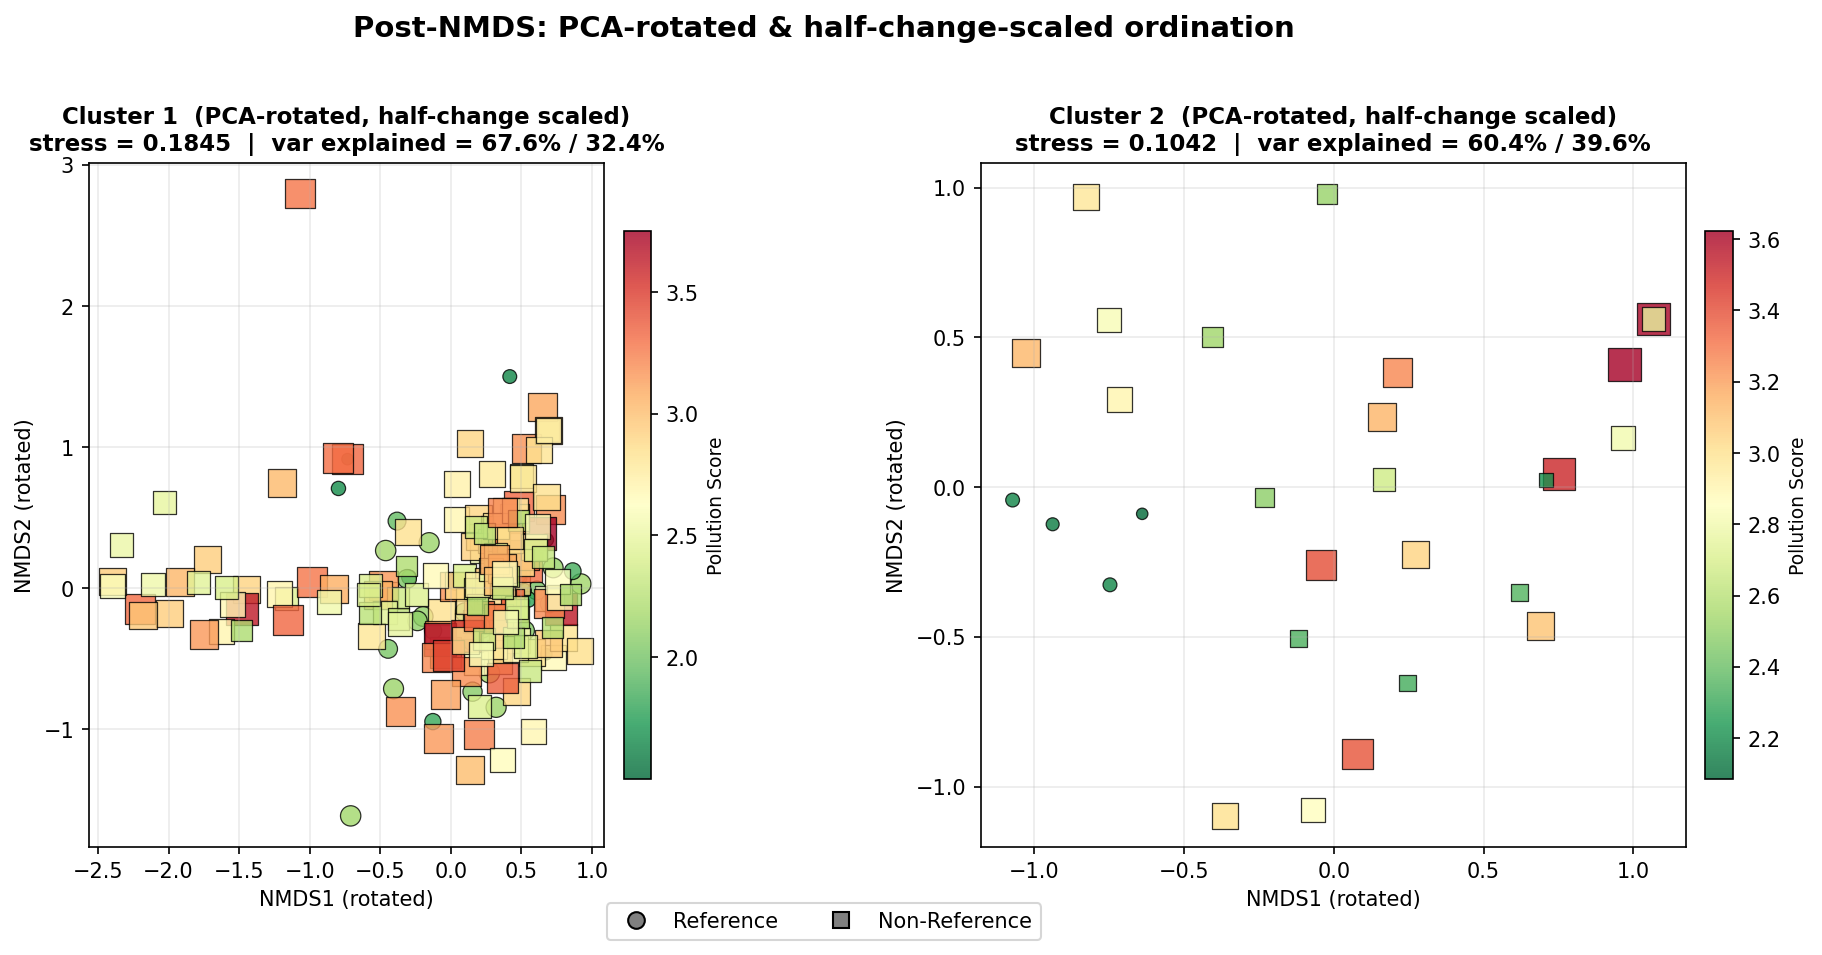

In [89]:
# ── Post-NMDS: PCA-rotate and half-change rescale ─────────────────────────────
from sklearn.decomposition import PCA

nmds_rotated = {}  # cluster -> DataFrame of rotated+rescaled coords

fig, axes = plt.subplots(1, n_clusters, figsize=(7 * n_clusters, 6), dpi=150)
if n_clusters == 1:
    axes = [axes]

for ax, cl in zip(axes, clusters):
    coords_raw, stress_cl, dist_mat_cl = nmds_results[cl]
    meta_cl = site_meta.loc[coords_raw.index]

    # ── 1. PCA rotation: align axes with principal directions of variance ─────
    pca = PCA(n_components=2)
    rotated = pca.fit_transform(coords_raw.values)

    # ── 2. Half-change scaling ────────────────────────────────────────────────
    #    Bray-Curtis = 0.5 means 50 % turnover ("half change").
    #    We find the mean ordination distance that corresponds to BC ≈ 0.5,
    #    then rescale so that distance = 1 unit in the plot.
    bc_vals = dist_mat_cl.values[np.triu_indices(len(dist_mat_cl), k=1)]
    ord_vals = squareform(pdist(rotated, metric="euclidean"))
    ord_vals = ord_vals[np.triu_indices(len(rotated), k=1)]

    # pairs near BC = 0.5
    mask_hc = (bc_vals > 0.40) & (bc_vals < 0.60)
    if mask_hc.sum() > 5:
        hc_distance = np.median(ord_vals[mask_hc])
    else:
        hc_distance = np.median(ord_vals)  # fallback
    scale_factor = 1.0 / hc_distance if hc_distance > 0 else 1.0
    rescaled = rotated * scale_factor

    coords_new = pd.DataFrame(rescaled, index=coords_raw.index,
                               columns=["NMDS1_rot", "NMDS2_rot"])
    nmds_rotated[cl] = coords_new

    # ── Plot ──────────────────────────────────────────────────────────────────
    ref_mask = meta_cl["Is_Reference"] == 1
    ps = meta_cl["Pollution_Score"]
    ps_norm = (ps - ps.min()) / (ps.max() - ps.min() + 1e-9) * 220 + 30

    ax.scatter(
        coords_new.loc[ref_mask, "NMDS1_rot"],
        coords_new.loc[ref_mask, "NMDS2_rot"],
        s=ps_norm[ref_mask], c=ps[ref_mask], cmap="RdYlGn_r",
        marker="o", edgecolors="k", linewidths=0.6, alpha=0.8,
        vmin=ps.min(), vmax=ps.max(),
    )
    sc = ax.scatter(
        coords_new.loc[~ref_mask, "NMDS1_rot"],
        coords_new.loc[~ref_mask, "NMDS2_rot"],
        s=ps_norm[~ref_mask], c=ps[~ref_mask], cmap="RdYlGn_r",
        marker="s", edgecolors="k", linewidths=0.6, alpha=0.8,
        vmin=ps.min(), vmax=ps.max(),
    )
    ax.set_title(
        f"Cluster {cl}  (PCA-rotated, half-change scaled)\n"
        f"stress = {stress_cl:.4f}  |  var explained = "
        f"{pca.explained_variance_ratio_[0]:.1%} / {pca.explained_variance_ratio_[1]:.1%}",
        fontsize=11, fontweight="bold",
    )
    ax.set_xlabel("NMDS1 (rotated)")
    ax.set_ylabel("NMDS2 (rotated)")
    ax.set_aspect("equal")
    ax.grid(alpha=0.25)
    cb = fig.colorbar(sc, ax=ax, shrink=0.8, pad=0.02)
    cb.set_label("Pollution Score", fontsize=9)

legend_handles = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor="gray",
           markeredgecolor="k", markersize=8, label="Reference"),
    Line2D([0], [0], marker="s", color="w", markerfacecolor="gray",
           markeredgecolor="k", markersize=8, label="Non-Reference"),
]
fig.legend(handles=legend_handles, loc="lower center", ncol=2,
           fontsize=10, frameon=True, bbox_to_anchor=(0.5, -0.02))
fig.suptitle("Post-NMDS: PCA-rotated & half-change-scaled ordination",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## 12 · Species (taxa) scores — biplot overlay

**Species scores** in NMDS are not produced automatically (unlike PCA eigen-loadings).  The standard approach is to compute **weighted-average (WA) scores**: for each taxon, its ordination position is the centroid of all site scores weighted by that taxon's abundance at each site.

$$\text{WA}_j = \frac{\sum_i y_{ij}\, \mathbf{x}_i}{\sum_i y_{ij}}$$

where $y_{ij}$ is the abundance of taxon $j$ at site $i$ and $\mathbf{x}_i$ is the NMDS coordinate vector for site $i$.  This places each taxon near the sites where it is most abundant.

We overlay these as **arrows or labelled points** on the rotated ordination from §11.

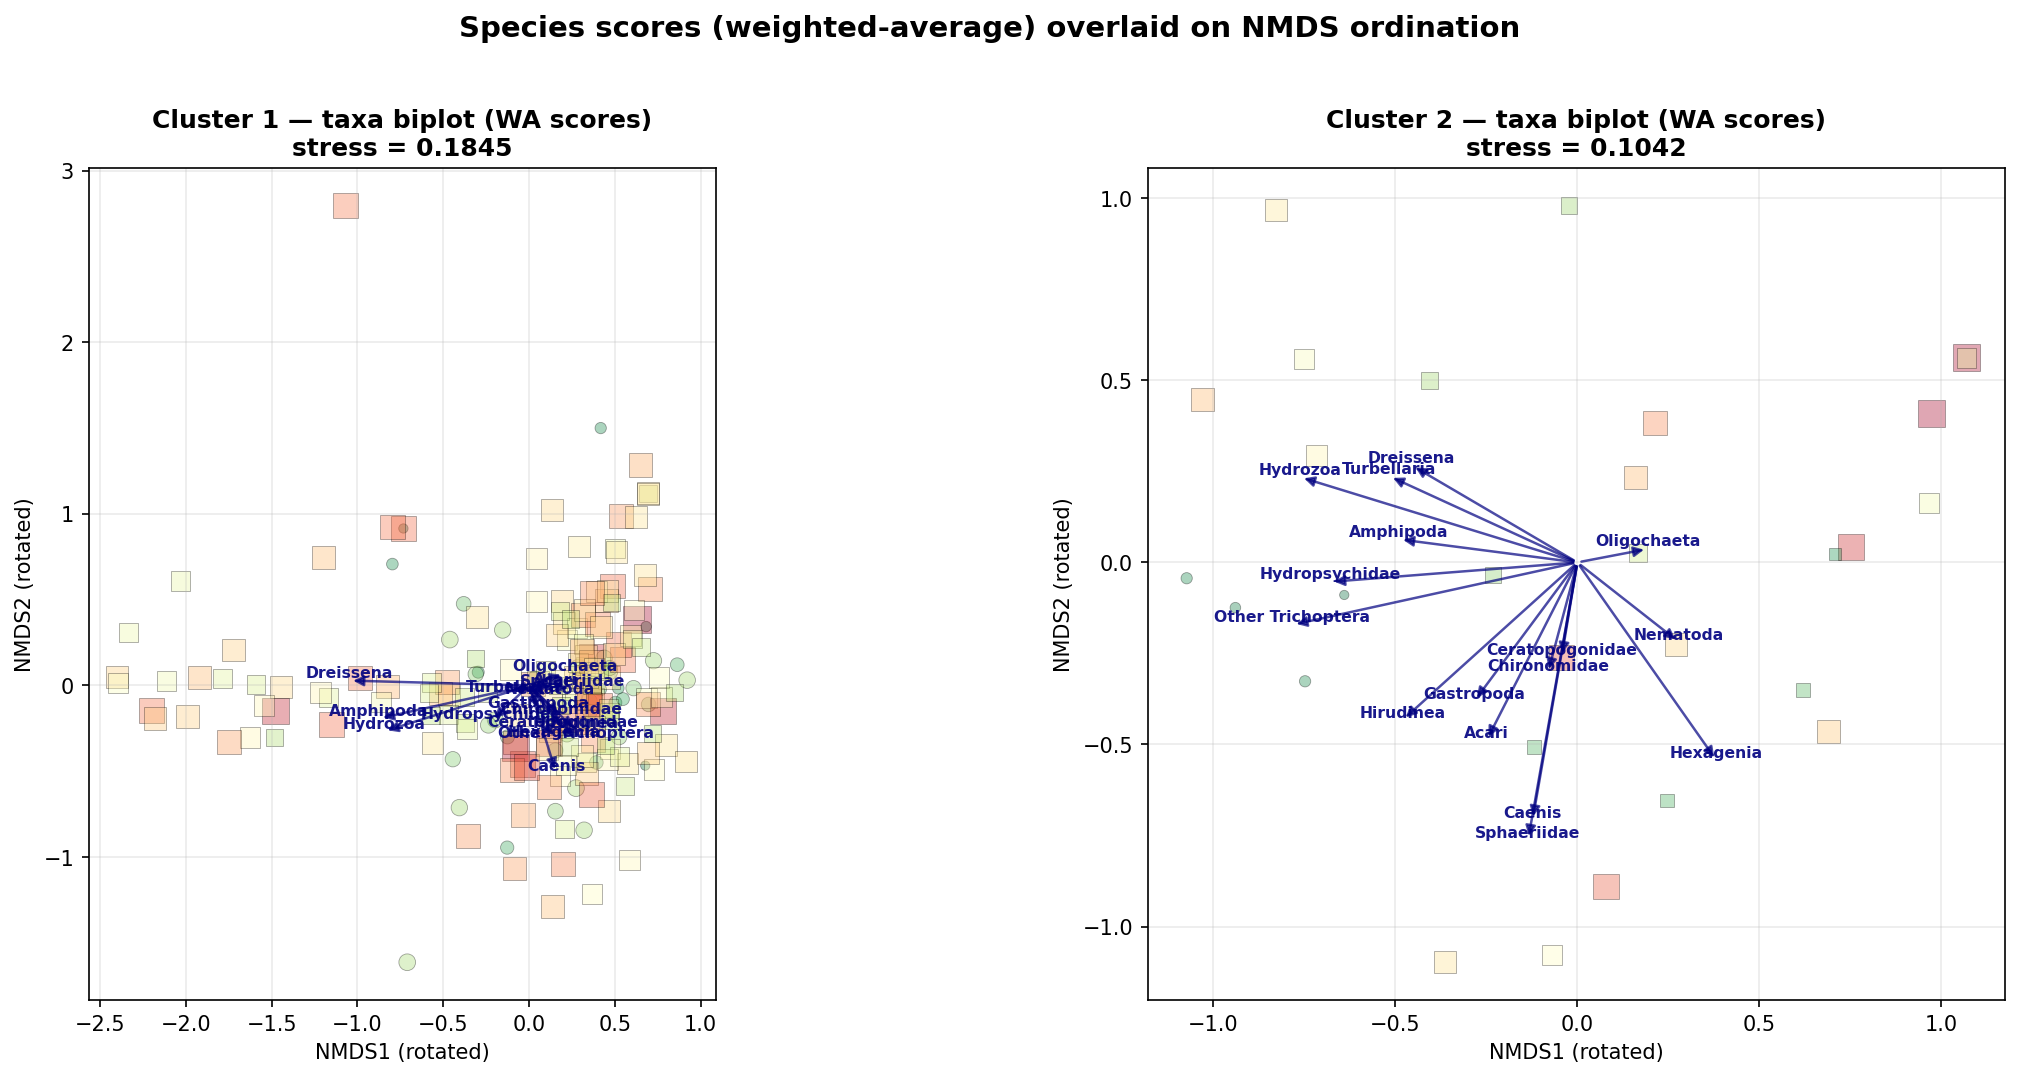


Cluster 1 — Weighted-average species scores
                      WA1     WA2
Acari              0.1511 -0.0102
Amphipoda         -0.8747 -0.1925
Caenis             0.1580 -0.5106
Ceratopogonidae    0.1977 -0.2560
Chironomidae       0.1904 -0.1829
Dreissena         -1.0494  0.0283
Gastropoda         0.0523 -0.1483
Hexagenia          0.1480 -0.3148
Hirudinea          0.2747 -0.2621
Hydropsychidae    -0.2201 -0.2075
Hydrozoa          -0.8475 -0.2689
Nematoda           0.1190 -0.0651
Oligochaeta        0.2083  0.0707
Other Trichoptera  0.2761 -0.3232
Sphaeriidae        0.2529 -0.0172
Turbellaria       -0.0904 -0.0539

Cluster 2 — Weighted-average species scores
                      WA1     WA2
Acari             -0.2494 -0.4893
Amphipoda         -0.4900  0.0635
Caenis            -0.1232 -0.7092
Ceratopogonidae   -0.0432 -0.2607
Chironomidae      -0.0812 -0.3041
Dreissena         -0.4548  0.2665
Gastropoda        -0.2829 -0.3811
Hexagenia          0.3825 -0.5448
Hirudinea         -0.4800 

In [90]:
# ── Species (taxa) scores: weighted-average biplot ────────────────────────────
from matplotlib.patches import FancyArrowPatch
try:
    from adjustText import adjust_text
except ModuleNotFoundError:
    adjust_text = None   # labels won't be auto-dodged but everything else works

fig, axes = plt.subplots(1, n_clusters, figsize=(8 * n_clusters, 7), dpi=150)
if n_clusters == 1:
    axes = [axes]

for ax, cl in zip(axes, clusters):
    coords_rot = nmds_rotated[cl]                     # from §11
    cl_sites   = coords_rot.index
    taxa_cl    = taxa.loc[cl_sites]
    meta_cl    = site_meta.loc[cl_sites]

    # ── 1. Weighted-average species scores ────────────────────────────────────
    # WA_j = Σ_i (y_ij * x_i) / Σ_i (y_ij)
    abund = taxa_cl.values                            # (n_sites, 16)
    site_coords = coords_rot.values                   # (n_sites, 2)
    col_sums = abund.sum(axis=0)                      # (16,)
    col_sums[col_sums == 0] = 1e-12                   # avoid div-by-zero
    wa_scores = (abund.T @ site_coords) / col_sums[:, None]  # (16, 2)

    wa_df = pd.DataFrame(wa_scores, index=TAXA_COLUMNS,
                         columns=["WA1", "WA2"])

    # ── 2. Plot site scores (faded) ──────────────────────────────────────────
    ref_mask = meta_cl["Is_Reference"] == 1
    ps = meta_cl["Pollution_Score"]
    ps_norm = (ps - ps.min()) / (ps.max() - ps.min() + 1e-9) * 150 + 20

    ax.scatter(
        coords_rot.loc[ref_mask, "NMDS1_rot"],
        coords_rot.loc[ref_mask, "NMDS2_rot"],
        s=ps_norm[ref_mask], c=ps[ref_mask], cmap="RdYlGn_r",
        marker="o", edgecolors="k", linewidths=0.4, alpha=0.35,
        vmin=ps.min(), vmax=ps.max(),
    )
    ax.scatter(
        coords_rot.loc[~ref_mask, "NMDS1_rot"],
        coords_rot.loc[~ref_mask, "NMDS2_rot"],
        s=ps_norm[~ref_mask], c=ps[~ref_mask], cmap="RdYlGn_r",
        marker="s", edgecolors="k", linewidths=0.4, alpha=0.35,
        vmin=ps.min(), vmax=ps.max(),
    )

    # ── 3. Overlay taxa arrows + labels ──────────────────────────────────────
    origin = site_coords.mean(axis=0)                 # ordination centroid
    texts = []
    for j, taxon in enumerate(TAXA_COLUMNS):
        dx, dy = wa_scores[j, 0] - origin[0], wa_scores[j, 1] - origin[1]
        ax.annotate(
            "",
            xy=(wa_scores[j, 0], wa_scores[j, 1]),
            xytext=(origin[0], origin[1]),
            arrowprops=dict(arrowstyle="-|>", color="navy", lw=1.2, alpha=0.7),
        )
        t = ax.text(wa_scores[j, 0], wa_scores[j, 1], taxon,
                    fontsize=7.5, fontweight="bold", color="navy", alpha=0.9,
                    ha="center", va="bottom")
        texts.append(t)

    # dodge overlapping labels
    if adjust_text is not None:
        try:
            adjust_text(texts, ax=ax, arrowprops=dict(arrowstyle="-", color="gray", lw=0.4))
        except Exception:
            pass

    ax.set_title(f"Cluster {cl} — taxa biplot (WA scores)\nstress = {nmds_results[cl][1]:.4f}",
                 fontsize=12, fontweight="bold")
    ax.set_xlabel("NMDS1 (rotated)")
    ax.set_ylabel("NMDS2 (rotated)")
    ax.set_aspect("equal")
    ax.grid(alpha=0.25)

fig.suptitle("Species scores (weighted-average) overlaid on NMDS ordination",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

# ── Print WA scores table ────────────────────────────────────────────────────
for cl in clusters:
    coords_rot = nmds_rotated[cl]
    cl_sites   = coords_rot.index
    taxa_cl    = taxa.loc[cl_sites]
    abund      = taxa_cl.values
    site_coords = coords_rot.values
    col_sums   = abund.sum(axis=0)
    col_sums[col_sums == 0] = 1e-12
    wa_scores  = (abund.T @ site_coords) / col_sums[:, None]
    wa_df      = pd.DataFrame(wa_scores, index=TAXA_COLUMNS, columns=["WA1", "WA2"])
    print(f"\n{'='*50}")
    print(f"Cluster {cl} — Weighted-average species scores")
    print(f"{'='*50}")
    print(wa_df.round(4).to_string())

## 13 · Waterbody labels projected onto the ordination

If community composition is driven partly by geography, sites from the same **waterbody** should cluster together in ordination space.  We colour / label each site by its `Waterbody` attribute to check for spatial structure.

Waterbody value counts:
 Waterbody
DR     146
LSC     67
SCR     20
Name: count, dtype: int64


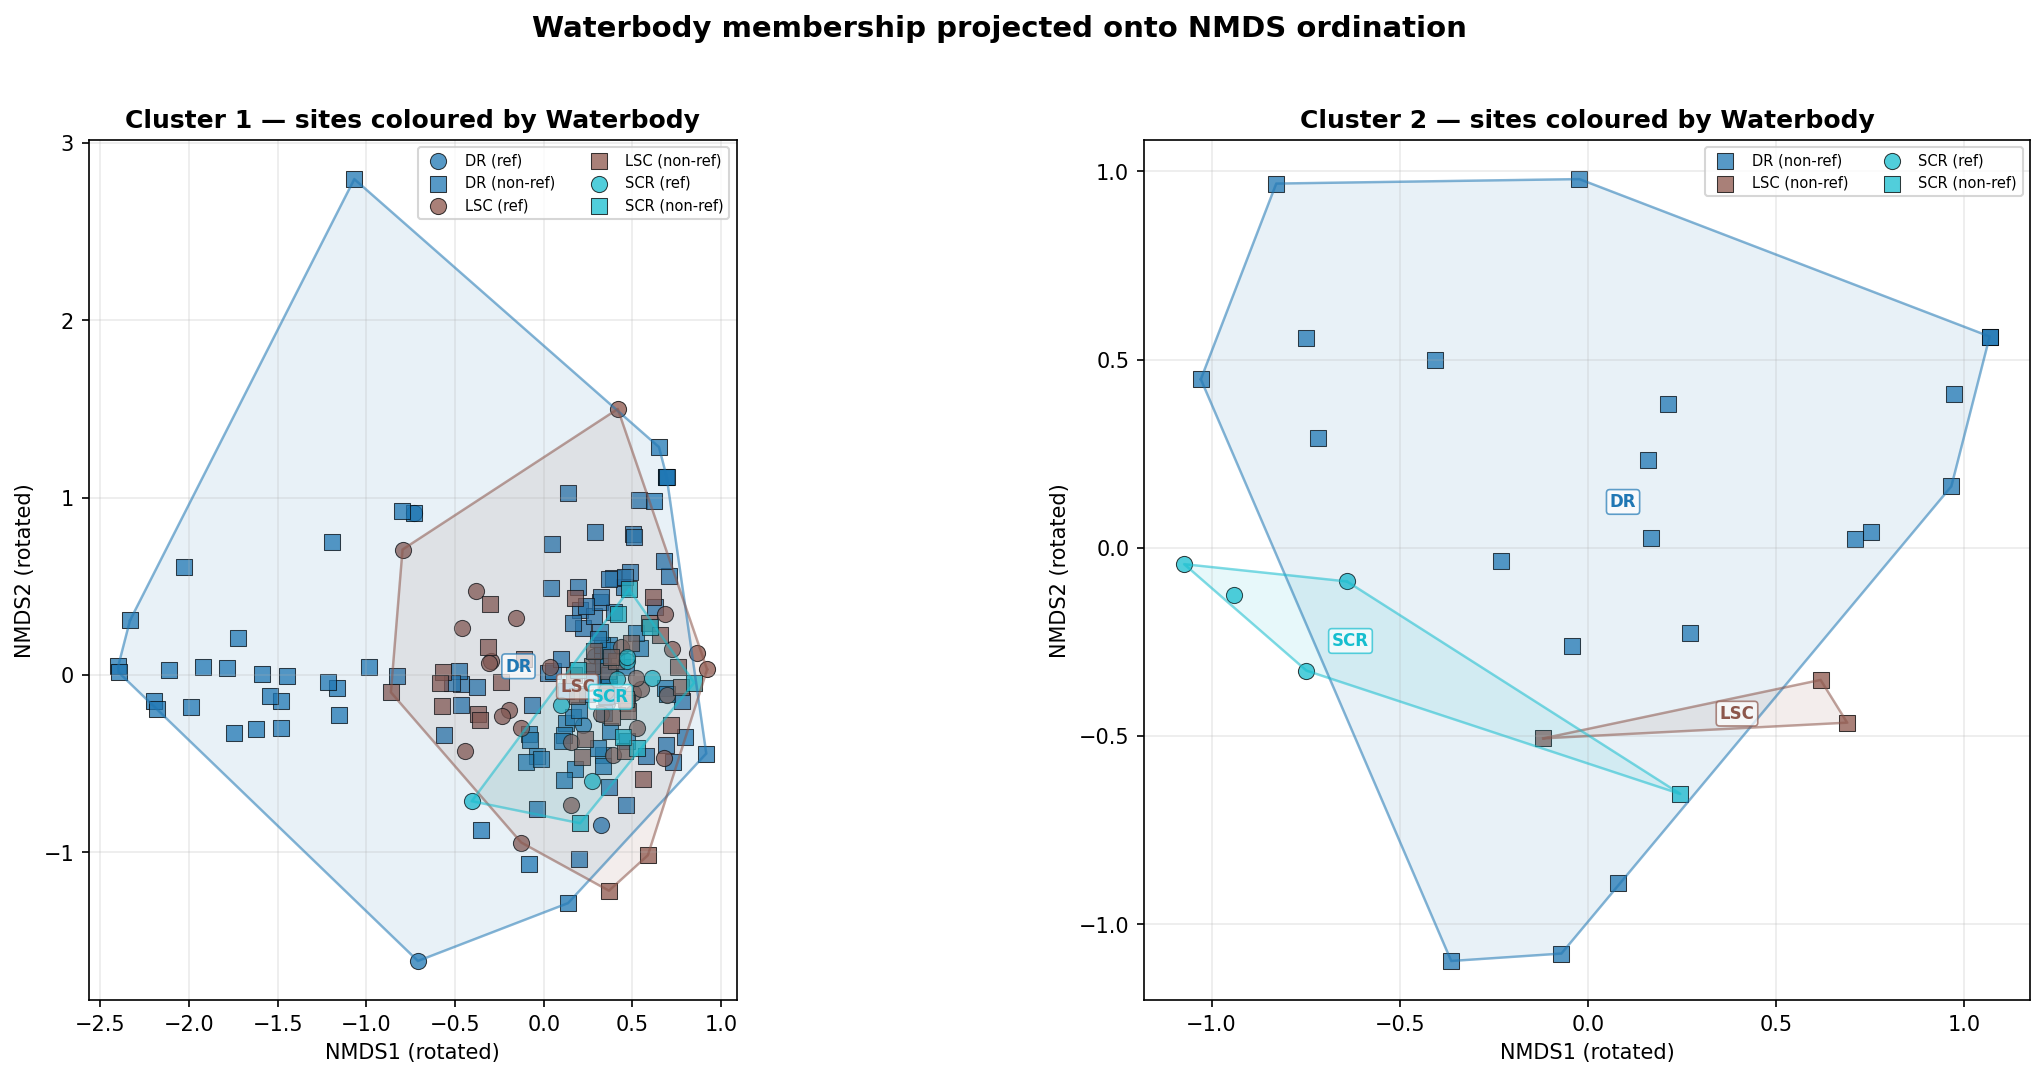


Cluster 1 — waterbody counts:
Waterbody
DR     125
LSC     64
SCR     15

Cluster 2 — waterbody counts:
Waterbody
DR     21
SCR     5
LSC     3


In [91]:
# ── Waterbody labels on the ordination ─────────────────────────────────────────

# Extract waterbody from the master data
waterbody = extract_block(data, "sample_info", "raw").loc[common_idx, "Waterbody"]
waterbody.name = "Waterbody"
print("Waterbody value counts:\n", waterbody.value_counts())

# Assign a colour per waterbody
wb_unique = sorted(waterbody.unique())
cmap_wb   = plt.colormaps.get_cmap("tab10").resampled(len(wb_unique))
wb_colors = {wb: cmap_wb(i) for i, wb in enumerate(wb_unique)}

# ── Plot per cluster ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, n_clusters, figsize=(8 * n_clusters, 7), dpi=150)
if n_clusters == 1:
    axes = [axes]

for ax, cl in zip(axes, clusters):
    coords_rot = nmds_rotated[cl]
    cl_sites   = coords_rot.index
    meta_cl    = site_meta.loc[cl_sites]
    wb_cl      = waterbody.loc[cl_sites]

    # scatter coloured by waterbody
    for wb in wb_unique:
        mask = wb_cl == wb
        if mask.sum() == 0:
            continue
        ref = meta_cl.loc[mask, "Is_Reference"] == 1
        # reference = circle, non-ref = square
        for is_ref, marker in [(True, "o"), (False, "s")]:
            sub = mask & (ref if is_ref else ~ref)
            if sub.sum() == 0:
                continue
            ax.scatter(
                coords_rot.loc[sub, "NMDS1_rot"],
                coords_rot.loc[sub, "NMDS2_rot"],
                s=60, c=[wb_colors[wb]], marker=marker,
                edgecolors="k", linewidths=0.5, alpha=0.75,
                label=f"{wb} ({'ref' if is_ref else 'non-ref'})",
            )

    # draw convex hulls per waterbody (if ≥3 sites)
    from scipy.spatial import ConvexHull
    for wb in wb_unique:
        mask = wb_cl == wb
        pts  = coords_rot.loc[mask].values
        if len(pts) >= 3:
            try:
                hull = ConvexHull(pts)
                hull_pts = np.append(hull.vertices, hull.vertices[0])
                ax.fill(pts[hull_pts, 0], pts[hull_pts, 1],
                        color=wb_colors[wb], alpha=0.10)
                ax.plot(pts[hull_pts, 0], pts[hull_pts, 1],
                        color=wb_colors[wb], lw=1.2, alpha=0.5)
            except Exception:
                pass

    # waterbody centroids as large text labels
    for wb in wb_unique:
        mask = wb_cl == wb
        if mask.sum() == 0:
            continue
        cx = coords_rot.loc[mask, "NMDS1_rot"].mean()
        cy = coords_rot.loc[mask, "NMDS2_rot"].mean()
        ax.text(cx, cy, wb, fontsize=8, fontweight="bold",
                ha="center", va="center", color=wb_colors[wb],
                bbox=dict(boxstyle="round,pad=0.2", fc="white", ec=wb_colors[wb],
                          alpha=0.7, lw=0.8))

    ax.set_title(f"Cluster {cl} — sites coloured by Waterbody",
                 fontsize=12, fontweight="bold")
    ax.set_xlabel("NMDS1 (rotated)")
    ax.set_ylabel("NMDS2 (rotated)")
    ax.set_aspect("equal")
    ax.grid(alpha=0.25)

    # deduplicate legend
    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    ax.legend(by_label.values(), by_label.keys(),
              fontsize=7, loc="best", ncol=2, framealpha=0.8)

fig.suptitle("Waterbody membership projected onto NMDS ordination",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

# ── per-waterbody summary ─────────────────────────────────────────────────────
for cl in clusters:
    coords_rot = nmds_rotated[cl]
    cl_sites = coords_rot.index
    wb_cl = waterbody.loc[cl_sites]
    print(f"\nCluster {cl} — waterbody counts:")
    print(wb_cl.value_counts().to_string())

## 14 · Zoobenthos Community Index (ZCI) via NMDS endpoint projection

### Idea
Compress the 2-D NMDS ordination into a **single degradation score** per site by defining two hypothetical "endpoint" sites in each cluster:

| Endpoint | Construction | ZCI value |
|----------|-------------|-----------|
| **Reference endpoint** | Mean taxa vector of the 5 **least**-polluted sites | 1 |
| **Degraded endpoint** | Mean taxa vector of the 5 **most**-polluted sites | 0 |

These endpoints are appended to the taxa matrix **before** computing the Bray-Curtis distance matrix and running NMDS, so they participate in the ordination.

### ZCI formula
In ordination space, for each real site $i$ let

$$d_i^{\text{ref}} = \lVert \mathbf{x}_i - \mathbf{x}_{\text{ref}} \rVert, \qquad d_i^{\text{deg}} = \lVert \mathbf{x}_i - \mathbf{x}_{\text{deg}} \rVert$$

then

$$\text{ZCI}_i = \frac{d_i^{\text{deg}}}{d_i^{\text{ref}} + d_i^{\text{deg}}}$$

- At the reference endpoint: $d^{\text{ref}}=0 \Rightarrow \text{ZCI}=1$.
- At the degraded endpoint: $d^{\text{deg}}=0 \Rightarrow \text{ZCI}=0$.
- Sites closer to the reference community receive higher ZCI.

### Is this logical?
Yes — this is a well-established idea in bioassessment.  It projects the multivariate community-composition space onto a **one-dimensional gradient** anchored by ecologically meaningful reference conditions.  The ratio formulation ensures ZCI ∈ [0, 1] and is scale-invariant.  It is essentially the same principle behind many multimetric indices (e.g., B-IBI, RIVPACS O/E) that measure distance-to-reference.

> **One caveat:** sites can fall *outside* the line segment between the two endpoints (i.e., they are not "between" them in 2-D).  The ratio formula still works, but ZCI can exceed 1 (site closer to reference than the reference endpoint) or drop below 0 (site more degraded than the degraded endpoint).  We will clip to [0, 1] and flag any such sites.

### Step 1 — Identify the 5 least- and 5 most-polluted sites per cluster and build endpoint taxa vectors

In [92]:
# ── Step 1: Build reference and degraded endpoints per cluster ─────────────────
N_ENDPOINT = 5   # number of sites averaged for each endpoint

endpoint_info = {}   # cl -> dict with keys: ref_sites, deg_sites, ref_taxa, deg_taxa

for cl in clusters:
    cl_sites = site_meta.index[site_meta["Cluster"] == cl]
    meta_cl  = site_meta.loc[cl_sites]
    taxa_cl  = taxa.loc[cl_sites]

    # rank by pollution score
    ps_sorted = meta_cl["Pollution_Score"].sort_values()

    # 5 least-polluted → reference endpoint
    ref_ids = ps_sorted.index[:N_ENDPOINT]
    ref_taxa_vec = taxa_cl.loc[ref_ids].mean(axis=0)   # average taxa vector

    # 5 most-polluted → degraded endpoint
    deg_ids = ps_sorted.index[-N_ENDPOINT:]
    deg_taxa_vec = taxa_cl.loc[deg_ids].mean(axis=0)

    endpoint_info[cl] = {
        "ref_sites":   ref_ids.tolist(),
        "deg_sites":   deg_ids.tolist(),
        "ref_taxa":    ref_taxa_vec,
        "deg_taxa":    deg_taxa_vec,
        "ref_ps_mean": meta_cl.loc[ref_ids, "Pollution_Score"].mean(),
        "deg_ps_mean": meta_cl.loc[deg_ids, "Pollution_Score"].mean(),
    }

    print(f"\n{'='*70}")
    print(f"Cluster {cl}  (n = {len(cl_sites)})")
    print(f"{'='*70}")
    print(f"\n  Reference endpoint  (5 least-polluted sites)")
    print(f"    Sites: {ref_ids.tolist()}")
    print(f"    Pollution scores: {meta_cl.loc[ref_ids, 'Pollution_Score'].values}")
    print(f"    Mean PS: {endpoint_info[cl]['ref_ps_mean']:.4f}")
    print(f"\n  Degraded endpoint  (5 most-polluted sites)")
    print(f"    Sites: {deg_ids.tolist()}")
    print(f"    Pollution scores: {meta_cl.loc[deg_ids, 'Pollution_Score'].values}")
    print(f"    Mean PS: {endpoint_info[cl]['deg_ps_mean']:.4f}")

    print(f"\n  Endpoint taxa vectors:")
    ep_df = pd.DataFrame({"Reference": ref_taxa_vec, "Degraded": deg_taxa_vec})
    print(ep_df.round(4).to_string())


Cluster 1  (n = 204)

  Reference endpoint  (5 least-polluted sites)
    Sites: ['S38', '075A', 'S65', 'S53', 'S54']
    Pollution scores: [1.5005367  1.50459411 1.58438888 1.64410592 1.67450653]
    Mean PS: 1.5816

  Degraded endpoint  (5 most-polluted sites)
    Sites: ['088C', '007ABC', '081B', '089A', '101C']
    Pollution scores: [3.62611454 3.63512929 3.64091597 3.69481719 3.75194223]
    Mean PS: 3.6698

  Endpoint taxa vectors:
                   Reference  Degraded
var                                   
Acari                 0.0000    0.0000
Amphipoda             0.0000    0.3680
Caenis                0.5018    0.0068
Ceratopogonidae       0.0000    0.9496
Chironomidae          1.9337    4.0063
Dreissena             2.2277    1.7894
Gastropoda            1.6652    0.4943
Hexagenia             0.0000    1.3223
Hirudinea             0.0000    0.0461
Hydropsychidae        0.0000    0.0000
Hydrozoa              0.4491    0.3642
Nematoda              0.5252    1.5678
Oligochaeta 

### Step 2 — Augment the taxa matrix with endpoints, compute Bray-Curtis, run 2-D NMDS

In [93]:
# ── Step 2: Augment taxa matrix with endpoints → BC → 2-D NMDS ───────────────

zci_nmds = {}  # cl -> dict(coords, stress, dist_mat, ref_label, deg_label)

for cl in clusters:
    cl_sites = site_meta.index[site_meta["Cluster"] == cl]
    taxa_cl  = taxa.loc[cl_sites].copy()

    ep = endpoint_info[cl]
    ref_label = f"_REF_ENDPOINT_{cl}"
    deg_label = f"_DEG_ENDPOINT_{cl}"

    # Append the two endpoint rows
    taxa_aug = pd.concat([
        taxa_cl,
        pd.DataFrame([ep["ref_taxa"]], index=[ref_label], columns=TAXA_COLUMNS),
        pd.DataFrame([ep["deg_taxa"]], index=[deg_label], columns=TAXA_COLUMNS),
    ])
    print(f"Cluster {cl}: augmented taxa shape = {taxa_aug.shape}  "
          f"(+2 endpoints: '{ref_label}', '{deg_label}')")

    # Bray-Curtis distance matrix on augmented matrix
    bc_sq = squareform(pdist(taxa_aug.values, metric="braycurtis"))

    # 2-D non-metric MDS
    nmds = MDS(
        n_components=2,
        metric_mds=False,
        metric="precomputed",
        max_iter=500,
        n_init=10,
        init="random",
        random_state=42,
        normalized_stress="auto",
    )
    coords_arr = nmds.fit_transform(bc_sq)

    coords_df = pd.DataFrame(
        coords_arr,
        index=taxa_aug.index,
        columns=["NMDS1", "NMDS2"],
    )
    dist_df = pd.DataFrame(bc_sq, index=taxa_aug.index, columns=taxa_aug.index)

    zci_nmds[cl] = {
        "coords":    coords_df,
        "stress":    nmds.stress_,
        "dist_mat":  dist_df,
        "ref_label": ref_label,
        "deg_label": deg_label,
        "taxa_aug":  taxa_aug,
    }
    print(f"  stress = {nmds.stress_:.6f}")

print("\nDone ✓")

Cluster 1: augmented taxa shape = (206, 16)  (+2 endpoints: '_REF_ENDPOINT_1', '_DEG_ENDPOINT_1')
  stress = 0.186607
Cluster 2: augmented taxa shape = (31, 16)  (+2 endpoints: '_REF_ENDPOINT_2', '_DEG_ENDPOINT_2')
  stress = 0.104753

Done ✓


### Step 3 — Visualize the NMDS ordination with endpoint markers

- 🔴 **tick mark** ( | ) → Reference endpoint
- ❌ **cross mark** ( × ) → Degraded endpoint

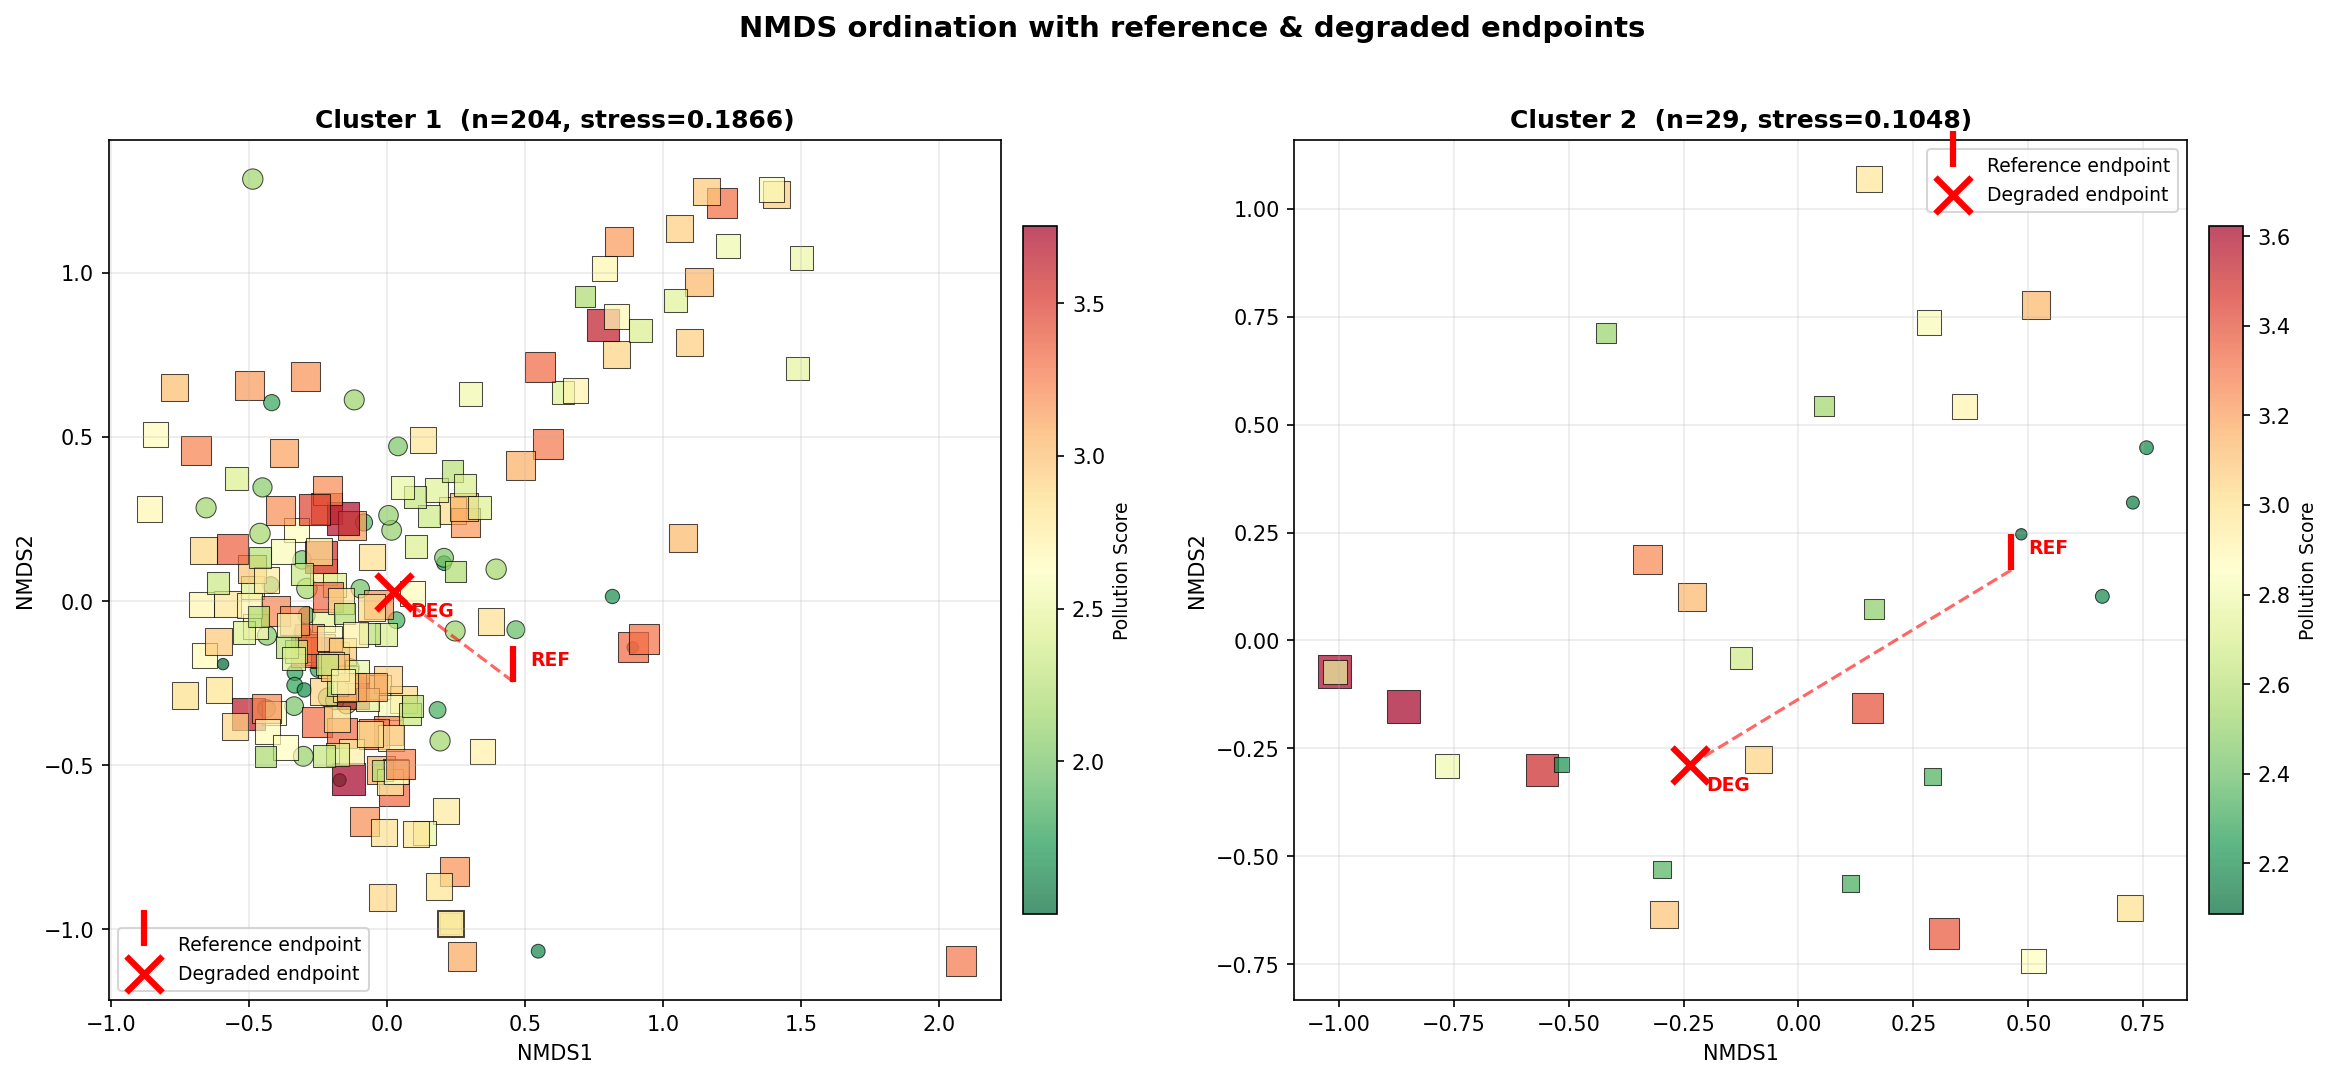

In [94]:
# ── Step 3: Visualize NMDS ordination with endpoints ──────────────────────────

fig, axes = plt.subplots(1, n_clusters, figsize=(8 * n_clusters, 7), dpi=150)
if n_clusters == 1:
    axes = [axes]

for ax, cl in zip(axes, clusters):
    info = zci_nmds[cl]
    coords = info["coords"]
    ref_lab = info["ref_label"]
    deg_lab = info["deg_label"]
    stress  = info["stress"]

    # separate real sites from endpoints
    real_idx = [i for i in coords.index if i not in (ref_lab, deg_lab)]
    meta_cl  = site_meta.loc[real_idx]

    ref_mask = meta_cl["Is_Reference"] == 1
    ps = meta_cl["Pollution_Score"]
    ps_norm = (ps - ps.min()) / (ps.max() - ps.min() + 1e-9) * 220 + 30

    # real sites coloured by pollution score
    ax.scatter(
        coords.loc[ref_mask.index[ref_mask], "NMDS1"],
        coords.loc[ref_mask.index[ref_mask], "NMDS2"],
        s=ps_norm[ref_mask], c=ps[ref_mask], cmap="RdYlGn_r",
        marker="o", edgecolors="k", linewidths=0.5, alpha=0.7,
        vmin=ps.min(), vmax=ps.max(),
    )
    sc = ax.scatter(
        coords.loc[ref_mask.index[~ref_mask], "NMDS1"],
        coords.loc[ref_mask.index[~ref_mask], "NMDS2"],
        s=ps_norm[~ref_mask], c=ps[~ref_mask], cmap="RdYlGn_r",
        marker="s", edgecolors="k", linewidths=0.5, alpha=0.7,
        vmin=ps.min(), vmax=ps.max(),
    )

    # ── Reference endpoint: red tick ──────────────────────────────────────
    ax.scatter(
        coords.loc[ref_lab, "NMDS1"], coords.loc[ref_lab, "NMDS2"],
        s=300, c="red", marker=2, linewidths=3, zorder=10,
        label="Reference endpoint",
    )
    ax.annotate("REF", xy=(coords.loc[ref_lab, "NMDS1"], coords.loc[ref_lab, "NMDS2"]),
                xytext=(8, 8), textcoords="offset points",
                fontsize=9, fontweight="bold", color="red")

    # ── Degraded endpoint: red cross ──────────────────────────────────────
    ax.scatter(
        coords.loc[deg_lab, "NMDS1"], coords.loc[deg_lab, "NMDS2"],
        s=300, c="red", marker="x", linewidths=3, zorder=10,
        label="Degraded endpoint",
    )
    ax.annotate("DEG", xy=(coords.loc[deg_lab, "NMDS1"], coords.loc[deg_lab, "NMDS2"]),
                xytext=(8, -12), textcoords="offset points",
                fontsize=9, fontweight="bold", color="red")

    # dashed line connecting the two endpoints (the "gradient axis")
    ax.plot(
        [coords.loc[ref_lab, "NMDS1"], coords.loc[deg_lab, "NMDS1"]],
        [coords.loc[ref_lab, "NMDS2"], coords.loc[deg_lab, "NMDS2"]],
        ls="--", color="red", lw=1.5, alpha=0.6, zorder=5,
    )

    ax.set_title(f"Cluster {cl}  (n={len(real_idx)}, stress={stress:.4f})",
                 fontsize=12, fontweight="bold")
    ax.set_xlabel("NMDS1")
    ax.set_ylabel("NMDS2")
    ax.grid(alpha=0.25)

    cb = fig.colorbar(sc, ax=ax, shrink=0.8, pad=0.02)
    cb.set_label("Pollution Score", fontsize=9)

    ax.legend(fontsize=9, loc="best")

fig.suptitle("NMDS ordination with reference & degraded endpoints",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### Step 4 — Compute ZCI and visualize

$$\text{ZCI}_i = \frac{d_i^{\text{deg}}}{d_i^{\text{ref}} + d_i^{\text{deg}}}$$

Reference endpoint → ZCI = 1, Degraded endpoint → ZCI = 0.

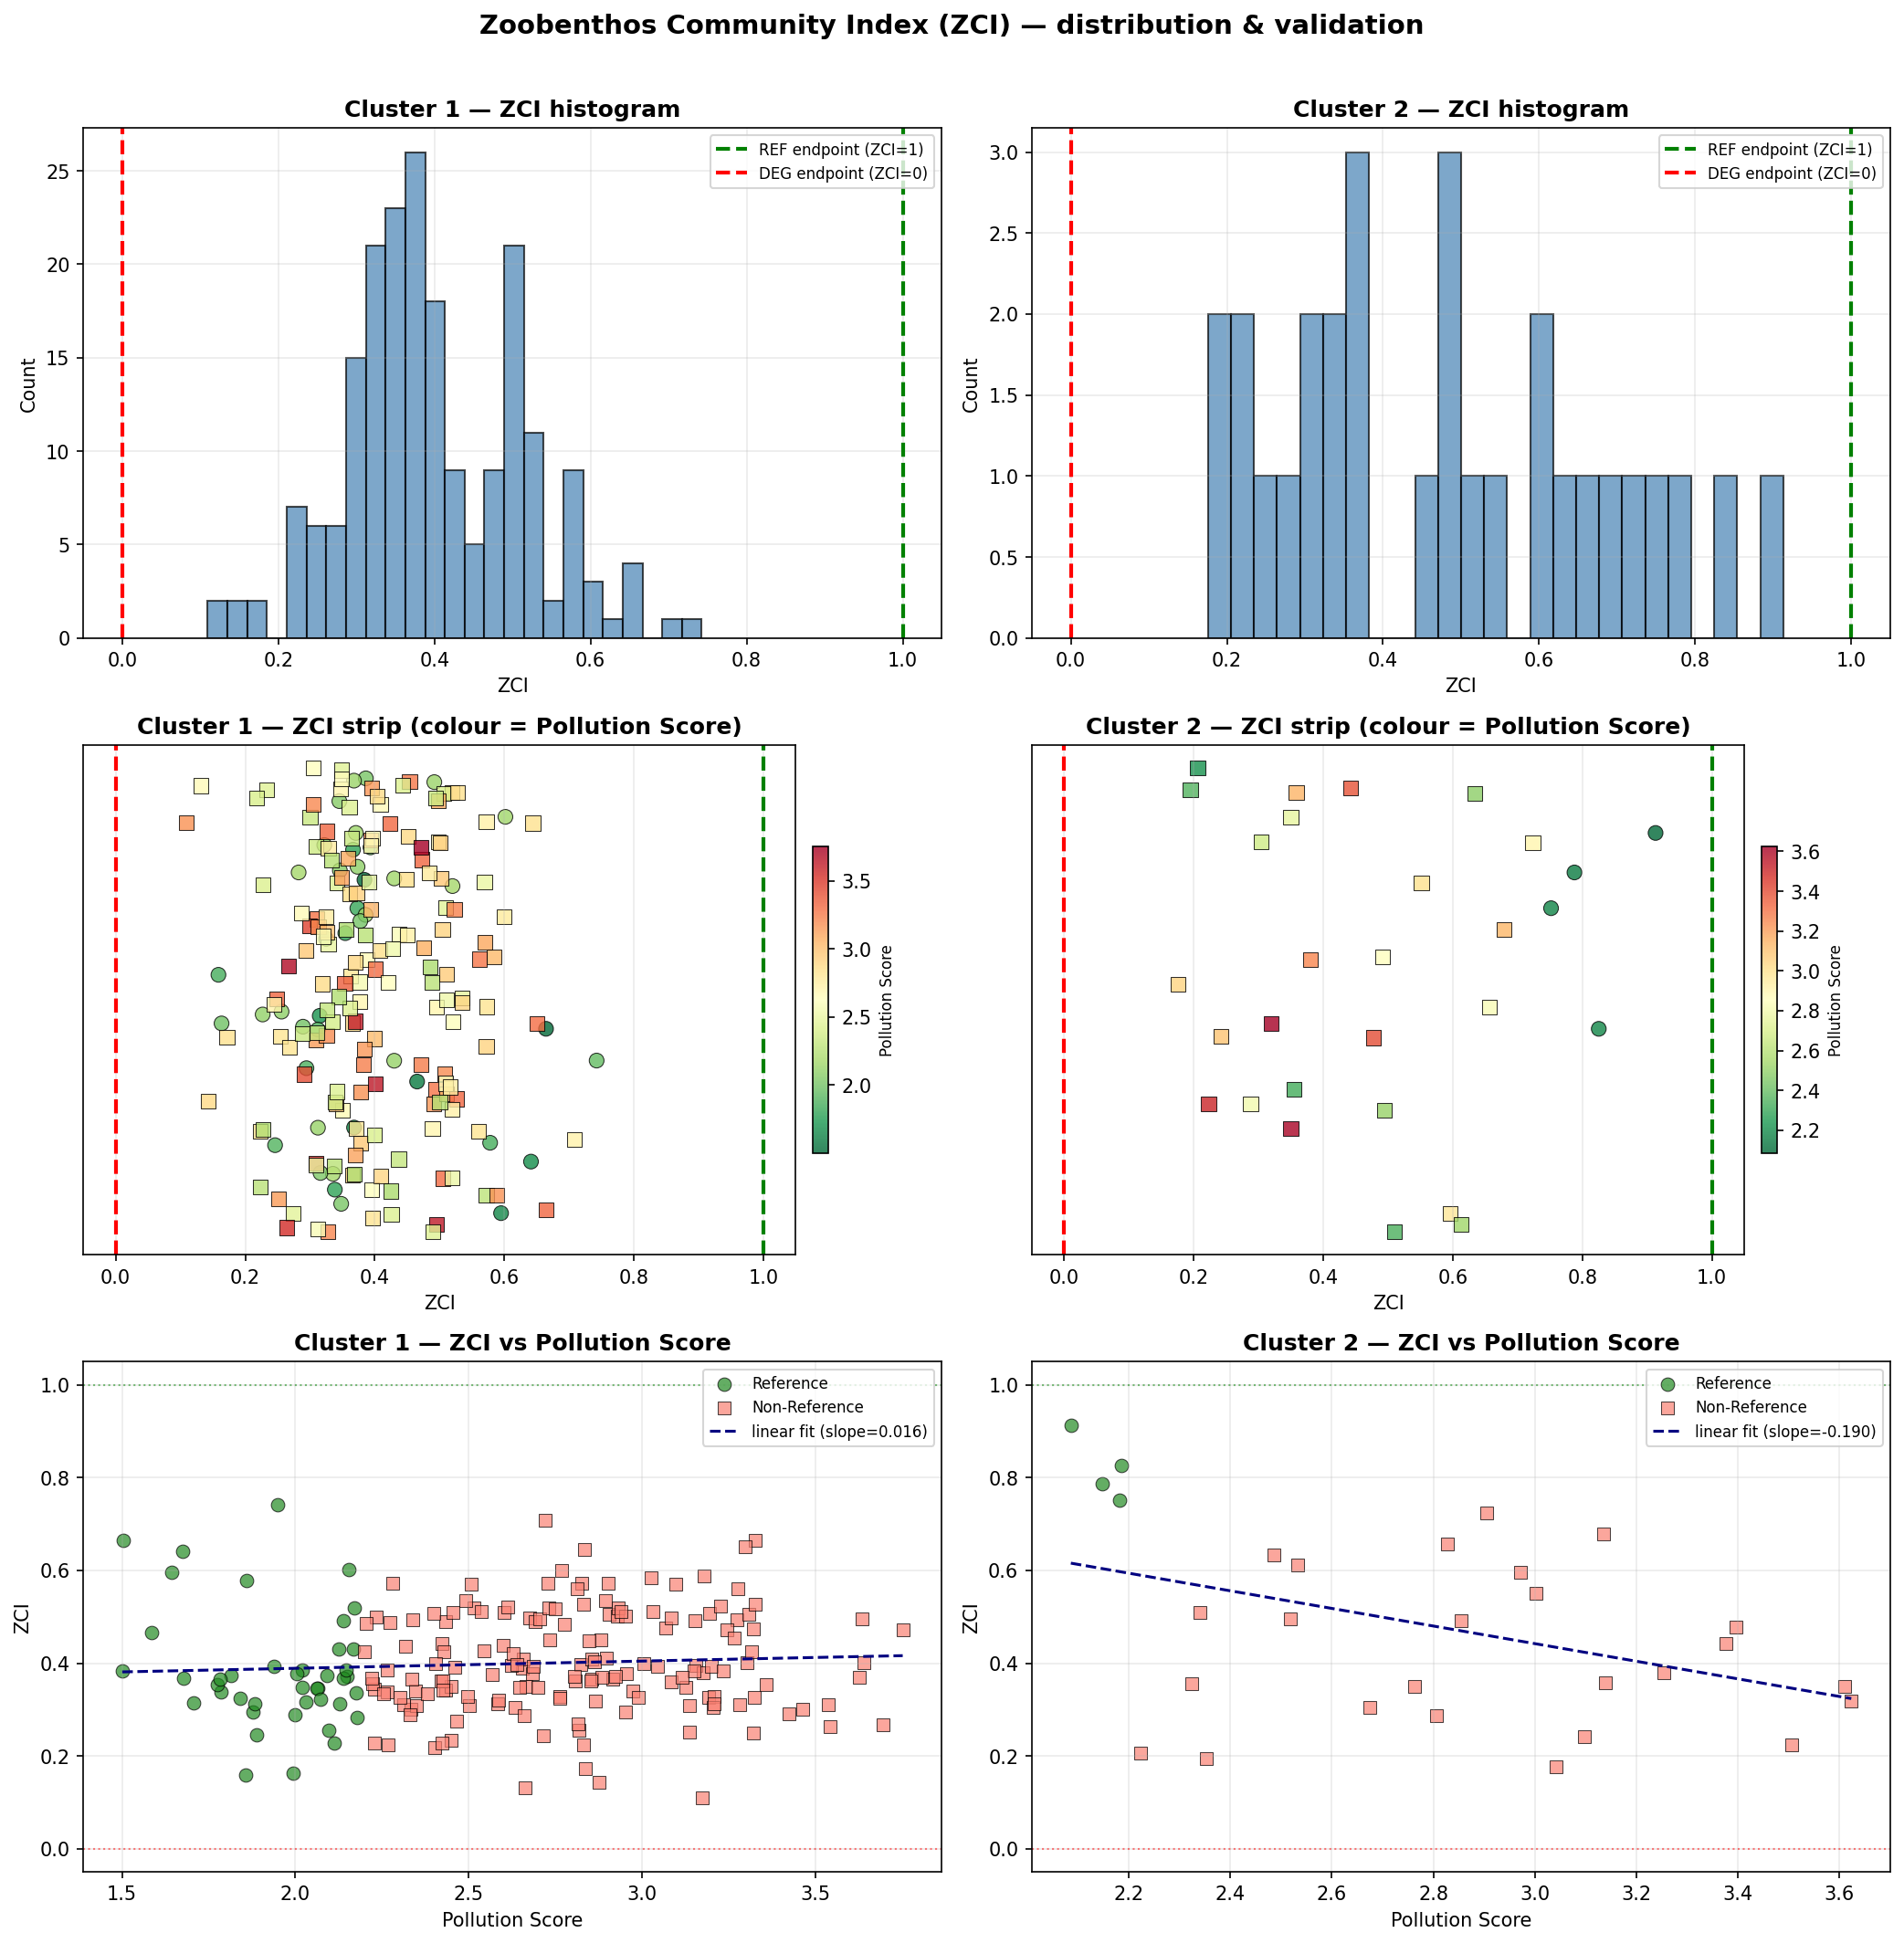


Cluster 1 — ZCI summary
count    204.0000
mean       0.3988
std        0.1137
min        0.1095
25%        0.3253
50%        0.3778
75%        0.4909
max        0.7425

  Correlation with Pollution Score: r = 0.0673

Cluster 2 — ZCI summary
count    29.0000
mean      0.4790
std       0.2077
min       0.1758
25%       0.3192
50%       0.4773
75%       0.6341
max       0.9129

  Correlation with Pollution Score: r = -0.4275


In [95]:
# ── Step 4: Compute ZCI and visualize ─────────────────────────────────────────

zci_all = {}  # cl -> Series of ZCI values (indexed by StationID)

for cl in clusters:
    info   = zci_nmds[cl]
    coords = info["coords"]
    ref_lab = info["ref_label"]
    deg_lab = info["deg_label"]

    ref_xy = coords.loc[ref_lab].values   # (2,)
    deg_xy = coords.loc[deg_lab].values   # (2,)

    real_idx = [i for i in coords.index if i not in (ref_lab, deg_lab)]
    real_coords = coords.loc[real_idx].values   # (n, 2)

    d_ref = np.linalg.norm(real_coords - ref_xy, axis=1)
    d_deg = np.linalg.norm(real_coords - deg_xy, axis=1)

    zci_raw = d_deg / (d_ref + d_deg + 1e-15)   # avoid 0/0

    zci_series = pd.Series(zci_raw, index=real_idx, name="ZCI")
    zci_all[cl] = zci_series

    # flag sites outside [0, 1]
    n_above = (zci_raw > 1).sum()
    n_below = (zci_raw < 0).sum()
    if n_above + n_below > 0:
        print(f"Cluster {cl}: {n_above} sites with ZCI > 1, {n_below} sites with ZCI < 0 (before clipping)")

# ── Visualisation panel: 3 rows per cluster ───────────────────────────────────
# Row 1: histogram of ZCI
# Row 2: strip / swarm coloured by pollution score
# Row 3: ZCI vs Pollution Score scatter

fig, axes = plt.subplots(3, n_clusters, figsize=(7 * n_clusters, 14), dpi=150)
if n_clusters == 1:
    axes = axes.reshape(3, 1)

for col_i, cl in enumerate(clusters):
    zci = zci_all[cl]
    meta_cl = site_meta.loc[zci.index]
    ps = meta_cl["Pollution_Score"]

    # ── Row 1: Histogram ──────────────────────────────────────────────────
    ax1 = axes[0, col_i]
    ax1.hist(zci, bins=25, color="steelblue", edgecolor="k", alpha=0.7)
    ax1.axvline(1.0, color="green", ls="--", lw=2, label="REF endpoint (ZCI=1)")
    ax1.axvline(0.0, color="red",   ls="--", lw=2, label="DEG endpoint (ZCI=0)")
    ax1.set_xlabel("ZCI")
    ax1.set_ylabel("Count")
    ax1.set_title(f"Cluster {cl} — ZCI histogram", fontweight="bold")
    ax1.legend(fontsize=8)
    ax1.grid(alpha=0.25)

    # ── Row 2: Strip plot coloured by pollution score ─────────────────────
    ax2 = axes[1, col_i]
    ref_mask = meta_cl["Is_Reference"] == 1
    ax2.scatter(
        zci[ref_mask.index[ref_mask]],
        np.random.default_rng(42).uniform(-0.3, 0.3, size=ref_mask.sum()),
        c=ps[ref_mask], cmap="RdYlGn_r", marker="o",
        s=60, edgecolors="k", linewidths=0.5, alpha=0.8,
        vmin=ps.min(), vmax=ps.max(),
    )
    sc2 = ax2.scatter(
        zci[ref_mask.index[~ref_mask]],
        np.random.default_rng(43).uniform(-0.3, 0.3, size=(~ref_mask).sum()),
        c=ps[~ref_mask], cmap="RdYlGn_r", marker="s",
        s=60, edgecolors="k", linewidths=0.5, alpha=0.8,
        vmin=ps.min(), vmax=ps.max(),
    )
    ax2.axvline(1.0, color="green", ls="--", lw=2)
    ax2.axvline(0.0, color="red",   ls="--", lw=2)
    ax2.set_xlabel("ZCI")
    ax2.set_yticks([])
    ax2.set_title(f"Cluster {cl} — ZCI strip (colour = Pollution Score)", fontweight="bold")
    cb = fig.colorbar(sc2, ax=ax2, shrink=0.6, pad=0.02)
    cb.set_label("Pollution Score", fontsize=8)
    ax2.grid(axis="x", alpha=0.25)

    # ── Row 3: ZCI vs Pollution Score ─────────────────────────────────────
    ax3 = axes[2, col_i]
    ax3.scatter(
        ps[ref_mask], zci[ref_mask.index[ref_mask]],
        c="forestgreen", marker="o", s=50, edgecolors="k",
        linewidths=0.5, alpha=0.7, label="Reference",
    )
    ax3.scatter(
        ps[~ref_mask], zci[ref_mask.index[~ref_mask]],
        c="salmon", marker="s", s=50, edgecolors="k",
        linewidths=0.5, alpha=0.7, label="Non-Reference",
    )
    # trend line
    z = np.polyfit(ps, zci.loc[ps.index], 1)
    xfit = np.linspace(ps.min(), ps.max(), 100)
    ax3.plot(xfit, np.polyval(z, xfit), "--", color="navy", lw=1.5,
             label=f"linear fit (slope={z[0]:.3f})")
    ax3.set_xlabel("Pollution Score")
    ax3.set_ylabel("ZCI")
    ax3.set_title(f"Cluster {cl} — ZCI vs Pollution Score", fontweight="bold")
    ax3.axhline(1.0, color="green", ls=":", lw=1, alpha=0.5)
    ax3.axhline(0.0, color="red",   ls=":", lw=1, alpha=0.5)
    ax3.legend(fontsize=8)
    ax3.grid(alpha=0.25)

fig.suptitle("Zoobenthos Community Index (ZCI) — distribution & validation",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

# ── Summary statistics ────────────────────────────────────────────────────────
for cl in clusters:
    zci = zci_all[cl]
    print(f"\n{'='*50}")
    print(f"Cluster {cl} — ZCI summary")
    print(f"{'='*50}")
    print(zci.describe().round(4).to_string())
    print(f"\n  Correlation with Pollution Score: "
          f"r = {zci.corr(site_meta.loc[zci.index, 'Pollution_Score']):.4f}")

## 15 · Pollution Score → NMDS Axes: Regression & Vector Fitting

The ZCI compressed the 2-D ordination into a single scalar, which may lose
directional information.  A more direct test asks:

> **Does the pollution score explain significant variation in the 2-D
> community ordination?**

We answer this three ways, per cluster:

| Method | Model | Null hypothesis |
|--------|-------|-----------------|
| **Marginal OLS** | NMDS*k* ~ PS (one axis at a time) | slope = 0 |
| **Multivariate OLS** | (NMDS1, NMDS2) ~ PS | PS explains none of the ordination variance |
| **`envfit` vector fitting** | R² of PS projected onto ordination, permutation *p* | PS direction is random |

We use the **PCA-rotated, half-change-scaled** coordinates from §11 (`nmds_rotated`).

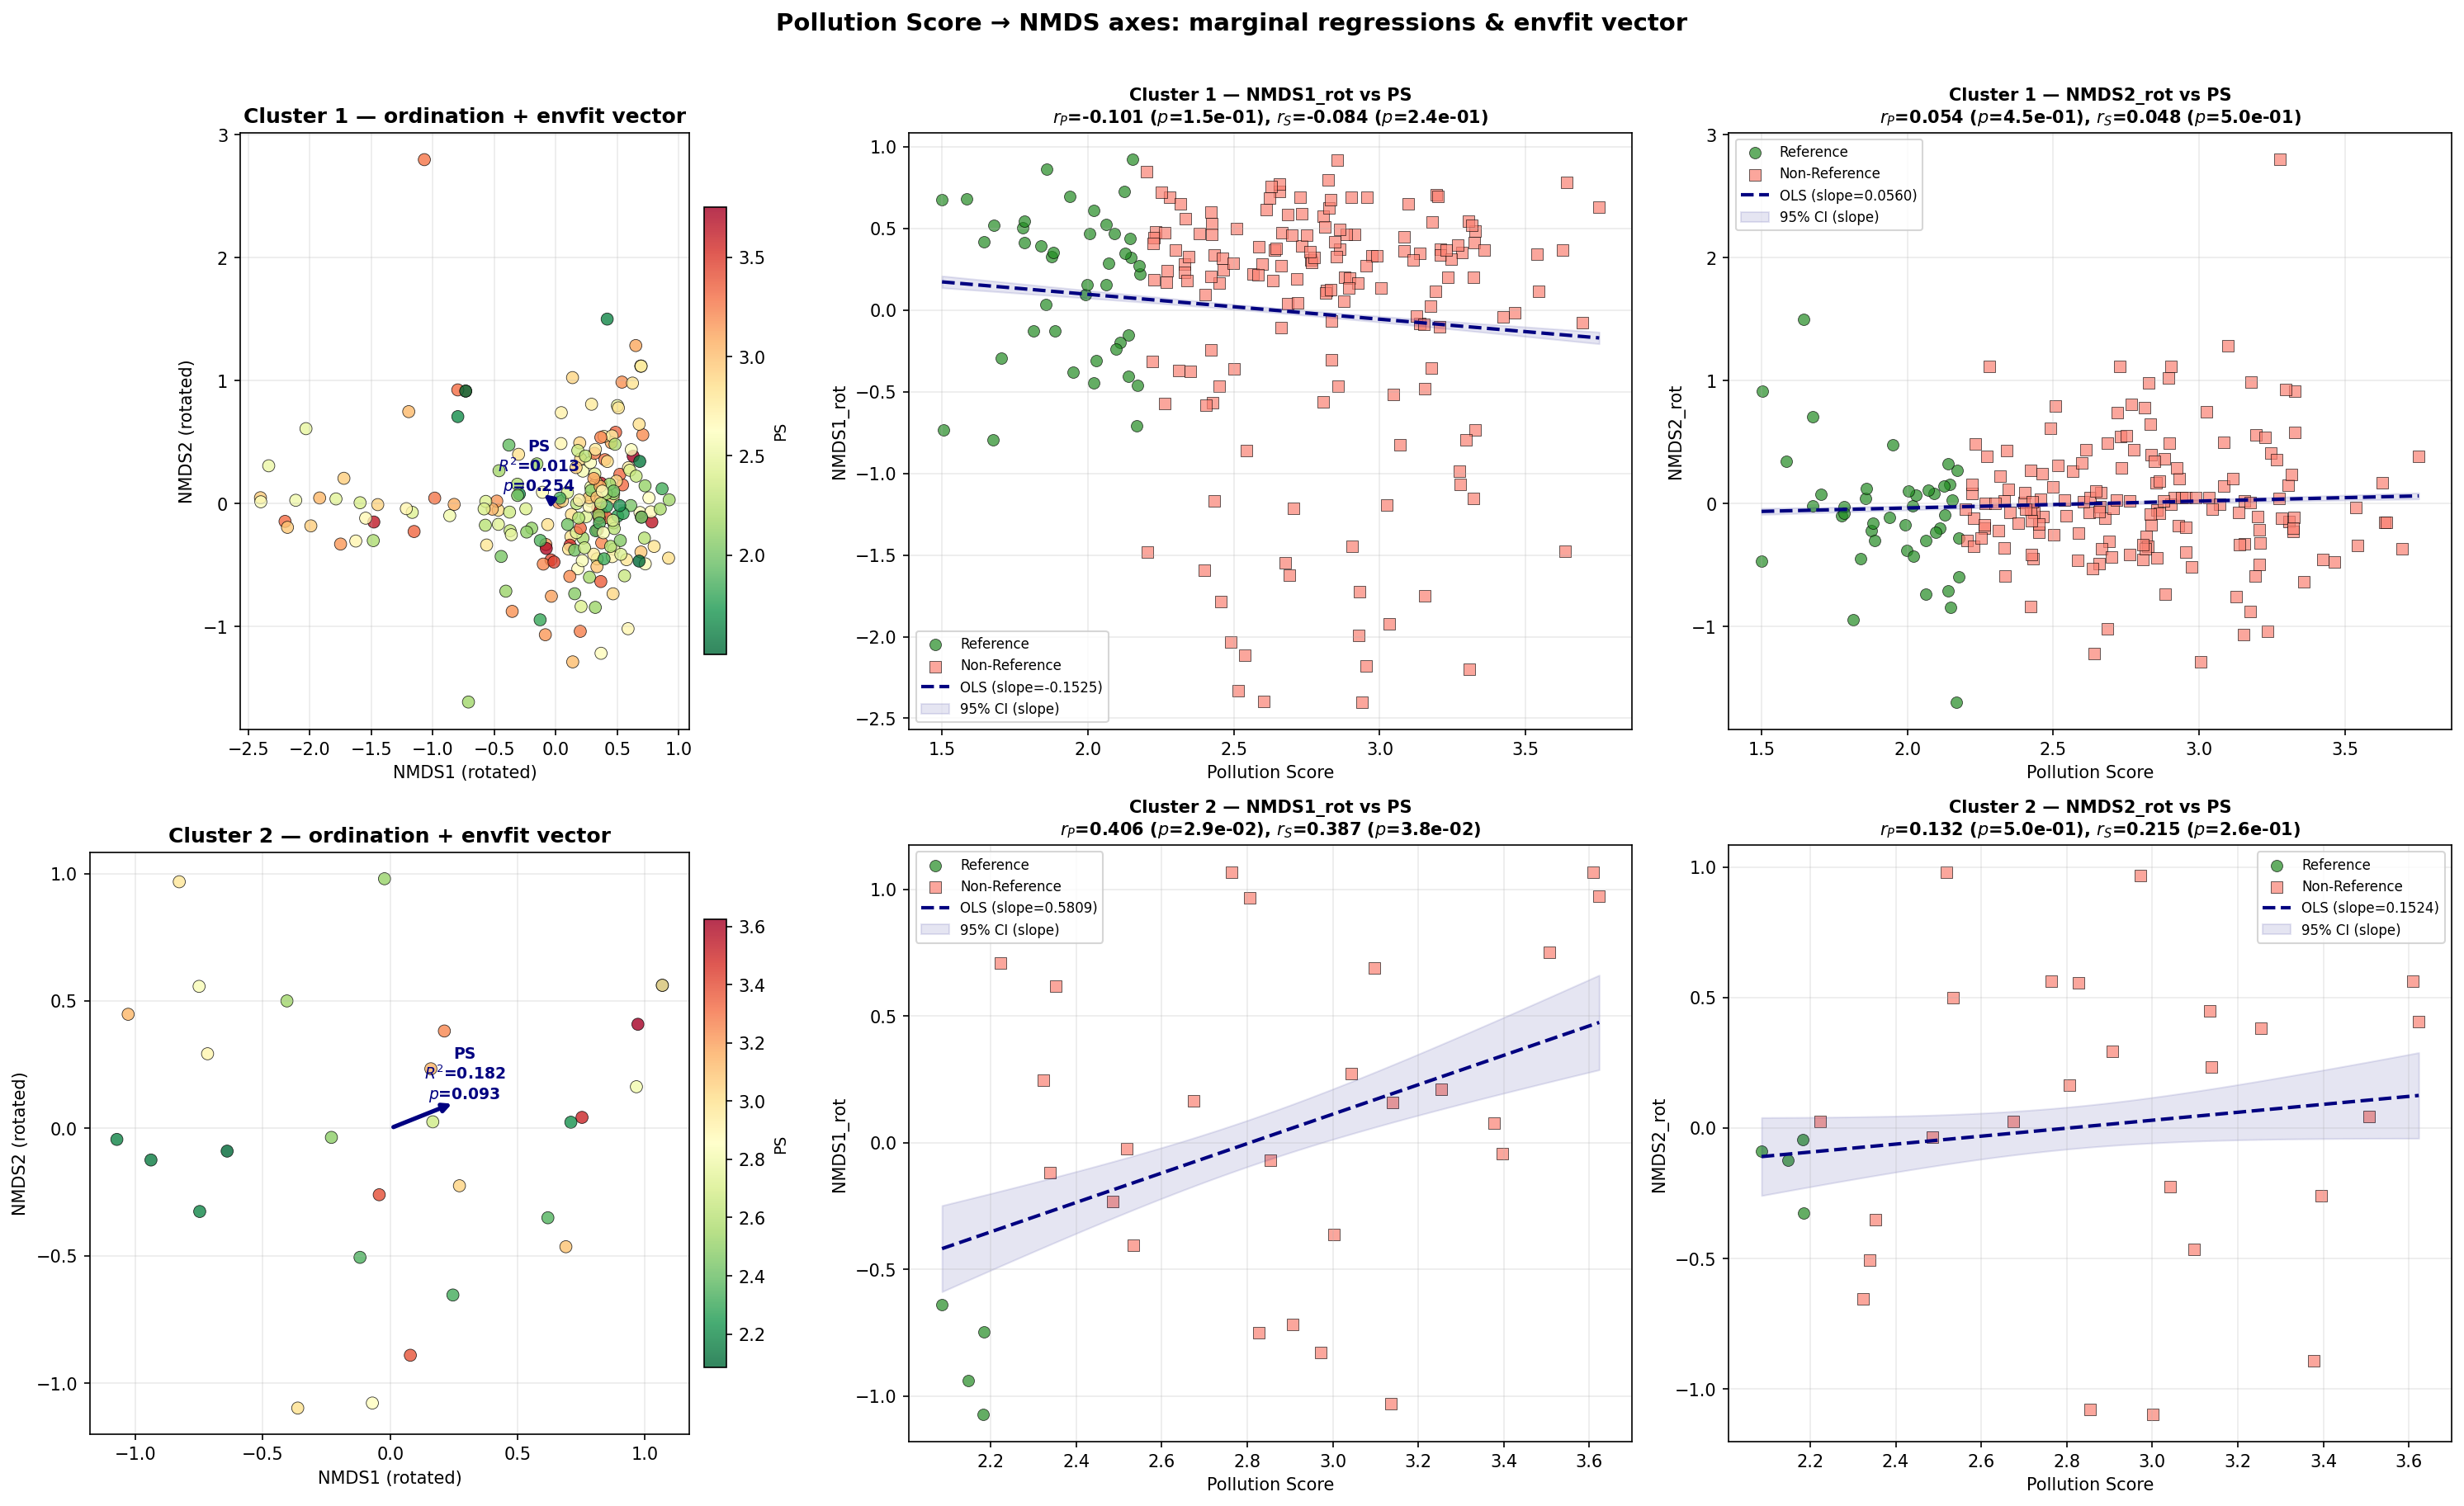


  Pollution Score → NMDS axes: regression & vector-fitting summary
 Cluster           Response   n Pearson r Pearson p Spearman ρ Spearman p OLS slope OLS intercept OLS R² OLS p(slope)
       1          NMDS1_rot 204   -0.1014  1.49e-01    -0.0835   2.35e-01  -0.15252       0.40201 0.0103     1.49e-01
       1          NMDS2_rot 204    0.0537  4.45e-01     0.0479   4.96e-01   0.05596      -0.14750 0.0029     4.45e-01
       1 envfit (both axes) 204         —         —          —          —         —             — 0.0132     2.54e-01
       2          NMDS1_rot  29    0.4062  2.88e-02     0.3867   3.82e-02   0.58092      -1.62990 0.1650     2.88e-02
       2          NMDS2_rot  29    0.1316  4.96e-01     0.2153   2.62e-01   0.15239      -0.42757 0.0173     4.96e-01
       2 envfit (both axes)  29         —         —          —          —         —             — 0.1823     9.30e-02

• envfit R² = proportion of PS variance explained by both NMDS axes jointly
• envfit p  = permutation p-v

In [96]:
# ── §15  Pollution Score → NMDS axes: visualisation + regression ──────────────
from scipy.stats import pearsonr, spearmanr, linregress

# ---------------------------------------------------------------------------
# Helper: envfit-style vector fitting with permutation test
# ---------------------------------------------------------------------------
def envfit_vector(coords_arr, env_vec, n_perm=999, rng_seed=42):
    """
    Project a continuous variable onto a 2-D ordination (like vegan::envfit).

    Returns
    -------
    r2      : float   – proportion of variance of `env_vec` explained by the
              linear combination of the ordination axes
    arrow   : (2,)    – direction cosines (unit-length arrow) pointing in the
              direction of steepest increase of `env_vec`
    p_perm  : float   – permutation p-value (proportion of permuted R² ≥ obs)
    """
    X = np.column_stack([np.ones(len(coords_arr)), coords_arr])  # intercept + 2 axes
    y = np.asarray(env_vec, dtype=float)
    # OLS:  y = X @ beta
    beta, _, _, _ = np.linalg.lstsq(X, y, rcond=None)
    y_hat = X @ beta
    ss_res = np.sum((y - y_hat) ** 2)
    ss_tot = np.sum((y - y.mean()) ** 2)
    r2 = 1 - ss_res / ss_tot if ss_tot > 0 else 0.0

    # direction arrow = normalised regression coefficients on the two axes
    coef = beta[1:]  # drop intercept
    norm = np.linalg.norm(coef)
    arrow = coef / norm if norm > 0 else coef

    # permutation test
    rng = np.random.default_rng(rng_seed)
    n_ge = 0
    for _ in range(n_perm):
        y_perm = rng.permutation(y)
        beta_p, _, _, _ = np.linalg.lstsq(X, y_perm, rcond=None)
        y_hat_p = X @ beta_p
        ss_res_p = np.sum((y_perm - y_hat_p) ** 2)
        r2_p = 1 - ss_res_p / ss_tot if ss_tot > 0 else 0.0
        if r2_p >= r2:
            n_ge += 1
    p_perm = (n_ge + 1) / (n_perm + 1)

    return r2, arrow, p_perm


# ══════════════════════════════════════════════════════════════════════════════
# Figure: per cluster — ordination + envfit arrow | NMDS1 vs PS | NMDS2 vs PS
# ══════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(n_clusters, 3, figsize=(20, 6 * n_clusters), dpi=150)
if n_clusters == 1:
    axes = axes.reshape(1, 3)

reg_rows = []  # collect results for summary table

for row_i, cl in enumerate(clusters):
    coords_df = nmds_rotated[cl]
    meta_cl   = site_meta.loc[coords_df.index]
    ps        = meta_cl["Pollution_Score"]
    ref_mask  = meta_cl["Is_Reference"] == 1

    x1 = coords_df["NMDS1_rot"].values
    x2 = coords_df["NMDS2_rot"].values

    # ── envfit ────────────────────────────────────────────────────────────
    r2_env, arrow, p_env = envfit_vector(
        np.column_stack([x1, x2]), ps.values, n_perm=999
    )

    # ── Column 0: 2-D ordination coloured by PS + envfit arrow ───────────
    ax = axes[row_i, 0]
    sc = ax.scatter(
        x1, x2, c=ps, cmap="RdYlGn_r", s=50,
        edgecolors="k", linewidths=0.4, alpha=0.8,
        vmin=ps.min(), vmax=ps.max(),
    )
    # envfit arrow — scale length to ~30 % of axis range
    x_range = x1.max() - x1.min()
    y_range = x2.max() - x2.min()
    scale = 0.30 * max(x_range, y_range) * np.sqrt(r2_env)
    cx, cy = x1.mean(), x2.mean()
    ax.annotate(
        "", xy=(cx + arrow[0] * scale, cy + arrow[1] * scale),
        xytext=(cx, cy),
        arrowprops=dict(arrowstyle="-|>", color="navy", lw=2.5),
    )
    ax.text(
        cx + arrow[0] * scale * 1.15,
        cy + arrow[1] * scale * 1.15,
        f"PS\n$R^2$={r2_env:.3f}\n$p$={p_env:.3f}",
        fontsize=9, fontweight="bold", color="navy", ha="center",
    )
    fig.colorbar(sc, ax=ax, shrink=0.75, pad=0.02).set_label("PS", fontsize=9)
    ax.set_xlabel("NMDS1 (rotated)")
    ax.set_ylabel("NMDS2 (rotated)")
    ax.set_title(f"Cluster {cl} — ordination + envfit vector", fontweight="bold")
    ax.set_aspect("equal")
    ax.grid(alpha=0.25)

    # ── Columns 1–2: marginal regressions ────────────────────────────────
    for col_j, (axis_vals, axis_lab) in enumerate(
        [(x1, "NMDS1_rot"), (x2, "NMDS2_rot")], start=1
    ):
        ax = axes[row_i, col_j]
        lr = linregress(ps.values, axis_vals)
        r_pear, p_pear = pearsonr(ps.values, axis_vals)
        r_spear, p_spear = spearmanr(ps.values, axis_vals)

        # scatter (ref / non-ref)
        ax.scatter(
            ps[ref_mask], axis_vals[ref_mask.values],
            c="forestgreen", marker="o", s=45, edgecolors="k",
            linewidths=0.4, alpha=0.7, label="Reference",
        )
        ax.scatter(
            ps[~ref_mask], axis_vals[(~ref_mask).values],
            c="salmon", marker="s", s=45, edgecolors="k",
            linewidths=0.4, alpha=0.7, label="Non-Reference",
        )
        # regression line + 95 % CI band
        xfit = np.linspace(ps.min(), ps.max(), 200)
        yfit = lr.slope * xfit + lr.intercept
        ax.plot(xfit, yfit, "--", color="navy", lw=2,
                label=f"OLS (slope={lr.slope:.4f})")
        # CI band (approximate: ±1.96 * stderr of prediction)
        n = len(ps)
        x_mean = ps.mean()
        se_pred = lr.stderr * np.sqrt(
            1 / n + (xfit - x_mean) ** 2 / np.sum((ps.values - x_mean) ** 2)
        )
        ax.fill_between(xfit, yfit - 1.96 * se_pred, yfit + 1.96 * se_pred,
                         color="navy", alpha=0.10, label="95% CI (slope)")

        ax.set_xlabel("Pollution Score")
        ax.set_ylabel(axis_lab)
        ax.set_title(
            f"Cluster {cl} — {axis_lab} vs PS\n"
            f"$r_P$={r_pear:.3f} ($p$={p_pear:.1e}), "
            f"$r_S$={r_spear:.3f} ($p$={p_spear:.1e})",
            fontweight="bold", fontsize=10,
        )
        ax.legend(fontsize=8, loc="best")
        ax.grid(alpha=0.25)

        # store for table
        reg_rows.append({
            "Cluster": cl,
            "Response": axis_lab,
            "n": n,
            "Pearson r": r_pear,
            "Pearson p": p_pear,
            "Spearman ρ": r_spear,
            "Spearman p": p_spear,
            "OLS slope": lr.slope,
            "OLS intercept": lr.intercept,
            "OLS R²": lr.rvalue ** 2,
            "OLS p(slope)": lr.pvalue,
        })

    # envfit row
    reg_rows.append({
        "Cluster": cl,
        "Response": "envfit (both axes)",
        "n": len(ps),
        "Pearson r": np.nan,
        "Pearson p": np.nan,
        "Spearman ρ": np.nan,
        "Spearman p": np.nan,
        "OLS slope": np.nan,
        "OLS intercept": np.nan,
        "OLS R²": r2_env,
        "OLS p(slope)": p_env,
    })

fig.suptitle(
    "Pollution Score → NMDS axes: marginal regressions & envfit vector",
    fontsize=14, fontweight="bold", y=1.01,
)
plt.tight_layout()
plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# Summary table
# ══════════════════════════════════════════════════════════════════════════════
reg_df = pd.DataFrame(reg_rows)

# nicer formatting
fmt_cols = {
    "Pearson r": "{:.4f}", "Pearson p": "{:.2e}",
    "Spearman ρ": "{:.4f}", "Spearman p": "{:.2e}",
    "OLS slope": "{:.5f}", "OLS intercept": "{:.5f}",
    "OLS R²": "{:.4f}", "OLS p(slope)": "{:.2e}",
}
styled = reg_df.copy()
for col, fmt in fmt_cols.items():
    styled[col] = styled[col].apply(
        lambda v, f=fmt: f.format(v) if pd.notna(v) else "—"
    )

print("\n" + "=" * 120)
print("  Pollution Score → NMDS axes: regression & vector-fitting summary")
print("=" * 120)
print(styled.to_string(index=False))
print("=" * 120)
print("\n• envfit R² = proportion of PS variance explained by both NMDS axes jointly")

print("• envfit p  = permutation p-value (999 permutations)")
print("• Significance codes: p < 0.001 '***', p < 0.01 '**', p < 0.05 '*'")

## 16 · PCoA-based ZCI: a principled 1-D community summary

The endpoint-based ZCI (§14) collapsed 2-D NMDS into one number by measuring
distances to two synthetic "reference" and "degraded" centroids.  That approach
is geometrically arbitrary — the resulting scalar depends on the angle between
the ref–deg axis and the dominant ordination gradient.

**PCoA axis 1** offers a better alternative:

| Property | Endpoint ZCI | PCoA axis 1 |
|----------|-------------|-------------|
| Basis | arbitrary ref/deg line | eigenvector of the BC distance matrix |
| Optimality | none | maximises variance explained of all pairwise BC distances |
| Requires endpoint selection | yes (tuning *N*) | no |
| Interpretable direction | "closer to ref = better" | sign arbitrary — flip so ↑ = better condition |

**Procedure per cluster**

1. Bray–Curtis distance matrix → PCoA (classical metric MDS with eigenvalues).
2. Extract **Axis 1** score for each site = **PCoA-ZCI**.
3. Optionally rescale to [0, 1] so it reads like an index.
4. Correlate with Pollution Score; fit OLS + report significance.

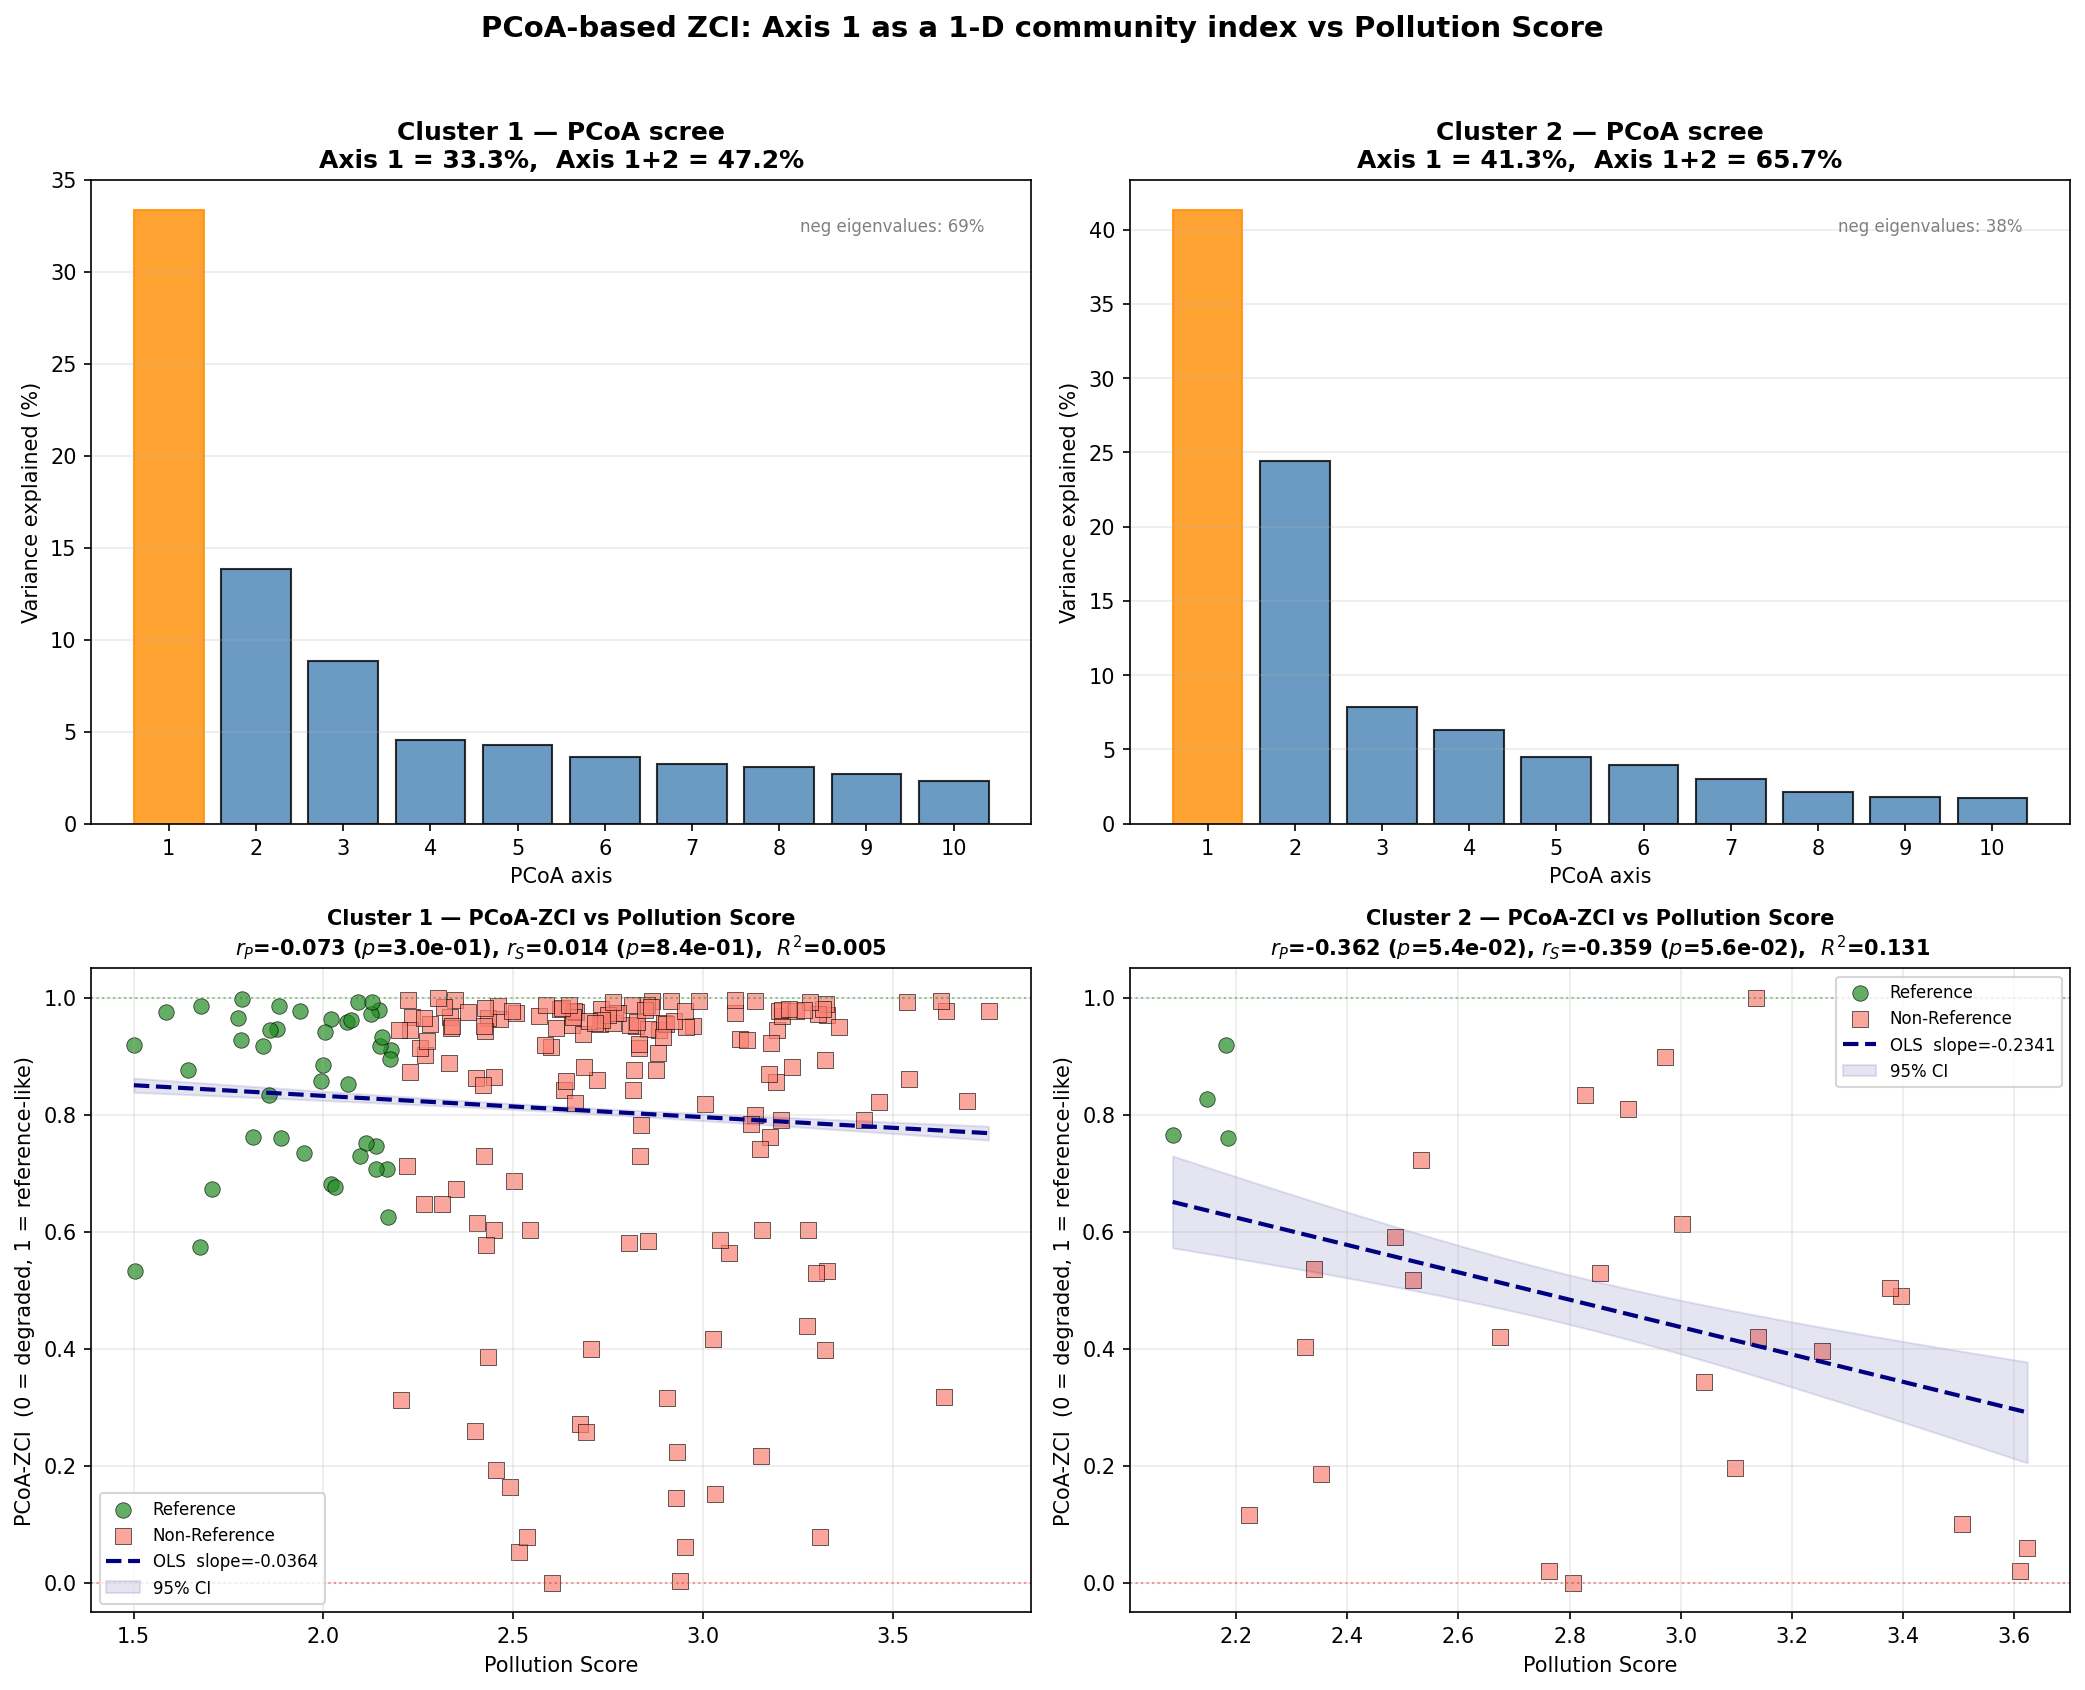


  Comparison: 1-D ZCI methods & 2-D envfit — correlation with Pollution Score
 Cluster                 Method Pearson r Pearson p Spearman ρ Spearman p R² (multivariate) p (perm)
       1     Endpoint ZCI (§14)    0.0673  3.39e-01     0.1202   8.67e-02                 —        —
       1 PCoA-ZCI (§16, Axis 1)   -0.0732  2.98e-01     0.0138   8.45e-01                 —        —
       1  NMDS 2-D envfit (§15)         —         —          —          —            0.0132    0.254
       2     Endpoint ZCI (§14)   -0.4275  2.07e-02    -0.3926   3.51e-02                 —        —
       2 PCoA-ZCI (§16, Axis 1)   -0.3617  5.38e-02    -0.3589   5.59e-02                 —        —
       2  NMDS 2-D envfit (§15)         —         —          —          —            0.1823    0.093

  PCoA-ZCI (Axis 1) regression detail
 Cluster            Metric Var explained by Axis 1 (%)   n Pearson r Pearson p Spearman ρ Spearman p OLS slope OLS R² OLS p(slope)
       1 PCoA-ZCI (Axis 1)                  

In [97]:
# ── §16  PCoA-based ZCI ───────────────────────────────────────────────────────
from scipy.stats import pearsonr, spearmanr, linregress

def pcoa_from_bc(taxa_df):
    """
    Classical PCoA on a Bray–Curtis distance matrix.

    Returns
    -------
    eigvals  : 1-D array of eigenvalues (descending)
    coords   : DataFrame (sites × k) of principal coordinate scores
               (only positive-eigenvalue axes)
    var_exp  : 1-D array of proportion variance explained per axis
    """
    bc = squareform(pdist(taxa_df.values, metric="braycurtis"))
    n = len(bc)
    # double-centre
    H = np.eye(n) - np.ones((n, n)) / n
    B = -0.5 * H @ (bc ** 2) @ H

    eigvals, eigvecs = np.linalg.eigh(B)
    # sort descending
    order = np.argsort(eigvals)[::-1]
    eigvals = eigvals[order]
    eigvecs = eigvecs[:, order]

    # keep positive eigenvalues only
    pos = eigvals > 1e-12
    eigvals = eigvals[pos]
    eigvecs = eigvecs[:, pos]

    # coordinates = eigvecs * sqrt(eigvals)
    coords_arr = eigvecs * np.sqrt(eigvals)
    cols = [f"PCoA{i+1}" for i in range(coords_arr.shape[1])]
    coords_df = pd.DataFrame(coords_arr, index=taxa_df.index, columns=cols)

    var_exp = eigvals / eigvals.sum()
    return eigvals, coords_df, var_exp


# ══════════════════════════════════════════════════════════════════════════════
# Run PCoA per cluster, extract axis 1 as PCoA-ZCI, correlate with PS
# ══════════════════════════════════════════════════════════════════════════════
pcoa_results = {}   # cl -> (eigvals, coords_df, var_exp)
pcoa_zci     = {}   # cl -> Series (PCoA-ZCI, [0-1]-rescaled, higher = better condition)

fig, axes = plt.subplots(2, n_clusters, figsize=(7 * n_clusters, 11), dpi=150)
if n_clusters == 1:
    axes = axes.reshape(2, 1)

reg_rows_pcoa = []

for col_i, cl in enumerate(clusters):
    cl_sites = site_meta.index[site_meta["Cluster"] == cl]
    taxa_cl  = taxa.loc[cl_sites]
    meta_cl  = site_meta.loc[cl_sites]
    ps       = meta_cl["Pollution_Score"]
    ref_mask = meta_cl["Is_Reference"] == 1

    # ── PCoA ──────────────────────────────────────────────────────────────
    eigvals, coords_df, var_exp = pcoa_from_bc(taxa_cl)
    pcoa_results[cl] = (eigvals, coords_df, var_exp)

    ax1_raw = coords_df["PCoA1"].values

    # Flip sign so that *higher* PCoA-ZCI = better condition (lower PS).
    # Convention: if correlation with PS is positive, flip.
    if np.corrcoef(ax1_raw, ps.values)[0, 1] > 0:
        ax1_raw = -ax1_raw

    # Rescale to [0, 1]
    zci_01 = (ax1_raw - ax1_raw.min()) / (ax1_raw.max() - ax1_raw.min() + 1e-15)
    pcoa_zci[cl] = pd.Series(zci_01, index=cl_sites, name="PCoA_ZCI")

    # ── Row 0: scree — first 10 axes ─────────────────────────────────────
    ax = axes[0, col_i]
    k_show = min(10, len(var_exp))
    bars = ax.bar(range(1, k_show + 1), var_exp[:k_show] * 100,
                  color="steelblue", edgecolor="k", alpha=0.8)
    bars[0].set_color("darkorange")   # highlight axis 1
    ax.set_xlabel("PCoA axis")
    ax.set_ylabel("Variance explained (%)")
    ax.set_title(
        f"Cluster {cl} — PCoA scree\n"
        f"Axis 1 = {var_exp[0]*100:.1f}%,  "
        f"Axis 1+2 = {(var_exp[0]+var_exp[1])*100:.1f}%",
        fontweight="bold",
    )
    ax.set_xticks(range(1, k_show + 1))
    ax.grid(axis="y", alpha=0.25)

    # annotate negative eigenvalue fraction
    all_eigs = np.linalg.eigvalsh(
        -0.5 * (np.eye(len(taxa_cl)) - np.ones((len(taxa_cl), len(taxa_cl))) / len(taxa_cl))
        @ (squareform(pdist(taxa_cl.values, metric="braycurtis")) ** 2)
        @ (np.eye(len(taxa_cl)) - np.ones((len(taxa_cl), len(taxa_cl))) / len(taxa_cl))
    )
    neg_frac = (all_eigs < -1e-12).sum() / len(all_eigs) * 100
    ax.text(0.95, 0.92, f"neg eigenvalues: {neg_frac:.0f}%",
            transform=ax.transAxes, ha="right", fontsize=8, color="gray")

    # ── Row 1: PCoA-ZCI vs Pollution Score ────────────────────────────────
    ax = axes[1, col_i]
    zci_s = pcoa_zci[cl]
    lr = linregress(ps.values, zci_s.values)
    r_pear, p_pear = pearsonr(ps.values, zci_s.values)
    r_spear, p_spear = spearmanr(ps.values, zci_s.values)

    ax.scatter(
        ps[ref_mask], zci_s[ref_mask.index[ref_mask]],
        c="forestgreen", marker="o", s=55, edgecolors="k",
        linewidths=0.4, alpha=0.7, label="Reference",
    )
    ax.scatter(
        ps[~ref_mask], zci_s[ref_mask.index[~ref_mask]],
        c="salmon", marker="s", s=55, edgecolors="k",
        linewidths=0.4, alpha=0.7, label="Non-Reference",
    )
    # regression line + CI
    xfit = np.linspace(ps.min(), ps.max(), 200)
    yfit = lr.slope * xfit + lr.intercept
    ax.plot(xfit, yfit, "--", color="navy", lw=2,
            label=f"OLS  slope={lr.slope:.4f}")
    n_pts = len(ps)
    x_mean = ps.mean()
    se_pred = lr.stderr * np.sqrt(
        1 / n_pts + (xfit - x_mean) ** 2 / np.sum((ps.values - x_mean) ** 2)
    )
    ax.fill_between(xfit, yfit - 1.96 * se_pred, yfit + 1.96 * se_pred,
                     color="navy", alpha=0.10, label="95% CI")

    sig_star = ""
    if p_pear < 0.001: sig_star = "***"
    elif p_pear < 0.01: sig_star = "**"
    elif p_pear < 0.05: sig_star = "*"

    ax.set_xlabel("Pollution Score")
    ax.set_ylabel("PCoA-ZCI  (0 = degraded, 1 = reference-like)")
    ax.set_title(
        f"Cluster {cl} — PCoA-ZCI vs Pollution Score\n"
        f"$r_P$={r_pear:.3f}{sig_star} ($p$={p_pear:.1e}), "
        f"$r_S$={r_spear:.3f} ($p$={p_spear:.1e}),  "
        f"$R^2$={lr.rvalue**2:.3f}",
        fontweight="bold", fontsize=10,
    )
    ax.axhline(0, color="red",   ls=":", lw=1, alpha=0.4)
    ax.axhline(1, color="green", ls=":", lw=1, alpha=0.4)
    ax.legend(fontsize=8, loc="best")
    ax.grid(alpha=0.25)

    reg_rows_pcoa.append({
        "Cluster": cl,
        "Metric": "PCoA-ZCI (Axis 1)",
        "Var explained by Axis 1 (%)": round(var_exp[0] * 100, 2),
        "n": n_pts,
        "Pearson r": r_pear,
        "Pearson p": p_pear,
        "Spearman ρ": r_spear,
        "Spearman p": p_spear,
        "OLS slope": lr.slope,
        "OLS R²": lr.rvalue ** 2,
        "OLS p(slope)": lr.pvalue,
    })

fig.suptitle(
    "PCoA-based ZCI: Axis 1 as a 1-D community index vs Pollution Score",
    fontsize=14, fontweight="bold", y=1.02,
)
plt.tight_layout()
plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# Comparison table:  endpoint-ZCI  vs  PCoA-ZCI  vs  NMDS envfit
# ══════════════════════════════════════════════════════════════════════════════

# Also compute endpoint ZCI correlation for comparison
comp_rows = []
for cl in clusters:
    ps_cl = site_meta.loc[site_meta["Cluster"] == cl, "Pollution_Score"]

    # ─ endpoint ZCI (from §14) ─
    zci_ep = zci_all[cl]
    r_ep, p_ep = pearsonr(ps_cl.loc[zci_ep.index], zci_ep)
    rs_ep, ps_ep = spearmanr(ps_cl.loc[zci_ep.index], zci_ep)
    comp_rows.append({
        "Cluster": cl, "Method": "Endpoint ZCI (§14)",
        "Pearson r": r_ep, "Pearson p": p_ep,
        "Spearman ρ": rs_ep, "Spearman p": ps_ep,
    })

    # ─ PCoA-ZCI ─
    zci_pc = pcoa_zci[cl]
    r_pc, p_pc = pearsonr(ps_cl.loc[zci_pc.index], zci_pc)
    rs_pc, ps_pc = spearmanr(ps_cl.loc[zci_pc.index], zci_pc)
    comp_rows.append({
        "Cluster": cl, "Method": "PCoA-ZCI (§16, Axis 1)",
        "Pearson r": r_pc, "Pearson p": p_pc,
        "Spearman ρ": rs_pc, "Spearman p": ps_pc,
    })

    # ─ NMDS envfit R² (from §15) ─
    # look up from reg_df
    envfit_match = reg_df[
        (reg_df["Cluster"] == cl) & (reg_df["Response"] == "envfit (both axes)")
    ]
    if len(envfit_match) > 0:
        envfit_row = envfit_match.iloc[0]
        comp_rows.append({
            "Cluster": cl, "Method": "NMDS 2-D envfit (§15)",
            "Pearson r": np.nan,
            "Pearson p": np.nan,
            "Spearman ρ": np.nan,
            "Spearman p": np.nan,
            "R² (multivariate)": envfit_row["OLS R²"],
            "p (perm)": envfit_row["OLS p(slope)"],
        })

comp_df = pd.DataFrame(comp_rows)
fmt_map = {
    "Pearson r": "{:.4f}", "Pearson p": "{:.2e}",
    "Spearman ρ": "{:.4f}", "Spearman p": "{:.2e}",
    "R² (multivariate)": "{:.4f}", "p (perm)": "{:.3f}",
}
comp_styled = comp_df.copy()
for col_name, fmt in fmt_map.items():
    if col_name in comp_styled.columns:
        comp_styled[col_name] = comp_styled[col_name].apply(
            lambda v, f=fmt: f.format(v) if pd.notna(v) else "—"
        )

print("\n" + "=" * 110)
print("  Comparison: 1-D ZCI methods & 2-D envfit — correlation with Pollution Score")
print("=" * 110)
print(comp_styled.to_string(index=False))
print("=" * 110)

# ── PCoA-ZCI regression detail table ──────────────────────────────────────────
pcoa_reg_df = pd.DataFrame(reg_rows_pcoa)
fmt2 = {
    "Var explained by Axis 1 (%)": "{:.2f}",
    "Pearson r": "{:.4f}", "Pearson p": "{:.2e}",
    "Spearman ρ": "{:.4f}", "Spearman p": "{:.2e}",
    "OLS slope": "{:.5f}", "OLS R²": "{:.4f}", "OLS p(slope)": "{:.2e}",
}
pcoa_styled = pcoa_reg_df.copy()
for col_name, fmt in fmt2.items():
    pcoa_styled[col_name] = pcoa_styled[col_name].apply(
        lambda v, f=fmt: f.format(v) if pd.notna(v) else "—"
    )

print("\n" + "=" * 110)
print("  PCoA-ZCI (Axis 1) regression detail")
print("=" * 110)

print(pcoa_styled.to_string(index=False))
print("=" * 110)

## 17 · NMDS on Relative-Abundance Scale (per cluster, with endpoints)

All ordinations above used the **octave-transformed** taxa matrix.  Here we:

1. Back-transform to **relative abundances** via `octave_to_relative_abundance`.
2. Construct hypothetical **reference / degraded endpoints** per cluster
   (same 5-site averaging as §14), convert them to relative abundance,
   augment the taxa matrix, and run 2-D NMDS with Bray–Curtis.
3. Plot the NMDS biplot (colour = PS, shape = Waterbody, red text = species).
4. **ZCI Method 1** — distance-based: $\text{ZCI}_i = d_{i,\text{deg}} / (d_{i,\text{ref}} + d_{i,\text{deg}})$.
5. **ZCI Method 2** — per-axis regression: NMDS1 ~ PS and NMDS2 ~ PS + envfit.

Relative-abundance matrix: (233, 16)
Row sums (should ≈ 1): min=1.0000, max=1.0000

Cluster 1: augmented RA taxa = (206, 16) (+REF '_REF_EP_RA_1', +DEG '_DEG_EP_RA_1')
  REF sites: ['S38', '075A', 'S65', 'S53', 'S54'], mean PS = 1.582
  DEG sites: ['088C', '007ABC', '081B', '089A', '101C'], mean PS = 3.670


/Users/gufeng/2025_Winter/Thesis_Project/ThesisProject/envThesisProject/lib/python3.13/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/Users/gufeng/2025_Winter/Thesis_Project/ThesisProject/envThesisProject/lib/python3.13/site-packages/sklearn/manifold/_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(
/Users/gufeng/2025_Winter/Thesis_Project/ThesisProject/envThesisProject/lib/python3.13/site-packages/sklearn/manifold/_mds.py:779: FutureWarning: Use metric_mds=False instead of metric=False. The support for metric={True/False} will be dropped in 1.10.
  warnings.warn(


  stress = 0.15914

Cluster 2: augmented RA taxa = (31, 16) (+REF '_REF_EP_RA_2', +DEG '_DEG_EP_RA_2')
  REF sites: ['S17', 'A5', 'S19', 'S12', 'S99'], mean PS = 2.165
  DEG sites: ['091C', '074B', '147A', '052B', '076ABC'], mean PS = 3.502


/Users/gufeng/2025_Winter/Thesis_Project/ThesisProject/envThesisProject/lib/python3.13/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/Users/gufeng/2025_Winter/Thesis_Project/ThesisProject/envThesisProject/lib/python3.13/site-packages/sklearn/manifold/_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(
/Users/gufeng/2025_Winter/Thesis_Project/ThesisProject/envThesisProject/lib/python3.13/site-packages/sklearn/manifold/_mds.py:779: FutureWarning: Use metric_mds=False instead of metric=False. The support for metric={True/False} will be dropped in 1.10.
  warnings.warn(


  stress = 0.11429


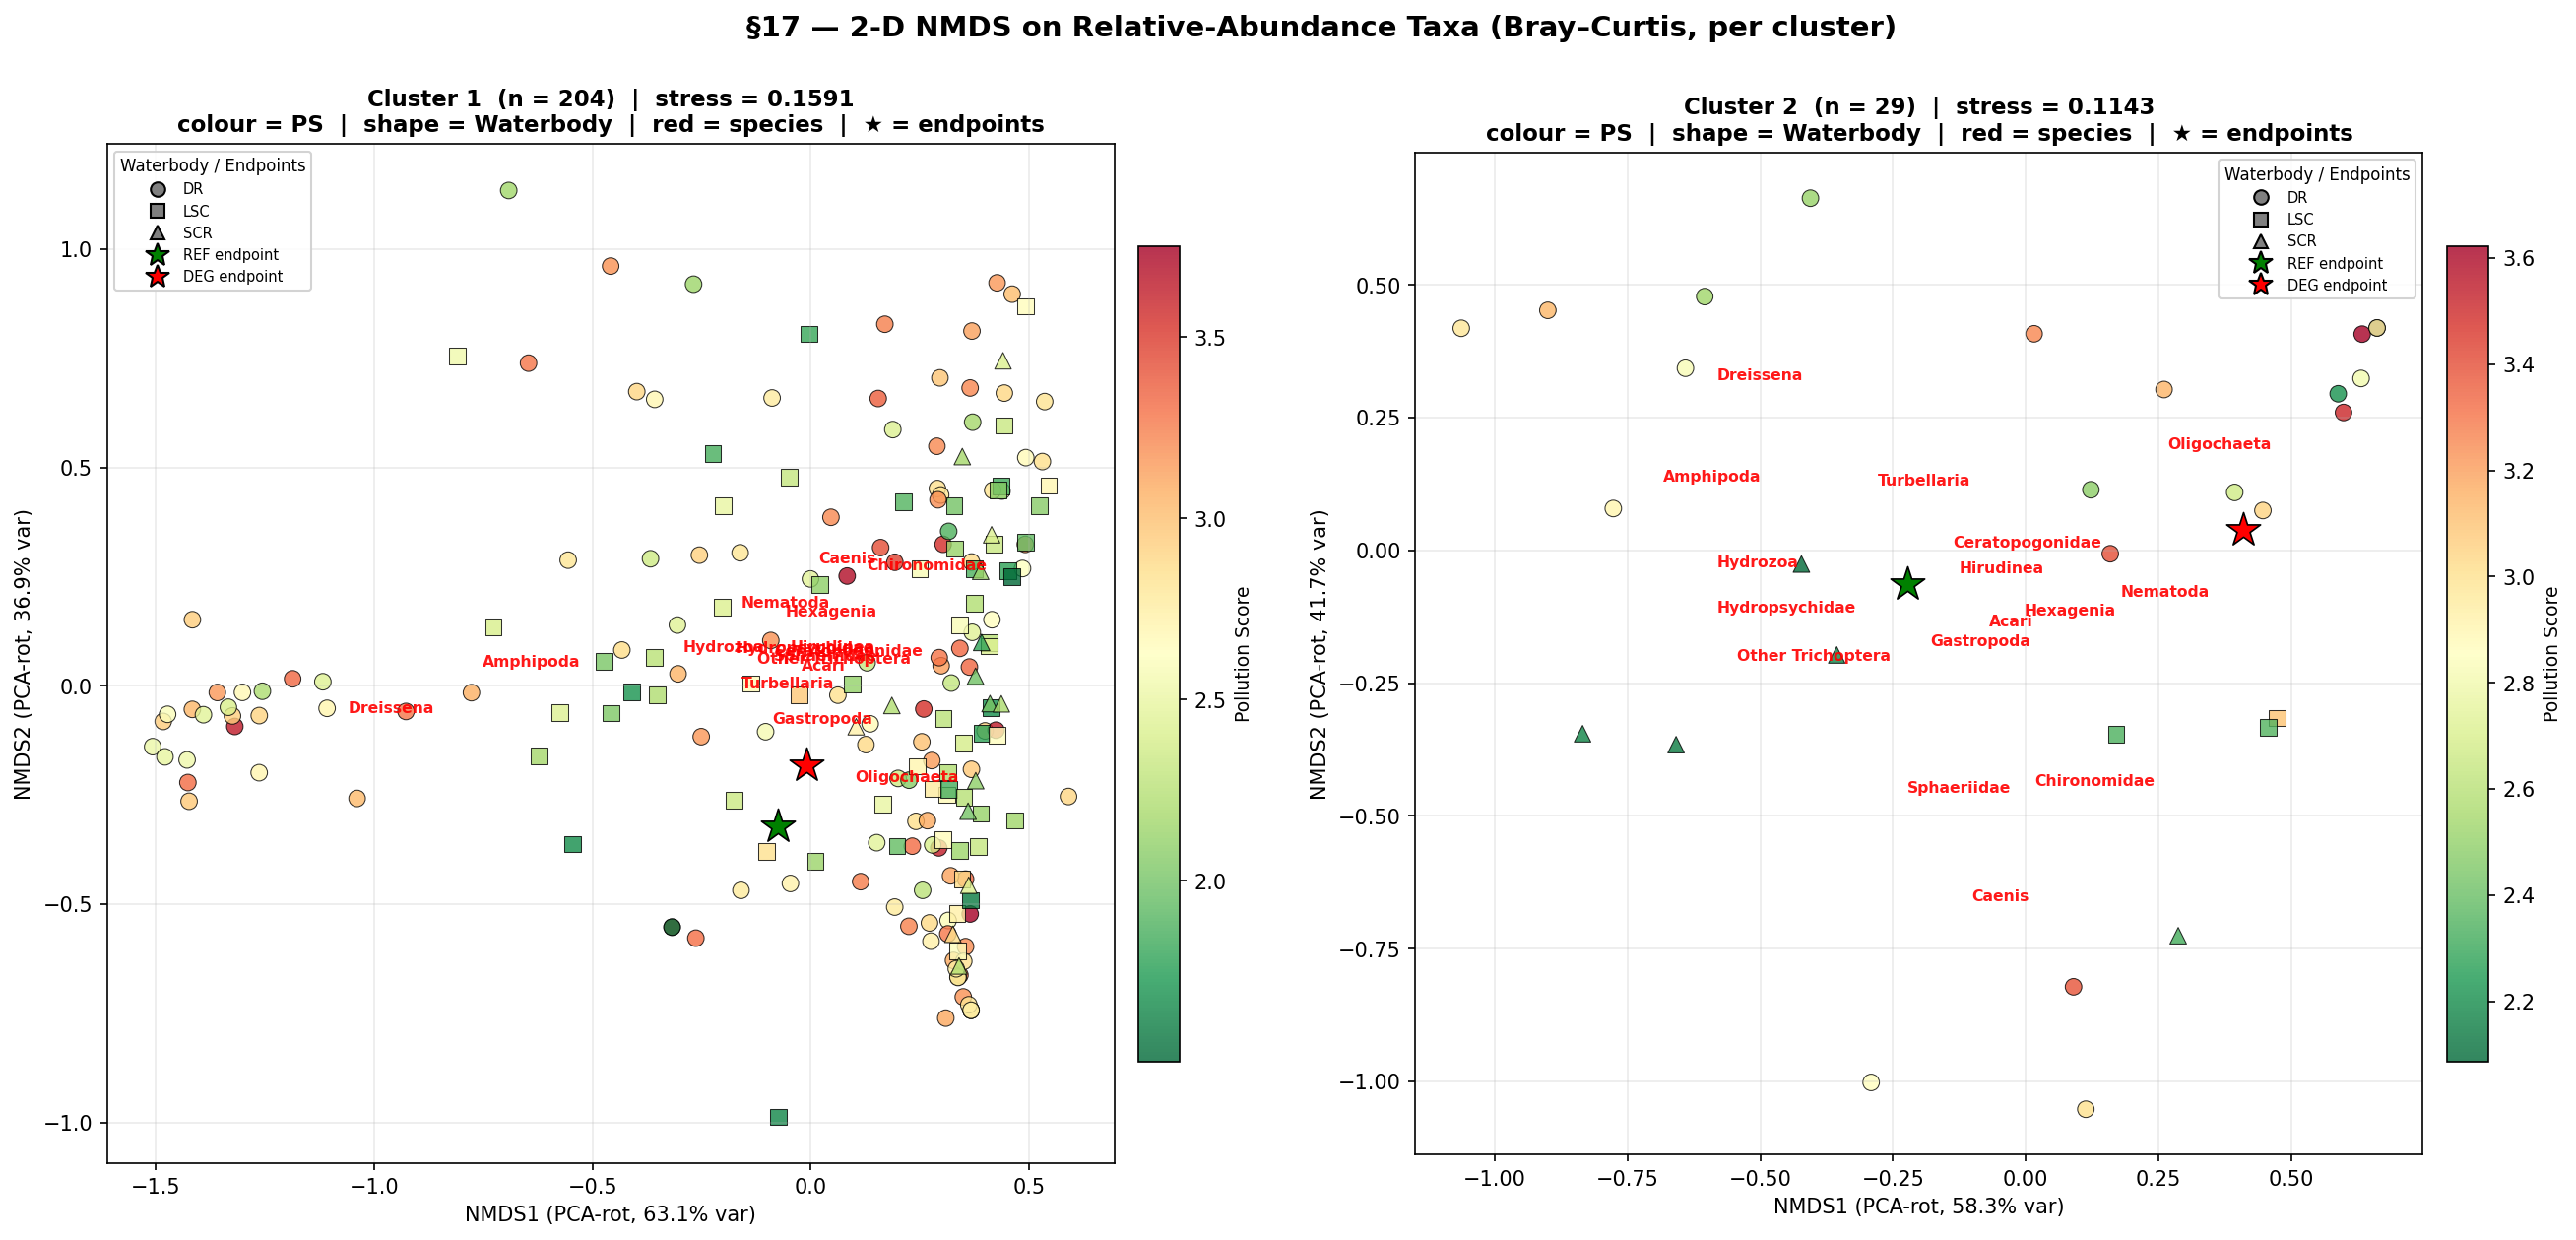

In [101]:
# ── §17  NMDS on relative-abundance taxa (per cluster, with endpoints) ────────
from zci.core.transforms import octave_to_relative_abundance
from sklearn.decomposition import PCA as _PCA
from scipy.stats import pearsonr, spearmanr, linregress

try:
    from adjustText import adjust_text as _adj
except ModuleNotFoundError:
    _adj = None

# 1. Convert octave → relative abundance (all sites) ─────────────────────────
taxa_relabd = octave_to_relative_abundance(taxa)
print(f"Relative-abundance matrix: {taxa_relabd.shape}")
print(f"Row sums (should ≈ 1): min={taxa_relabd.sum(1).min():.4f}, "
      f"max={taxa_relabd.sum(1).max():.4f}")

# Waterbody markers
wb_markers_pool = ["o", "s", "^", "D", "P", "X", "v", "<", ">", "h"]
wb_marker_map = {wb: wb_markers_pool[i % len(wb_markers_pool)]
                 for i, wb in enumerate(sorted(waterbody.unique()))}

# 2. Per-cluster: build endpoints, augment, NMDS ─────────────────────────────
N_EP = 5

nmds_ra_ep = {}   # cl -> dict(coords_df, stress, wa_df, ref_label, deg_label)

fig, axes_ra = plt.subplots(1, n_clusters, figsize=(9 * n_clusters, 8), dpi=150)
if n_clusters == 1:
    axes_ra = [axes_ra]

for ax, cl in zip(axes_ra, clusters):
    cl_sites = site_meta.index[site_meta["Cluster"] == cl]
    meta_cl  = site_meta.loc[cl_sites]
    taxa_cl_ra = taxa_relabd.loc[cl_sites]

    # ── Build endpoints (in relative-abundance space) ─────────────────────
    ps_sorted = meta_cl["Pollution_Score"].sort_values()
    ref_ids = ps_sorted.index[:N_EP]
    deg_ids = ps_sorted.index[-N_EP:]
    ref_taxa_ra = taxa_cl_ra.loc[ref_ids].mean(axis=0)
    deg_taxa_ra = taxa_cl_ra.loc[deg_ids].mean(axis=0)

    ref_label = f"_REF_EP_RA_{cl}"
    deg_label = f"_DEG_EP_RA_{cl}"

    # Augment
    taxa_aug_ra = pd.concat([
        taxa_cl_ra,
        pd.DataFrame([ref_taxa_ra], index=[ref_label], columns=TAXA_COLUMNS),
        pd.DataFrame([deg_taxa_ra], index=[deg_label], columns=TAXA_COLUMNS),
    ])

    print(f"\nCluster {cl}: augmented RA taxa = {taxa_aug_ra.shape} "
          f"(+REF '{ref_label}', +DEG '{deg_label}')")
    print(f"  REF sites: {ref_ids.tolist()}, mean PS = "
          f"{meta_cl.loc[ref_ids, 'Pollution_Score'].mean():.3f}")
    print(f"  DEG sites: {deg_ids.tolist()}, mean PS = "
          f"{meta_cl.loc[deg_ids, 'Pollution_Score'].mean():.3f}")

    # Bray-Curtis on augmented matrix
    bc_aug = squareform(pdist(taxa_aug_ra.values, metric="braycurtis"))

    # 2-D NMDS
    nmds_cl = MDS(
        n_components=2,
        metric=False,
        dissimilarity="precomputed",
        max_iter=1000,
        n_init=10,
        random_state=42,
        normalized_stress="auto",
    )
    coords_aug = nmds_cl.fit_transform(bc_aug)
    stress_cl = nmds_cl.stress_

    # PCA-rotate
    pca_cl = _PCA(n_components=2).fit(coords_aug)
    coords_aug = pca_cl.transform(coords_aug)
    var_exp_cl = pca_cl.explained_variance_ratio_

    coords_aug_df = pd.DataFrame(coords_aug, index=taxa_aug_ra.index,
                                 columns=["NMDS1", "NMDS2"])

    # WA species scores (on real sites only)
    real_sites = [s for s in coords_aug_df.index
                  if s not in (ref_label, deg_label)]
    abund_real = taxa_cl_ra.loc[real_sites].values
    site_coords_real = coords_aug_df.loc[real_sites].values
    col_sums_cl = abund_real.sum(axis=0)
    col_sums_cl[col_sums_cl == 0] = 1e-12
    wa_cl = (abund_real.T @ site_coords_real) / col_sums_cl[:, None]
    wa_cl_df = pd.DataFrame(wa_cl, index=TAXA_COLUMNS, columns=["WA1", "WA2"])

    nmds_ra_ep[cl] = {
        "coords_df": coords_aug_df,
        "stress": stress_cl,
        "wa_df": wa_cl_df,
        "ref_label": ref_label,
        "deg_label": deg_label,
        "var_exp": var_exp_cl,
    }

    print(f"  stress = {stress_cl:.5f}")

    # ── Plot biplot ───────────────────────────────────────────────────────
    coords_real = coords_aug_df.loc[real_sites]
    ps_cl = meta_cl.loc[real_sites, "Pollution_Score"]
    wb_cl = waterbody.loc[real_sites]
    vmin_cl, vmax_cl = ps_cl.min(), ps_cl.max()

    for wb_name in sorted(wb_cl.unique()):
        mask_wb = wb_cl == wb_name
        idx_wb = mask_wb.index[mask_wb]
        sc = ax.scatter(
            coords_real.loc[idx_wb, "NMDS1"],
            coords_real.loc[idx_wb, "NMDS2"],
            c=ps_cl.loc[idx_wb],
            cmap="RdYlGn_r",
            marker=wb_marker_map[wb_name],
            s=65,
            edgecolors="k",
            linewidths=0.5,
            alpha=0.8,
            vmin=vmin_cl,
            vmax=vmax_cl,
            label=wb_name,
        )

    # endpoints as stars
    ax.scatter(*coords_aug_df.loc[ref_label], marker="*", s=300,
               c="green", edgecolors="k", linewidths=0.8, zorder=5,
               label="REF endpoint")
    ax.scatter(*coords_aug_df.loc[deg_label], marker="*", s=300,
               c="red", edgecolors="k", linewidths=0.8, zorder=5,
               label="DEG endpoint")

    cb = fig.colorbar(sc, ax=ax, shrink=0.75, pad=0.02)
    cb.set_label("Pollution Score", fontsize=9)

    # species text in red
    texts_cl = []
    for taxon in TAXA_COLUMNS:
        t = ax.text(wa_cl_df.loc[taxon, "WA1"], wa_cl_df.loc[taxon, "WA2"],
                    taxon, fontsize=7.5, fontweight="bold", color="red",
                    alpha=0.9, ha="center", va="bottom")
        texts_cl.append(t)
    if _adj is not None:
        try:
            _adj(texts_cl, ax=ax,
                 arrowprops=dict(arrowstyle="-", color="red", lw=0.4, alpha=0.5))
        except Exception:
            pass

    # legend
    legend_handles_wb = [
        Line2D([0], [0], marker=wb_marker_map[w], color="w",
               markerfacecolor="gray", markeredgecolor="k", markersize=7,
               label=w)
        for w in sorted(wb_cl.unique())
    ]
    legend_handles_wb += [
        Line2D([0], [0], marker="*", color="w", markerfacecolor="green",
               markeredgecolor="k", markersize=12, label="REF endpoint"),
        Line2D([0], [0], marker="*", color="w", markerfacecolor="red",
               markeredgecolor="k", markersize=12, label="DEG endpoint"),
    ]
    ax.legend(handles=legend_handles_wb, loc="best", fontsize=7,
              framealpha=0.85, title="Waterbody / Endpoints", title_fontsize=8)

    ax.set_xlabel(f"NMDS1 (PCA-rot, {var_exp_cl[0]:.1%} var)", fontsize=10)
    ax.set_ylabel(f"NMDS2 (PCA-rot, {var_exp_cl[1]:.1%} var)", fontsize=10)
    ax.set_title(
        f"Cluster {cl}  (n = {len(cl_sites)})  |  stress = {stress_cl:.4f}\n"
        f"colour = PS  |  shape = Waterbody  |  red = species  |  ★ = endpoints",
        fontsize=11, fontweight="bold",
    )
    ax.set_aspect("equal")
    ax.grid(alpha=0.25)

fig.suptitle("§17 — 2-D NMDS on Relative-Abundance Taxa (Bray–Curtis, per cluster)",
             fontsize=14, fontweight="bold", y=1.02)
fig.tight_layout()
plt.show()

### 17a · ZCI Method 1 — Distance-Based (Relative Abundance NMDS)

$$
\text{ZCI}_i \;=\; \frac{d(i,\,\text{DEG})}{d(i,\,\text{REF}) + d(i,\,\text{DEG})}
$$

ZCI → 1 means site *i* is close to the reference endpoint; ZCI → 0 means
close to the degraded endpoint.  Identical logic to §14, now on
**relative-abundance** ordination.

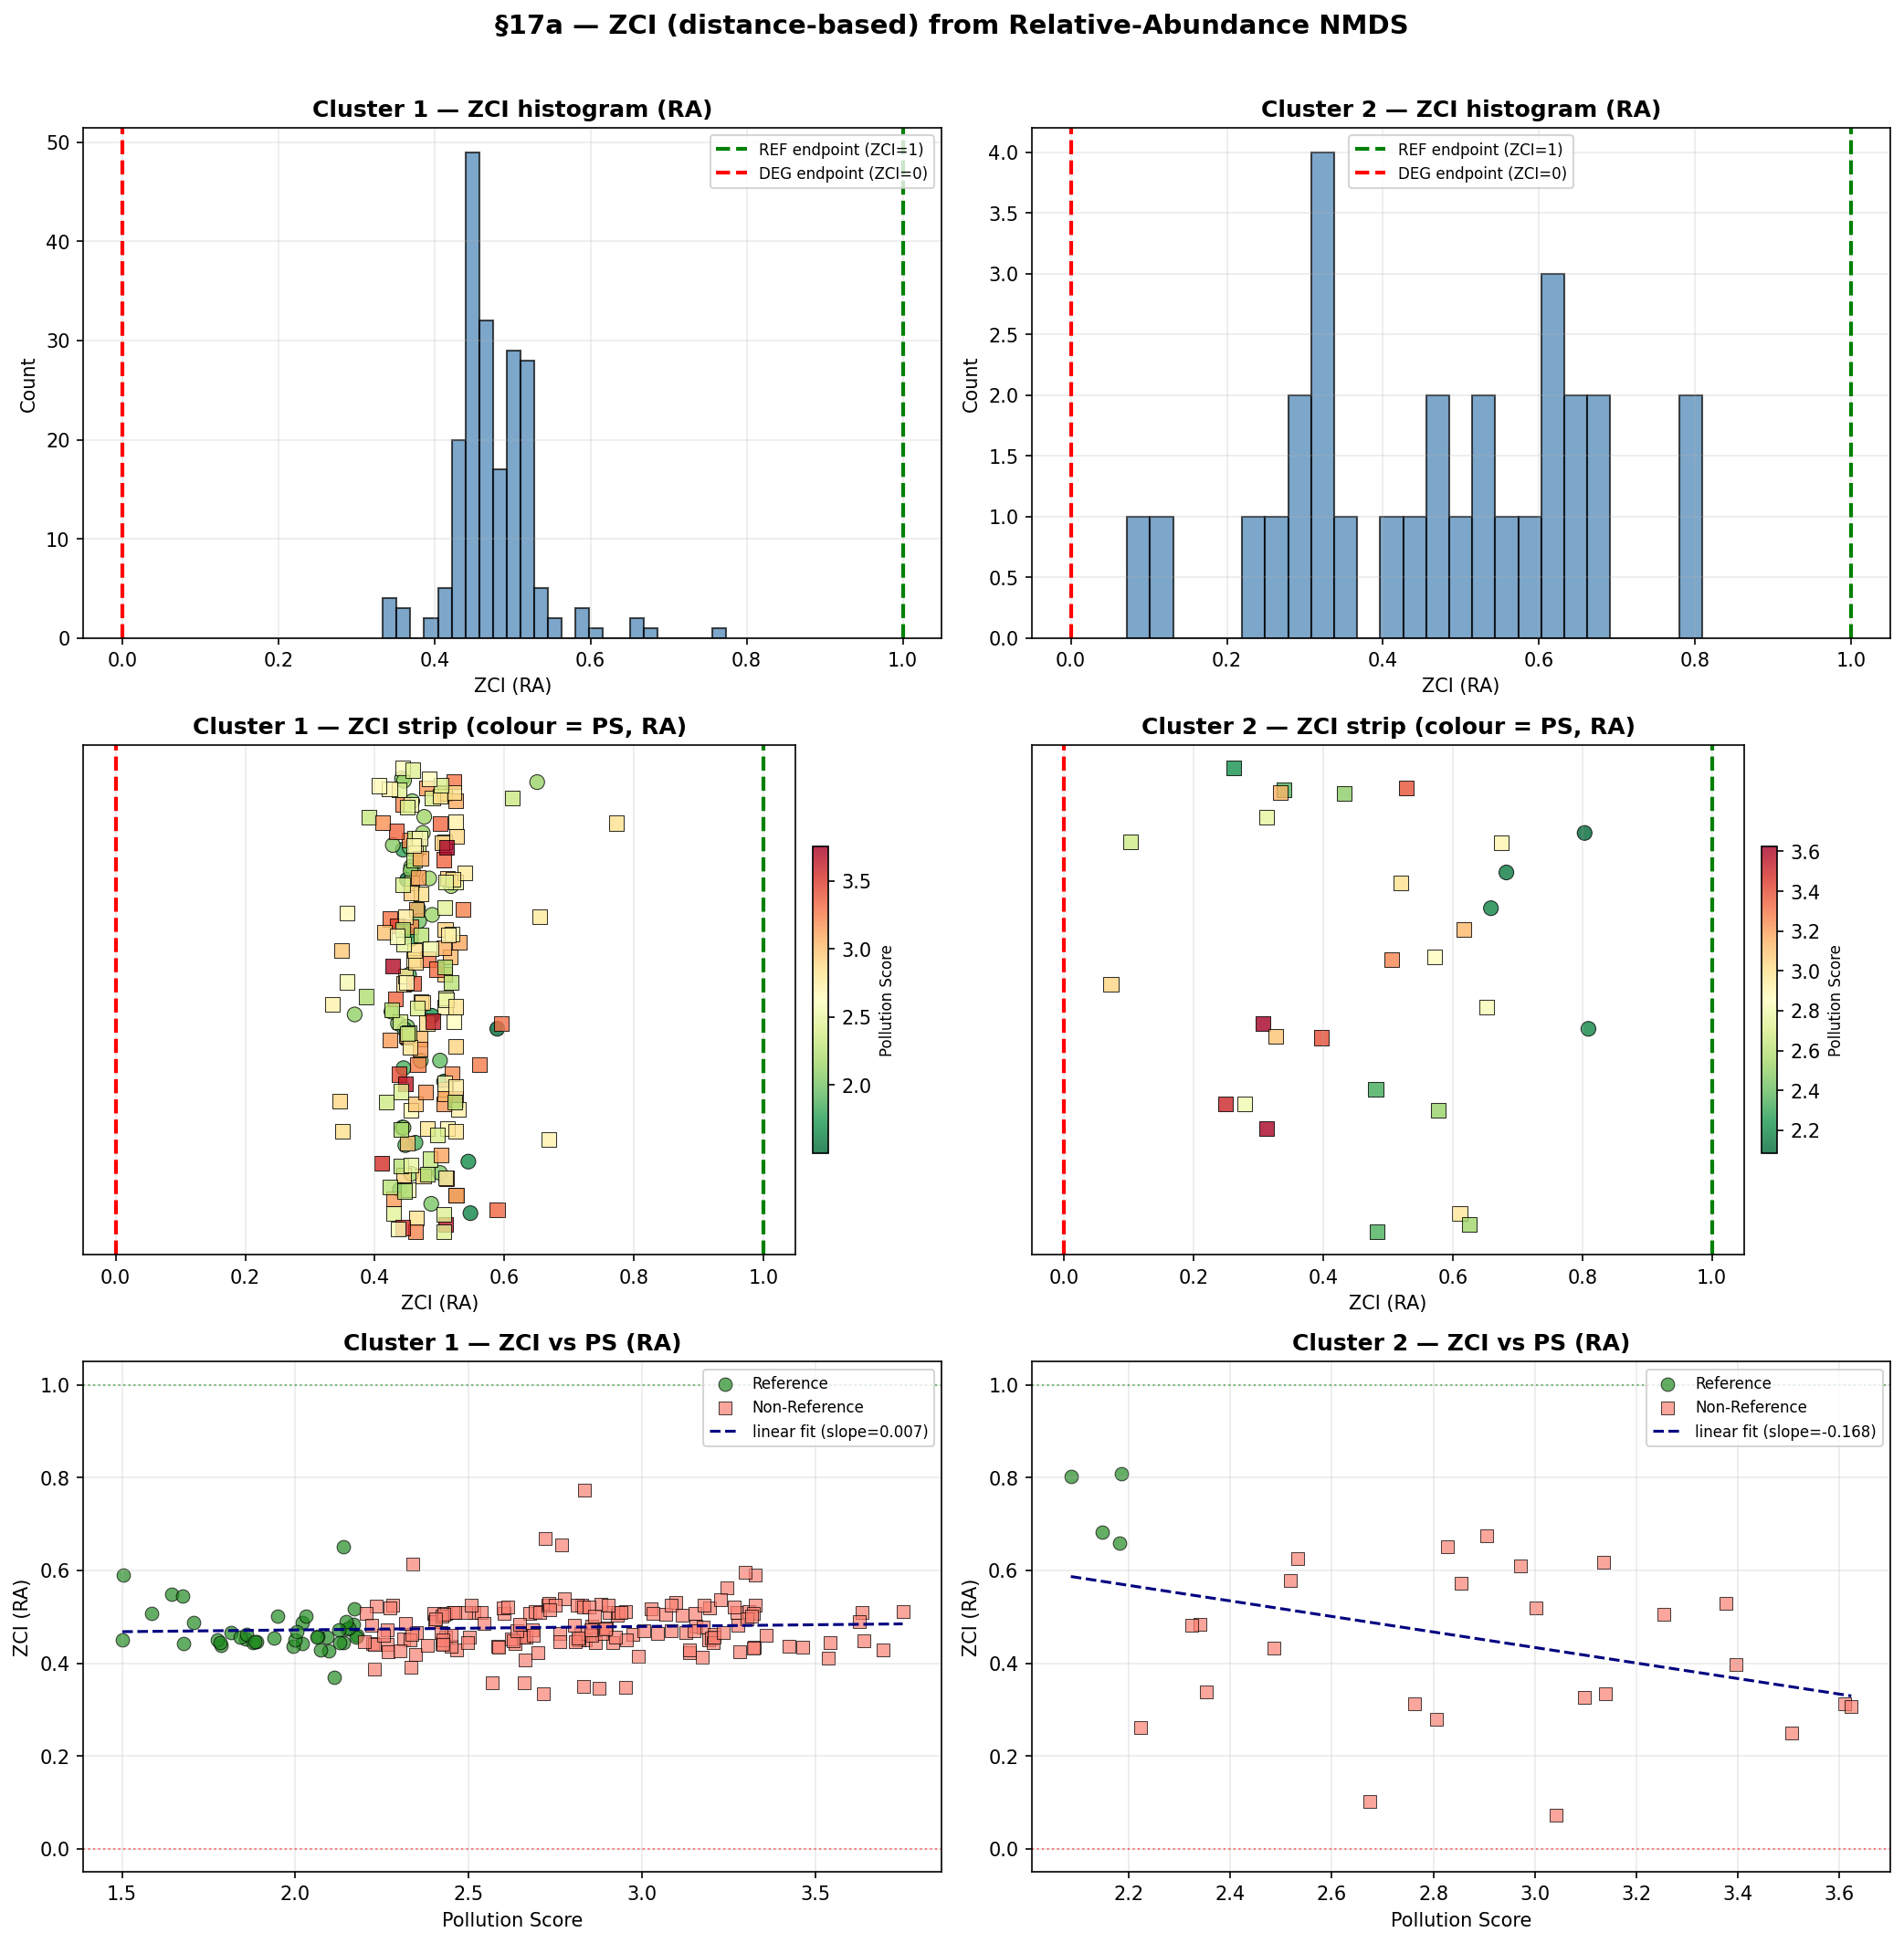


Cluster 1 — ZCI (RA, distance-based) summary
count    204.0000
mean       0.4764
std        0.0537
min        0.3342
25%        0.4456
50%        0.4667
75%        0.5083
max        0.7732

  Pearson  r = 0.0684  (p = 3.31e-01)
  Spearman ρ = 0.1311  (p = 6.16e-02)

Cluster 2 — ZCI (RA, distance-based) summary
count    29.0000
mean      0.4663
std       0.1926
min       0.0720
25%       0.3122
50%       0.4833
75%       0.6170
max       0.8093

  Pearson  r = -0.4066  (p = 2.86e-02)
  Spearman ρ = -0.4236  (p = 2.20e-02)


In [102]:
# ── §17a  ZCI Method 1 — distance-based (relative-abundance NMDS) ─────────────

zci_ra_all = {}   # cl -> Series of ZCI values (indexed by StationID)

for cl in clusters:
    info     = nmds_ra_ep[cl]
    coords   = info["coords_df"]
    ref_lab  = info["ref_label"]
    deg_lab  = info["deg_label"]

    ref_xy = coords.loc[ref_lab].values   # (2,)
    deg_xy = coords.loc[deg_lab].values   # (2,)

    real_idx = [i for i in coords.index if i not in (ref_lab, deg_lab)]
    real_coords = coords.loc[real_idx].values   # (n, 2)

    d_ref = np.linalg.norm(real_coords - ref_xy, axis=1)
    d_deg = np.linalg.norm(real_coords - deg_xy, axis=1)

    zci_raw = d_deg / (d_ref + d_deg + 1e-15)

    zci_series = pd.Series(zci_raw, index=real_idx, name="ZCI_RA")
    zci_ra_all[cl] = zci_series

    n_above = (zci_raw > 1).sum()
    n_below = (zci_raw < 0).sum()
    if n_above + n_below > 0:
        print(f"Cluster {cl}: {n_above} sites with ZCI > 1, "
              f"{n_below} sites with ZCI < 0 (before clipping)")

# ── Visualisation: 3 rows × n_clusters ────────────────────────────────────────
fig, axes = plt.subplots(3, n_clusters, figsize=(7 * n_clusters, 14), dpi=150)
if n_clusters == 1:
    axes = axes.reshape(3, 1)

for col_i, cl in enumerate(clusters):
    zci = zci_ra_all[cl]
    meta_cl = site_meta.loc[zci.index]
    ps = meta_cl["Pollution_Score"]

    # ── Row 1: Histogram ──────────────────────────────────────────────────
    ax1 = axes[0, col_i]
    ax1.hist(zci, bins=25, color="steelblue", edgecolor="k", alpha=0.7)
    ax1.axvline(1.0, color="green", ls="--", lw=2, label="REF endpoint (ZCI=1)")
    ax1.axvline(0.0, color="red",   ls="--", lw=2, label="DEG endpoint (ZCI=0)")
    ax1.set_xlabel("ZCI (RA)")
    ax1.set_ylabel("Count")
    ax1.set_title(f"Cluster {cl} — ZCI histogram (RA)", fontweight="bold")
    ax1.legend(fontsize=8)
    ax1.grid(alpha=0.25)

    # ── Row 2: Strip plot coloured by PS ──────────────────────────────────
    ax2 = axes[1, col_i]
    ref_mask = meta_cl["Is_Reference"] == 1
    ax2.scatter(
        zci[ref_mask.index[ref_mask]],
        np.random.default_rng(42).uniform(-0.3, 0.3, size=ref_mask.sum()),
        c=ps[ref_mask], cmap="RdYlGn_r", marker="o",
        s=60, edgecolors="k", linewidths=0.5, alpha=0.8,
        vmin=ps.min(), vmax=ps.max(),
    )
    sc2 = ax2.scatter(
        zci[ref_mask.index[~ref_mask]],
        np.random.default_rng(43).uniform(-0.3, 0.3, size=(~ref_mask).sum()),
        c=ps[~ref_mask], cmap="RdYlGn_r", marker="s",
        s=60, edgecolors="k", linewidths=0.5, alpha=0.8,
        vmin=ps.min(), vmax=ps.max(),
    )
    ax2.axvline(1.0, color="green", ls="--", lw=2)
    ax2.axvline(0.0, color="red",   ls="--", lw=2)
    ax2.set_xlabel("ZCI (RA)")
    ax2.set_yticks([])
    ax2.set_title(f"Cluster {cl} — ZCI strip (colour = PS, RA)", fontweight="bold")
    cb = fig.colorbar(sc2, ax=ax2, shrink=0.6, pad=0.02)
    cb.set_label("Pollution Score", fontsize=8)
    ax2.grid(axis="x", alpha=0.25)

    # ── Row 3: ZCI vs Pollution Score ─────────────────────────────────────
    ax3 = axes[2, col_i]
    ax3.scatter(
        ps[ref_mask], zci[ref_mask.index[ref_mask]],
        c="forestgreen", marker="o", s=50, edgecolors="k",
        linewidths=0.5, alpha=0.7, label="Reference",
    )
    ax3.scatter(
        ps[~ref_mask], zci[ref_mask.index[~ref_mask]],
        c="salmon", marker="s", s=50, edgecolors="k",
        linewidths=0.5, alpha=0.7, label="Non-Reference",
    )
    z = np.polyfit(ps, zci.loc[ps.index], 1)
    xfit = np.linspace(ps.min(), ps.max(), 100)
    ax3.plot(xfit, np.polyval(z, xfit), "--", color="navy", lw=1.5,
             label=f"linear fit (slope={z[0]:.3f})")
    ax3.set_xlabel("Pollution Score")
    ax3.set_ylabel("ZCI (RA)")
    ax3.set_title(f"Cluster {cl} — ZCI vs PS (RA)", fontweight="bold")
    ax3.axhline(1.0, color="green", ls=":", lw=1, alpha=0.5)
    ax3.axhline(0.0, color="red",   ls=":", lw=1, alpha=0.5)
    ax3.legend(fontsize=8)
    ax3.grid(alpha=0.25)

fig.suptitle("§17a — ZCI (distance-based) from Relative-Abundance NMDS",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

# ── Summary statistics ────────────────────────────────────────────────────────
for cl in clusters:
    zci = zci_ra_all[cl]
    ps = site_meta.loc[zci.index, "Pollution_Score"]
    r_pear, p_pear = pearsonr(ps, zci)
    r_spear, p_spear = spearmanr(ps, zci)
    print(f"\n{'='*55}")
    print(f"Cluster {cl} — ZCI (RA, distance-based) summary")
    print(f"{'='*55}")
    print(zci.describe().round(4).to_string())
    print(f"\n  Pearson  r = {r_pear:.4f}  (p = {p_pear:.2e})")
    print(f"  Spearman ρ = {r_spear:.4f}  (p = {p_spear:.2e})")

### 17b · ZCI Method 2 — Per-Axis Regression + envfit (Relative Abundance NMDS)

Instead of a single scalar ZCI, examine how each **NMDS axis** correlates with
Pollution Score via OLS regression, and use `envfit_vector()` to project PS onto
the 2-D ordination as a joint vector.

Mirrors the approach in §15, now on **relative-abundance** ordination with
endpoints included in the fit.

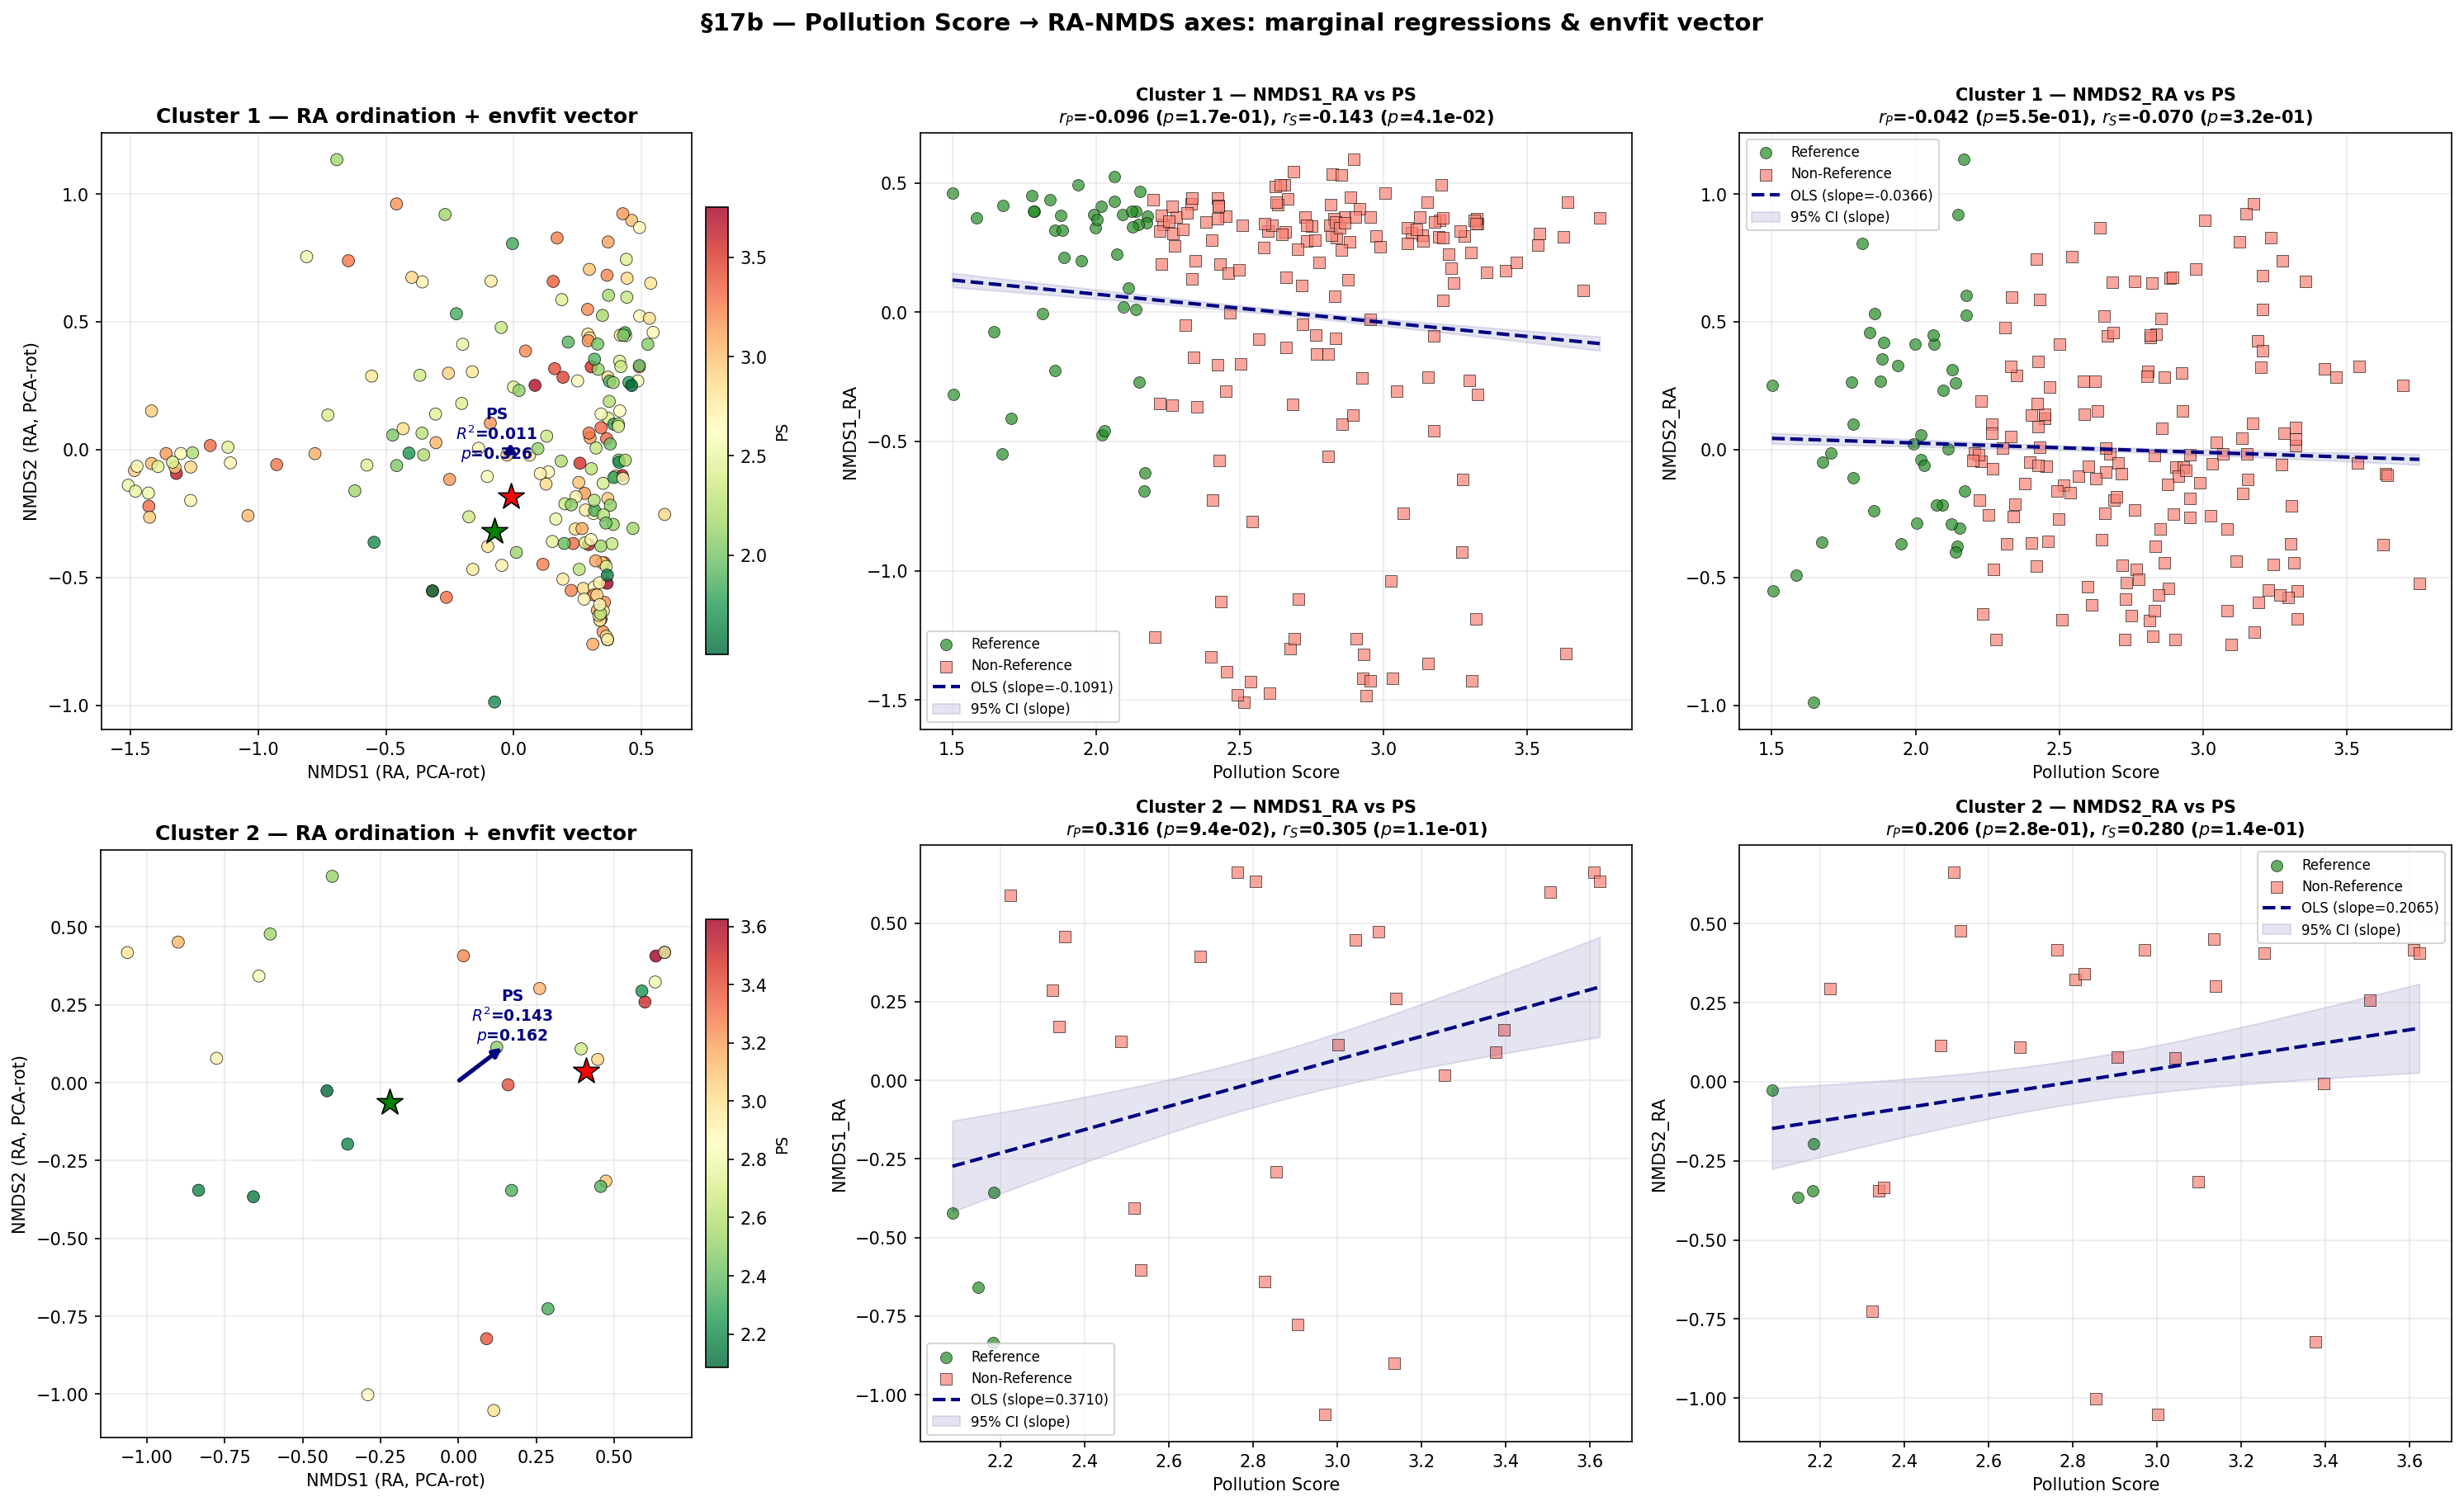


  §17b — Pollution Score → RA-NMDS axes: regression & vector-fitting summary
 Cluster           Response   n Pearson r Pearson p Spearman ρ Spearman p OLS slope OLS intercept OLS R² OLS p(slope)
       1           NMDS1_RA 204   -0.0963  1.71e-01    -0.1429   4.14e-02  -0.10913       0.28806 0.0093     1.71e-01
       1           NMDS2_RA 204   -0.0423  5.48e-01    -0.0695   3.23e-01  -0.03657       0.09887 0.0018     5.48e-01
       1 envfit (both axes) 204         —         —          —          —         —             — 0.0111     3.26e-01
       2           NMDS1_RA  29    0.3164  9.44e-02     0.3049   1.08e-01   0.37104      -1.04748 0.1001     9.44e-02
       2           NMDS2_RA  29    0.2056  2.85e-01     0.2803   1.41e-01   0.20646      -0.57835 0.0423     2.85e-01
       2 envfit (both axes)  29         —         —          —          —         —             — 0.1429     1.62e-01

• envfit R² = proportion of PS variance explained by both RA-NMDS axes jointly
• envfit p  = pe

In [103]:
# ── §17b  Per-axis regression + envfit on RA NMDS ─────────────────────────────

fig, axes = plt.subplots(n_clusters, 3, figsize=(20, 6 * n_clusters), dpi=150)
if n_clusters == 1:
    axes = axes.reshape(1, 3)

reg_rows_ra = []  # collect for summary table

for row_i, cl in enumerate(clusters):
    info     = nmds_ra_ep[cl]
    coords   = info["coords_df"]
    ref_lab  = info["ref_label"]
    deg_lab  = info["deg_label"]

    # Real sites only (exclude endpoints)
    real_idx = [i for i in coords.index if i not in (ref_lab, deg_lab)]
    coords_real = coords.loc[real_idx]
    meta_cl  = site_meta.loc[real_idx]
    ps       = meta_cl["Pollution_Score"]
    ref_mask = meta_cl["Is_Reference"] == 1

    x1 = coords_real["NMDS1"].values
    x2 = coords_real["NMDS2"].values

    # ── envfit ────────────────────────────────────────────────────────────
    r2_env, arrow, p_env = envfit_vector(
        np.column_stack([x1, x2]), ps.values, n_perm=999
    )

    # ── Column 0: ordination + envfit arrow ───────────────────────────────
    ax = axes[row_i, 0]
    sc = ax.scatter(
        x1, x2, c=ps, cmap="RdYlGn_r", s=50,
        edgecolors="k", linewidths=0.4, alpha=0.8,
        vmin=ps.min(), vmax=ps.max(),
    )
    # endpoint stars
    ax.scatter(*coords.loc[ref_lab], marker="*", s=250,
               c="green", edgecolors="k", linewidths=0.8, zorder=5)
    ax.scatter(*coords.loc[deg_lab], marker="*", s=250,
               c="red", edgecolors="k", linewidths=0.8, zorder=5)

    # envfit arrow — scale ~30 % of axis range
    x_range = x1.max() - x1.min()
    y_range = x2.max() - x2.min()
    scale = 0.30 * max(x_range, y_range) * np.sqrt(r2_env)
    cx, cy = x1.mean(), x2.mean()
    ax.annotate(
        "", xy=(cx + arrow[0] * scale, cy + arrow[1] * scale),
        xytext=(cx, cy),
        arrowprops=dict(arrowstyle="-|>", color="navy", lw=2.5),
    )
    ax.text(
        cx + arrow[0] * scale * 1.15,
        cy + arrow[1] * scale * 1.15,
        f"PS\n$R^2$={r2_env:.3f}\n$p$={p_env:.3f}",
        fontsize=9, fontweight="bold", color="navy", ha="center",
    )
    fig.colorbar(sc, ax=ax, shrink=0.75, pad=0.02).set_label("PS", fontsize=9)
    ax.set_xlabel("NMDS1 (RA, PCA-rot)")
    ax.set_ylabel("NMDS2 (RA, PCA-rot)")
    ax.set_title(f"Cluster {cl} — RA ordination + envfit vector",
                 fontweight="bold")
    ax.set_aspect("equal")
    ax.grid(alpha=0.25)

    # ── Columns 1–2: marginal regressions ────────────────────────────────
    for col_j, (axis_vals, axis_lab) in enumerate(
        [(x1, "NMDS1_RA"), (x2, "NMDS2_RA")], start=1
    ):
        ax = axes[row_i, col_j]
        lr = linregress(ps.values, axis_vals)
        r_pear, p_pear = pearsonr(ps.values, axis_vals)
        r_spear, p_spear = spearmanr(ps.values, axis_vals)

        # scatter (ref / non-ref)
        ax.scatter(
            ps[ref_mask], axis_vals[ref_mask.values],
            c="forestgreen", marker="o", s=45, edgecolors="k",
            linewidths=0.4, alpha=0.7, label="Reference",
        )
        ax.scatter(
            ps[~ref_mask], axis_vals[(~ref_mask).values],
            c="salmon", marker="s", s=45, edgecolors="k",
            linewidths=0.4, alpha=0.7, label="Non-Reference",
        )
        # regression line + 95 % CI band
        xfit = np.linspace(ps.min(), ps.max(), 200)
        yfit = lr.slope * xfit + lr.intercept
        ax.plot(xfit, yfit, "--", color="navy", lw=2,
                label=f"OLS (slope={lr.slope:.4f})")
        n = len(ps)
        x_mean = ps.mean()
        se_pred = lr.stderr * np.sqrt(
            1 / n + (xfit - x_mean) ** 2 / np.sum((ps.values - x_mean) ** 2)
        )
        ax.fill_between(xfit, yfit - 1.96 * se_pred, yfit + 1.96 * se_pred,
                         color="navy", alpha=0.10, label="95% CI (slope)")

        ax.set_xlabel("Pollution Score")
        ax.set_ylabel(axis_lab)
        ax.set_title(
            f"Cluster {cl} — {axis_lab} vs PS\n"
            f"$r_P$={r_pear:.3f} ($p$={p_pear:.1e}), "
            f"$r_S$={r_spear:.3f} ($p$={p_spear:.1e})",
            fontweight="bold", fontsize=10,
        )
        ax.legend(fontsize=8, loc="best")
        ax.grid(alpha=0.25)

        reg_rows_ra.append({
            "Cluster": cl,
            "Response": axis_lab,
            "n": n,
            "Pearson r": r_pear,
            "Pearson p": p_pear,
            "Spearman ρ": r_spear,
            "Spearman p": p_spear,
            "OLS slope": lr.slope,
            "OLS intercept": lr.intercept,
            "OLS R²": lr.rvalue ** 2,
            "OLS p(slope)": lr.pvalue,
        })

    # envfit row
    reg_rows_ra.append({
        "Cluster": cl,
        "Response": "envfit (both axes)",
        "n": len(ps),
        "Pearson r": np.nan,
        "Pearson p": np.nan,
        "Spearman ρ": np.nan,
        "Spearman p": np.nan,
        "OLS slope": np.nan,
        "OLS intercept": np.nan,
        "OLS R²": r2_env,
        "OLS p(slope)": p_env,
    })

fig.suptitle(
    "§17b — Pollution Score → RA-NMDS axes: marginal regressions & envfit vector",
    fontsize=14, fontweight="bold", y=1.01,
)
plt.tight_layout()
plt.show()

# ── Summary table ─────────────────────────────────────────────────────────────
reg_df_ra = pd.DataFrame(reg_rows_ra)

fmt_cols = {
    "Pearson r": "{:.4f}", "Pearson p": "{:.2e}",
    "Spearman ρ": "{:.4f}", "Spearman p": "{:.2e}",
    "OLS slope": "{:.5f}", "OLS intercept": "{:.5f}",
    "OLS R²": "{:.4f}", "OLS p(slope)": "{:.2e}",
}
styled_ra = reg_df_ra.copy()
for col, fmt in fmt_cols.items():
    styled_ra[col] = styled_ra[col].apply(
        lambda v, f=fmt: f.format(v) if pd.notna(v) else "—"
    )

print("\n" + "=" * 120)
print("  §17b — Pollution Score → RA-NMDS axes: regression & vector-fitting summary")
print("=" * 120)
print(styled_ra.to_string(index=False))
print("=" * 120)
print("\n• envfit R² = proportion of PS variance explained by both RA-NMDS axes jointly")
print("• envfit p  = permutation p-value (999 permutations)")
print("• Significance codes: p < 0.001 '***', p < 0.01 '**', p < 0.05 '*'")

### 17c · PCoA-based ZCI on Relative-Abundance Taxa

Same logic as §16, but applied to **relative-abundance** (RA) taxa instead of
octave-scale taxa:

1. Bray–Curtis distance on RA matrix → classical PCoA (eigendecomposition).
2. Extract **Axis 1** score per site → flip sign so ↑ = better condition.
3. Rescale to [0, 1] → **PCoA-ZCI (RA)**.
4. Correlate with Pollution Score; compare with octave-based PCoA-ZCI and other
   RA-based methods (§17a distance-ZCI, §17b envfit).

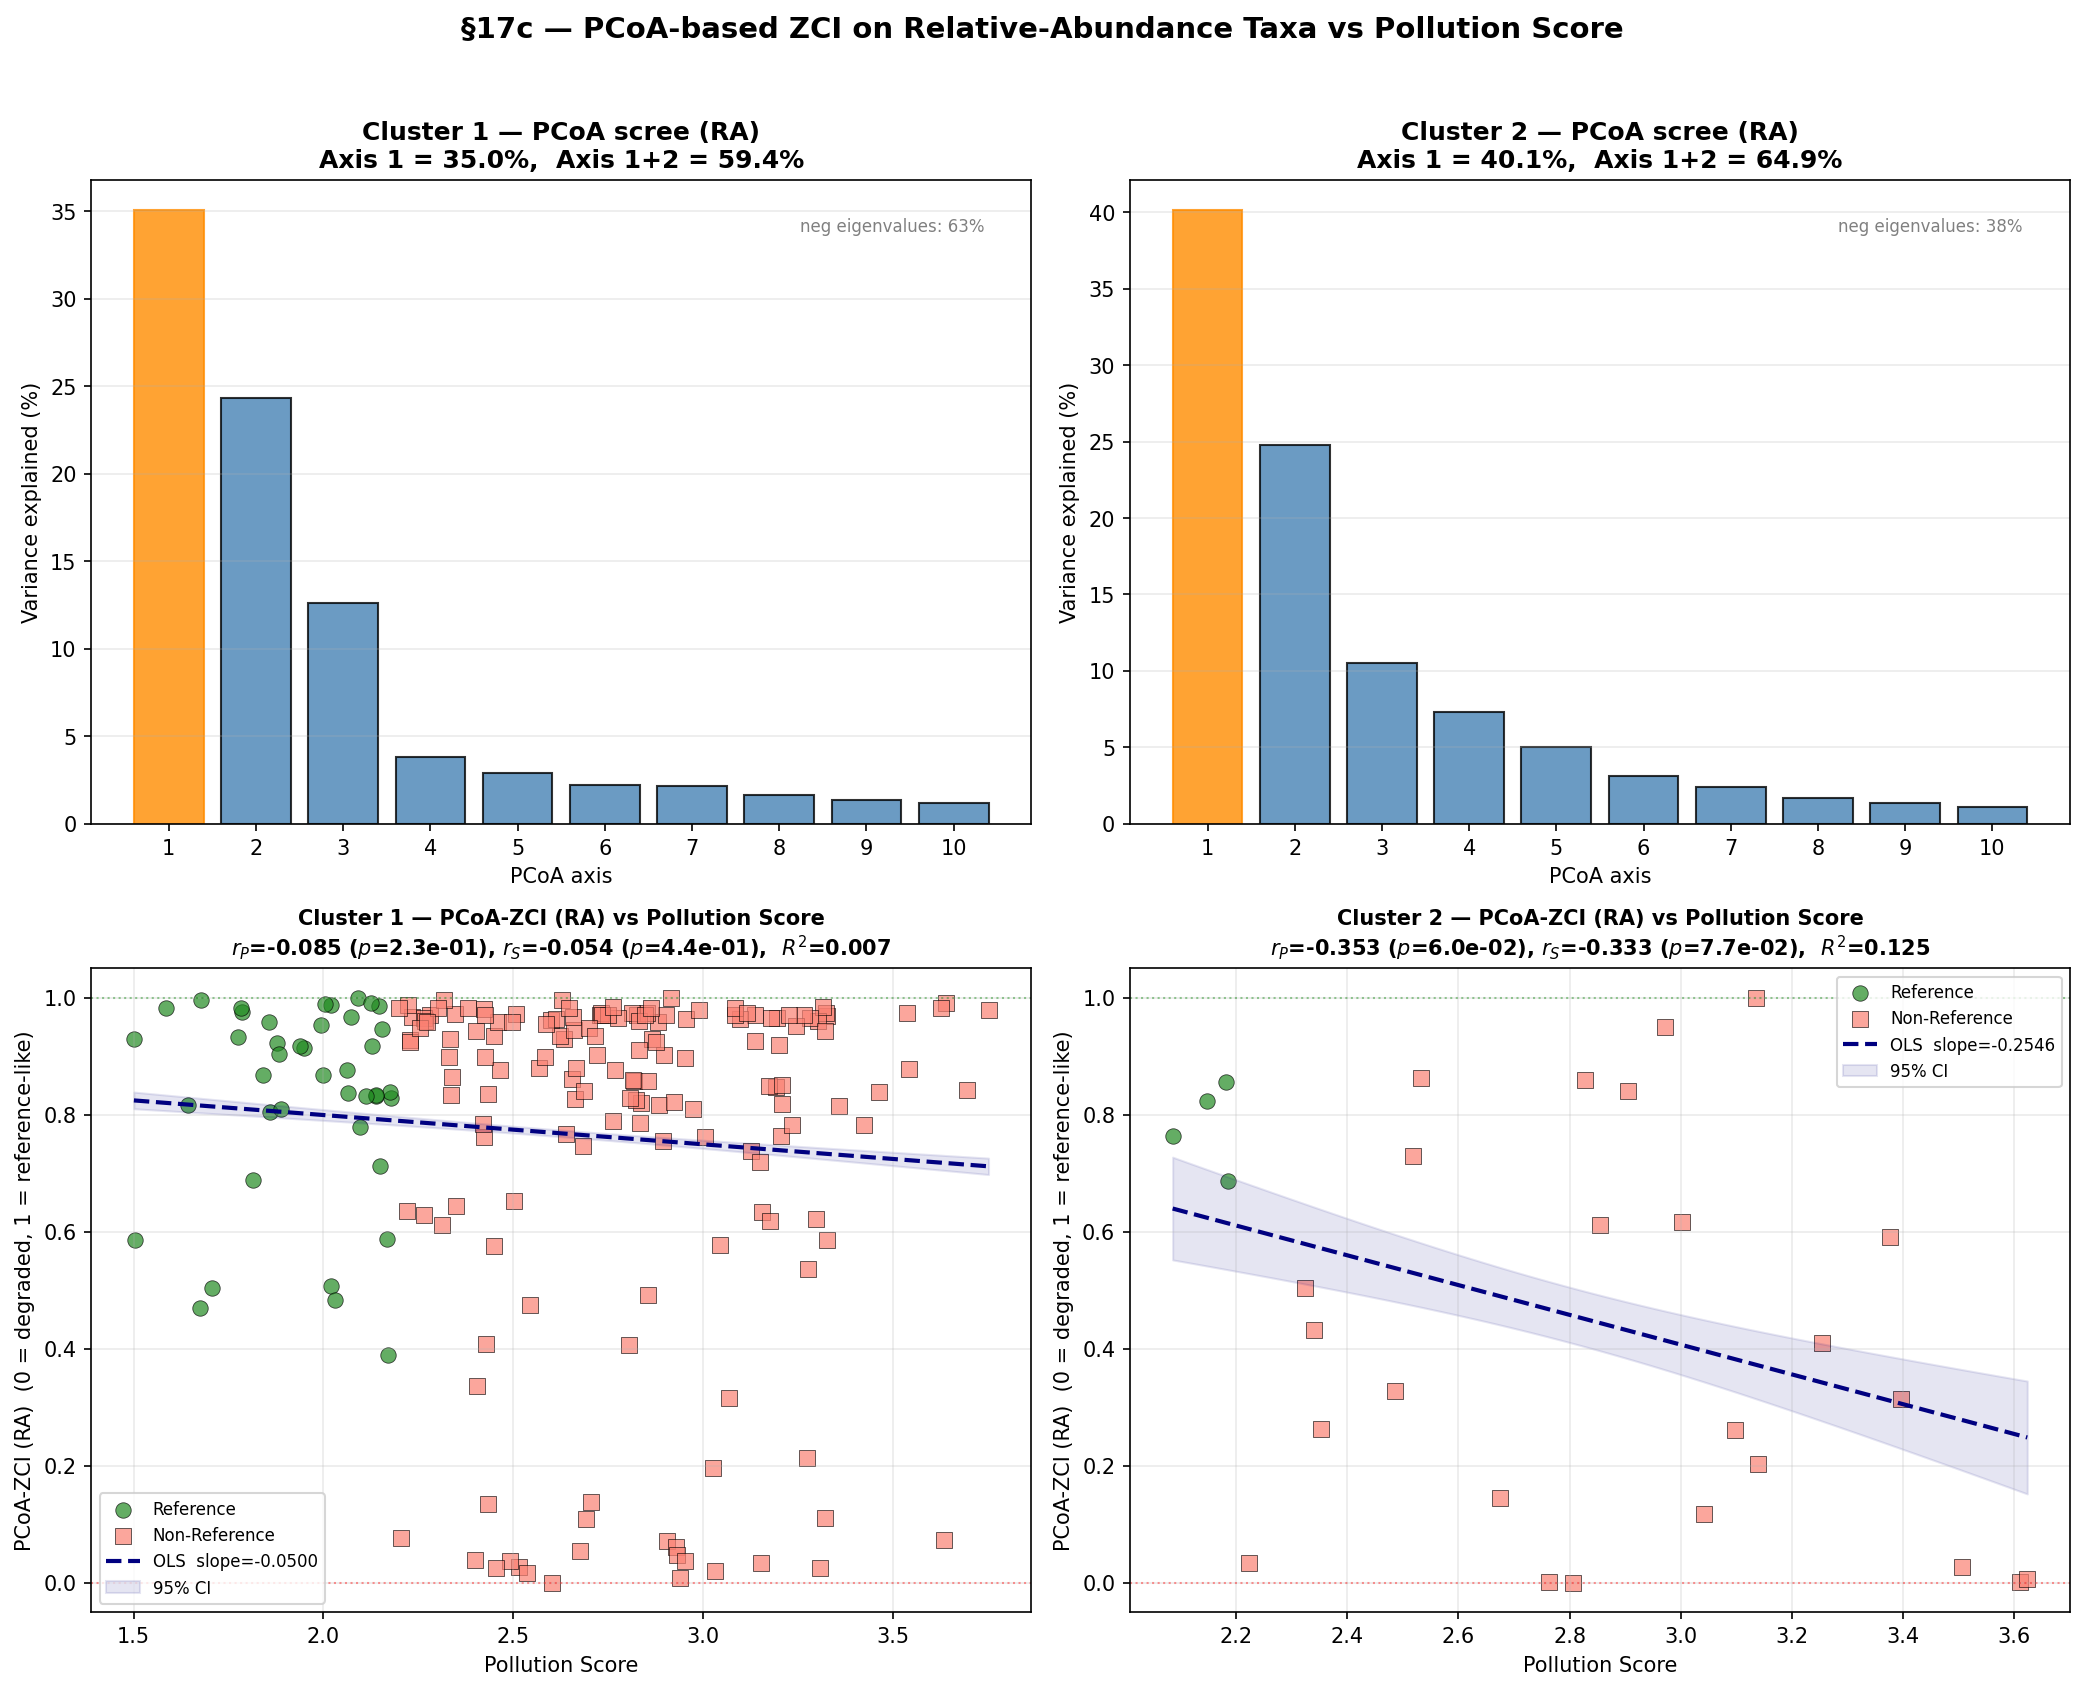


  §17 — RA-based ZCI methods: correlation with Pollution Score (+ octave PCoA for reference)
 Cluster                   Method Pearson r Pearson p Spearman ρ Spearman p R² (multivar.) p (perm)
       1      Dist-ZCI  RA (§17a)    0.0684  3.31e-01     0.1311   6.16e-02              —        —
       1    NMDS envfit RA (§17b)         —         —          —          —         0.0111    0.326
       1      PCoA-ZCI  RA (§17c)   -0.0852  2.26e-01    -0.0544   4.40e-01              —        —
       1 PCoA-ZCI  oct (§16, ref)   -0.0732  2.98e-01     0.0138   8.45e-01              —        —
       2      Dist-ZCI  RA (§17a)   -0.4066  2.86e-02    -0.4236   2.20e-02              —        —
       2    NMDS envfit RA (§17b)         —         —          —          —         0.1429    0.162
       2      PCoA-ZCI  RA (§17c)   -0.3531  6.03e-02    -0.3333   7.73e-02              —        —
       2 PCoA-ZCI  oct (§16, ref)   -0.3617  5.38e-02    -0.3589   5.59e-02              —        —

  PCo

In [104]:
# ── §17c  PCoA-based ZCI on relative-abundance taxa ───────────────────────────
# pcoa_from_bc() is already defined in §16 (eigendecomposition of the
# double-centred Bray–Curtis matrix).

pcoa_ra_results = {}   # cl -> (eigvals, coords_df, var_exp)
pcoa_ra_zci     = {}   # cl -> Series (PCoA-ZCI_RA, [0-1]-rescaled)

fig, axes = plt.subplots(2, n_clusters, figsize=(7 * n_clusters, 11), dpi=150)
if n_clusters == 1:
    axes = axes.reshape(2, 1)

reg_rows_pcoa_ra = []

for col_i, cl in enumerate(clusters):
    cl_sites = site_meta.index[site_meta["Cluster"] == cl]
    taxa_cl_ra = taxa_relabd.loc[cl_sites]
    meta_cl    = site_meta.loc[cl_sites]
    ps         = meta_cl["Pollution_Score"]
    ref_mask   = meta_cl["Is_Reference"] == 1

    # ── PCoA on relative-abundance taxa ───────────────────────────────────
    eigvals, coords_df, var_exp = pcoa_from_bc(taxa_cl_ra)
    pcoa_ra_results[cl] = (eigvals, coords_df, var_exp)

    ax1_raw = coords_df["PCoA1"].values

    # Flip sign so that higher PCoA-ZCI = better condition (lower PS)
    if np.corrcoef(ax1_raw, ps.values)[0, 1] > 0:
        ax1_raw = -ax1_raw

    # Rescale to [0, 1]
    zci_01 = (ax1_raw - ax1_raw.min()) / (ax1_raw.max() - ax1_raw.min() + 1e-15)
    pcoa_ra_zci[cl] = pd.Series(zci_01, index=cl_sites, name="PCoA_ZCI_RA")

    # ── Row 0: scree — first 10 axes ─────────────────────────────────────
    ax = axes[0, col_i]
    k_show = min(10, len(var_exp))
    bars = ax.bar(range(1, k_show + 1), var_exp[:k_show] * 100,
                  color="steelblue", edgecolor="k", alpha=0.8)
    bars[0].set_color("darkorange")   # highlight axis 1
    ax.set_xlabel("PCoA axis")
    ax.set_ylabel("Variance explained (%)")
    ax.set_title(
        f"Cluster {cl} — PCoA scree (RA)\n"
        f"Axis 1 = {var_exp[0]*100:.1f}%,  "
        f"Axis 1+2 = {(var_exp[0]+var_exp[1])*100:.1f}%",
        fontweight="bold",
    )
    ax.set_xticks(range(1, k_show + 1))
    ax.grid(axis="y", alpha=0.25)

    # annotate negative eigenvalue fraction
    bc_sq_ra = squareform(pdist(taxa_cl_ra.values, metric="braycurtis"))
    n_ra = len(taxa_cl_ra)
    H_ra = np.eye(n_ra) - np.ones((n_ra, n_ra)) / n_ra
    all_eigs_ra = np.linalg.eigvalsh(-0.5 * H_ra @ (bc_sq_ra ** 2) @ H_ra)
    neg_frac = (all_eigs_ra < -1e-12).sum() / len(all_eigs_ra) * 100
    ax.text(0.95, 0.92, f"neg eigenvalues: {neg_frac:.0f}%",
            transform=ax.transAxes, ha="right", fontsize=8, color="gray")

    # ── Row 1: PCoA-ZCI (RA) vs Pollution Score ──────────────────────────
    ax = axes[1, col_i]
    zci_s = pcoa_ra_zci[cl]
    lr = linregress(ps.values, zci_s.values)
    r_pear, p_pear = pearsonr(ps.values, zci_s.values)
    r_spear, p_spear = spearmanr(ps.values, zci_s.values)

    ax.scatter(
        ps[ref_mask], zci_s[ref_mask.index[ref_mask]],
        c="forestgreen", marker="o", s=55, edgecolors="k",
        linewidths=0.4, alpha=0.7, label="Reference",
    )
    ax.scatter(
        ps[~ref_mask], zci_s[ref_mask.index[~ref_mask]],
        c="salmon", marker="s", s=55, edgecolors="k",
        linewidths=0.4, alpha=0.7, label="Non-Reference",
    )
    # regression line + 95 % CI band
    xfit = np.linspace(ps.min(), ps.max(), 200)
    yfit = lr.slope * xfit + lr.intercept
    ax.plot(xfit, yfit, "--", color="navy", lw=2,
            label=f"OLS  slope={lr.slope:.4f}")
    n_pts = len(ps)
    x_mean = ps.mean()
    se_pred = lr.stderr * np.sqrt(
        1 / n_pts + (xfit - x_mean) ** 2 / np.sum((ps.values - x_mean) ** 2)
    )
    ax.fill_between(xfit, yfit - 1.96 * se_pred, yfit + 1.96 * se_pred,
                     color="navy", alpha=0.10, label="95% CI")

    sig_star = ""
    if p_pear < 0.001: sig_star = "***"
    elif p_pear < 0.01: sig_star = "**"
    elif p_pear < 0.05: sig_star = "*"

    ax.set_xlabel("Pollution Score")
    ax.set_ylabel("PCoA-ZCI (RA)  (0 = degraded, 1 = reference-like)")
    ax.set_title(
        f"Cluster {cl} — PCoA-ZCI (RA) vs Pollution Score\n"
        f"$r_P$={r_pear:.3f}{sig_star} ($p$={p_pear:.1e}), "
        f"$r_S$={r_spear:.3f} ($p$={p_spear:.1e}),  "
        f"$R^2$={lr.rvalue**2:.3f}",
        fontweight="bold", fontsize=10,
    )
    ax.axhline(0, color="red",   ls=":", lw=1, alpha=0.4)
    ax.axhline(1, color="green", ls=":", lw=1, alpha=0.4)
    ax.legend(fontsize=8, loc="best")
    ax.grid(alpha=0.25)

    reg_rows_pcoa_ra.append({
        "Cluster": cl,
        "Metric": "PCoA-ZCI_RA (Axis 1)",
        "Var expl. Axis 1 (%)": round(var_exp[0] * 100, 2),
        "n": n_pts,
        "Pearson r": r_pear,
        "Pearson p": p_pear,
        "Spearman ρ": r_spear,
        "Spearman p": p_spear,
        "OLS slope": lr.slope,
        "OLS R²": lr.rvalue ** 2,
        "OLS p(slope)": lr.pvalue,
    })

fig.suptitle(
    "§17c — PCoA-based ZCI on Relative-Abundance Taxa vs Pollution Score",
    fontsize=14, fontweight="bold", y=1.02,
)
plt.tight_layout()
plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# Comparison table: all RA-based methods + octave PCoA-ZCI (§16) for reference
# ══════════════════════════════════════════════════════════════════════════════
comp_rows_ra = []
for cl in clusters:
    ps_cl = site_meta.loc[site_meta["Cluster"] == cl, "Pollution_Score"]

    # ─ §17a: distance-based ZCI (RA) ─
    zci_ra = zci_ra_all[cl]
    r_, p_ = pearsonr(ps_cl.loc[zci_ra.index], zci_ra)
    rs_, ps_ = spearmanr(ps_cl.loc[zci_ra.index], zci_ra)
    comp_rows_ra.append({
        "Cluster": cl, "Method": "Dist-ZCI  RA (§17a)",
        "Pearson r": r_, "Pearson p": p_,
        "Spearman ρ": rs_, "Spearman p": ps_,
    })

    # ─ §17b: RA NMDS envfit ─
    envfit_match = reg_df_ra[
        (reg_df_ra["Cluster"] == cl) & (reg_df_ra["Response"] == "envfit (both axes)")
    ]
    if len(envfit_match) > 0:
        row = envfit_match.iloc[0]
        comp_rows_ra.append({
            "Cluster": cl, "Method": "NMDS envfit RA (§17b)",
            "Pearson r": np.nan, "Pearson p": np.nan,
            "Spearman ρ": np.nan, "Spearman p": np.nan,
            "R² (multivar.)": row["OLS R²"],
            "p (perm)": row["OLS p(slope)"],
        })

    # ─ §17c: PCoA-ZCI (RA) ─
    zci_pc_ra = pcoa_ra_zci[cl]
    r_, p_ = pearsonr(ps_cl.loc[zci_pc_ra.index], zci_pc_ra)
    rs_, ps_ = spearmanr(ps_cl.loc[zci_pc_ra.index], zci_pc_ra)
    comp_rows_ra.append({
        "Cluster": cl, "Method": "PCoA-ZCI  RA (§17c)",
        "Pearson r": r_, "Pearson p": p_,
        "Spearman ρ": rs_, "Spearman p": ps_,
    })

    # ─ §16: PCoA-ZCI (octave) for reference ─
    zci_oct = pcoa_zci[cl]
    r_, p_ = pearsonr(ps_cl.loc[zci_oct.index], zci_oct)
    rs_, ps_ = spearmanr(ps_cl.loc[zci_oct.index], zci_oct)
    comp_rows_ra.append({
        "Cluster": cl, "Method": "PCoA-ZCI  oct (§16, ref)",
        "Pearson r": r_, "Pearson p": p_,
        "Spearman ρ": rs_, "Spearman p": ps_,
    })

comp_df_ra = pd.DataFrame(comp_rows_ra)
fmt_map_ra = {
    "Pearson r": "{:.4f}", "Pearson p": "{:.2e}",
    "Spearman ρ": "{:.4f}", "Spearman p": "{:.2e}",
    "R² (multivar.)": "{:.4f}", "p (perm)": "{:.3f}",
}
comp_styled_ra = comp_df_ra.copy()
for col_name, fmt in fmt_map_ra.items():
    if col_name in comp_styled_ra.columns:
        comp_styled_ra[col_name] = comp_styled_ra[col_name].apply(
            lambda v, f=fmt: f.format(v) if pd.notna(v) else "—"
        )

print("\n" + "=" * 115)
print("  §17 — RA-based ZCI methods: correlation with Pollution Score (+ octave PCoA for reference)")
print("=" * 115)
print(comp_styled_ra.to_string(index=False))
print("=" * 115)

# ── PCoA-ZCI (RA) regression detail ──────────────────────────────────────────
pcoa_ra_reg_df = pd.DataFrame(reg_rows_pcoa_ra)
fmt_pcoa = {
    "Var expl. Axis 1 (%)": "{:.2f}",
    "Pearson r": "{:.4f}", "Pearson p": "{:.2e}",
    "Spearman ρ": "{:.4f}", "Spearman p": "{:.2e}",
    "OLS slope": "{:.5f}", "OLS R²": "{:.4f}", "OLS p(slope)": "{:.2e}",
}
pcoa_ra_styled = pcoa_ra_reg_df.copy()
for col_name, fmt in fmt_pcoa.items():
    pcoa_ra_styled[col_name] = pcoa_ra_styled[col_name].apply(
        lambda v, f=fmt: f.format(v) if pd.notna(v) else "—"
    )

print("\n" + "=" * 115)
print("  PCoA-ZCI (RA) Axis 1 — regression detail")
print("=" * 115)
print(pcoa_ra_styled.to_string(index=False))
print("=" * 115)

## 18 · Supervised Community–Pollution Measures

Sections §4–§17 used **unconstrained** ordination (NMDS, PCoA) — the dominant
axes maximise total community variation, but are *not* guaranteed to align with
the pollution gradient.  This section uses two **supervised** methods that
explicitly optimise the community–pollution relationship.

---

### 18.1 — What is the CWM (Community-Weighted Mean) Tolerance Index?

The **CWM Tolerance Index** is a classical bioassessment technique from
Weighted Averaging (WA) regression (ter Braak & Looman, 1986; ter Braak &
van Dam, 1989).  It works in two steps:

**Step 1 — Estimate each taxon's pollution optimum** $u_j$

For taxon $j$, its "optimum" is the abundance-weighted mean of the
environmental variable (here Pollution Score) across all sites:

$$
u_j \;=\; \frac{\displaystyle\sum_{i=1}^{n} y_{ij}\;\text{PS}_i}
               {\displaystyle\sum_{i=1}^{n} y_{ij}}
$$

where $y_{ij}$ is the (transformed) abundance of taxon $j$ at site $i$.
Taxa found primarily at high-PS sites get high optima (pollution-tolerant);
taxa found at low-PS sites get low optima (pollution-sensitive).

**Step 2 — Predict each site's pollution from its community**

Each site's CWM index is the taxon-optimum-weighted mean of its own community
composition:

$$
\hat{c}_i \;=\; \frac{\displaystyle\sum_{j=1}^{p} y_{ij}\;u_j}
                     {\displaystyle\sum_{j=1}^{p} y_{ij}}
$$

A site dominated by pollution-tolerant taxa → high $\hat{c}_i$; a site
dominated by sensitive taxa → low $\hat{c}_i$.

**Circularity & LOO cross-validation**: Because the same PS data is used to
estimate $u_j$ (Step 1) and then to evaluate the correlation of $\hat{c}_i$
with PS, there is circularity (in-sample bias).  We break this by **Leave-One-Out (LOO) cross-validation**: when predicting site $i$, we re-estimate all
taxon optima $u_j^{(-i)}$ from the other $n-1$ sites, then apply Step 2 with
those held-out optima.  The LOO correlation is an honest, unbiased measure.

**Sign convention**: The raw CWM is a *tolerance index* (↑ = more polluted
community), so its natural correlation with PS is **positive**.  To make it a
*condition index* consistent with ZCI (↑ = better condition), we negate and
rescale to [0, 1]:

$$
\text{CWM-CI}_i = \frac{\max(\hat{c}) - \hat{c}_i}{\max(\hat{c}) - \min(\hat{c})}
$$

This ensures the regression slope against PS is always **negative** across
all transformations and clusters, without altering the statistical model.

---

### 18.2 — Methods overview

| Method | Idea | Output |
|--------|------|--------|
| **CWM Condition Index** | WA tolerance index (above), negated to condition scale [0, 1]. | A single scalar per site; LOO-CV correlation with PS. |
| **db-RDA** (distance-based Redundancy Analysis) | PCoA of BC (or Hellinger) distances → project all axes onto PS → constrained inertia / total inertia = R². | Fraction of community variance explained by PS; permutation test. |

Three taxa transformations:

* **Octave** — raw octave abundances (§4–§16).
* **Relative abundance** — row-normalised to sum = 1 (§17).
* **Hellinger** — $\sqrt{\text{relative abundance}}$; down-weights dominant
  taxa and improves linear-method performance
  (Legendre & Gallagher, 2001).  For db-RDA on Hellinger data we use
  Euclidean distance (= Hellinger distance), which avoids negative
  eigenvalues.

Transform       │ Cl │   n │ CI  r   │ CI LOO r│ LOO p-val │ dbRDA R² │ dbRDA p
───────────────────────────────────────────────────────────────────────────────
Octave          │  1 │ 204 │ -0.5166 │ -0.3886 │  9.26e-09 │   0.0143 │   0.015
Octave          │  2 │  29 │ -0.6190 │ -0.2000 │  2.98e-01 │   0.0781 │   0.068
Rel.Abund.      │  1 │ 204 │ -0.2689 │ -0.0460 │  5.13e-01 │   0.0085 │   0.113
Rel.Abund.      │  2 │  29 │ -0.5707 │ -0.1920 │  3.18e-01 │   0.0786 │   0.072
Hellinger       │  1 │ 204 │ -0.2961 │ -0.2139 │  2.12e-03 │   0.0085 │   0.143
Hellinger       │  2 │  29 │ -0.5549 │ -0.4507 │  1.41e-02 │   0.0698 │   0.098


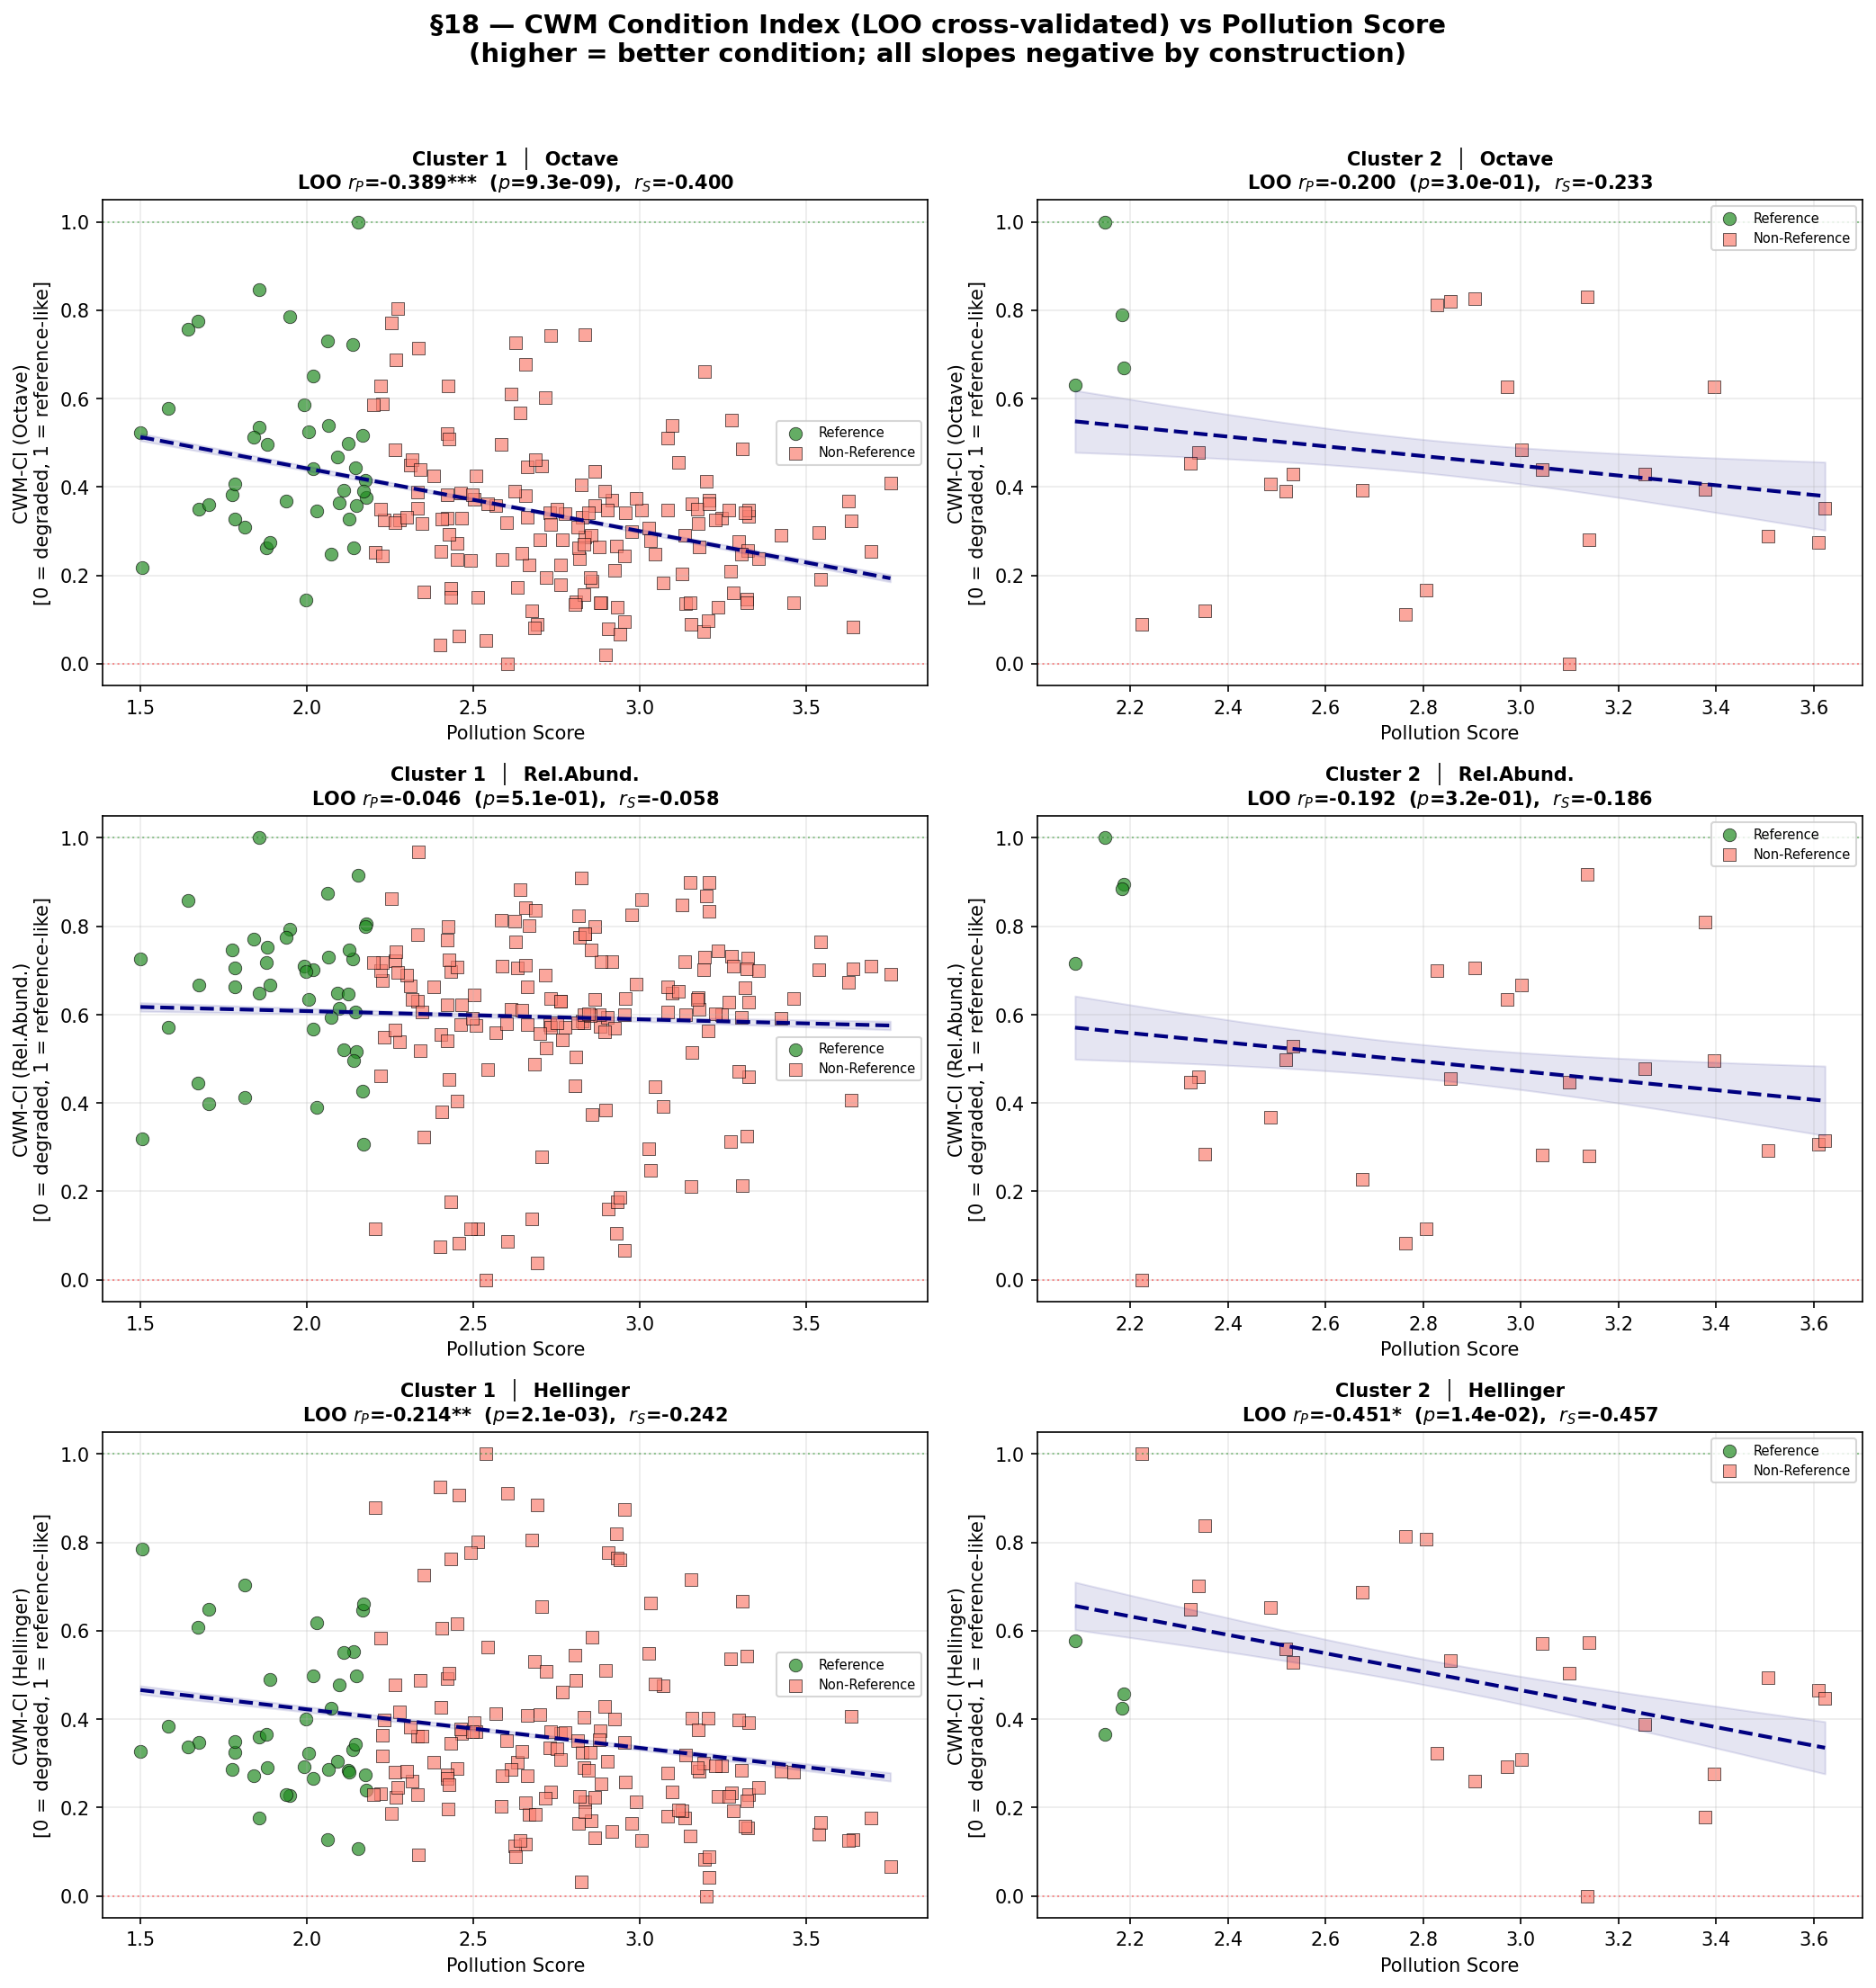

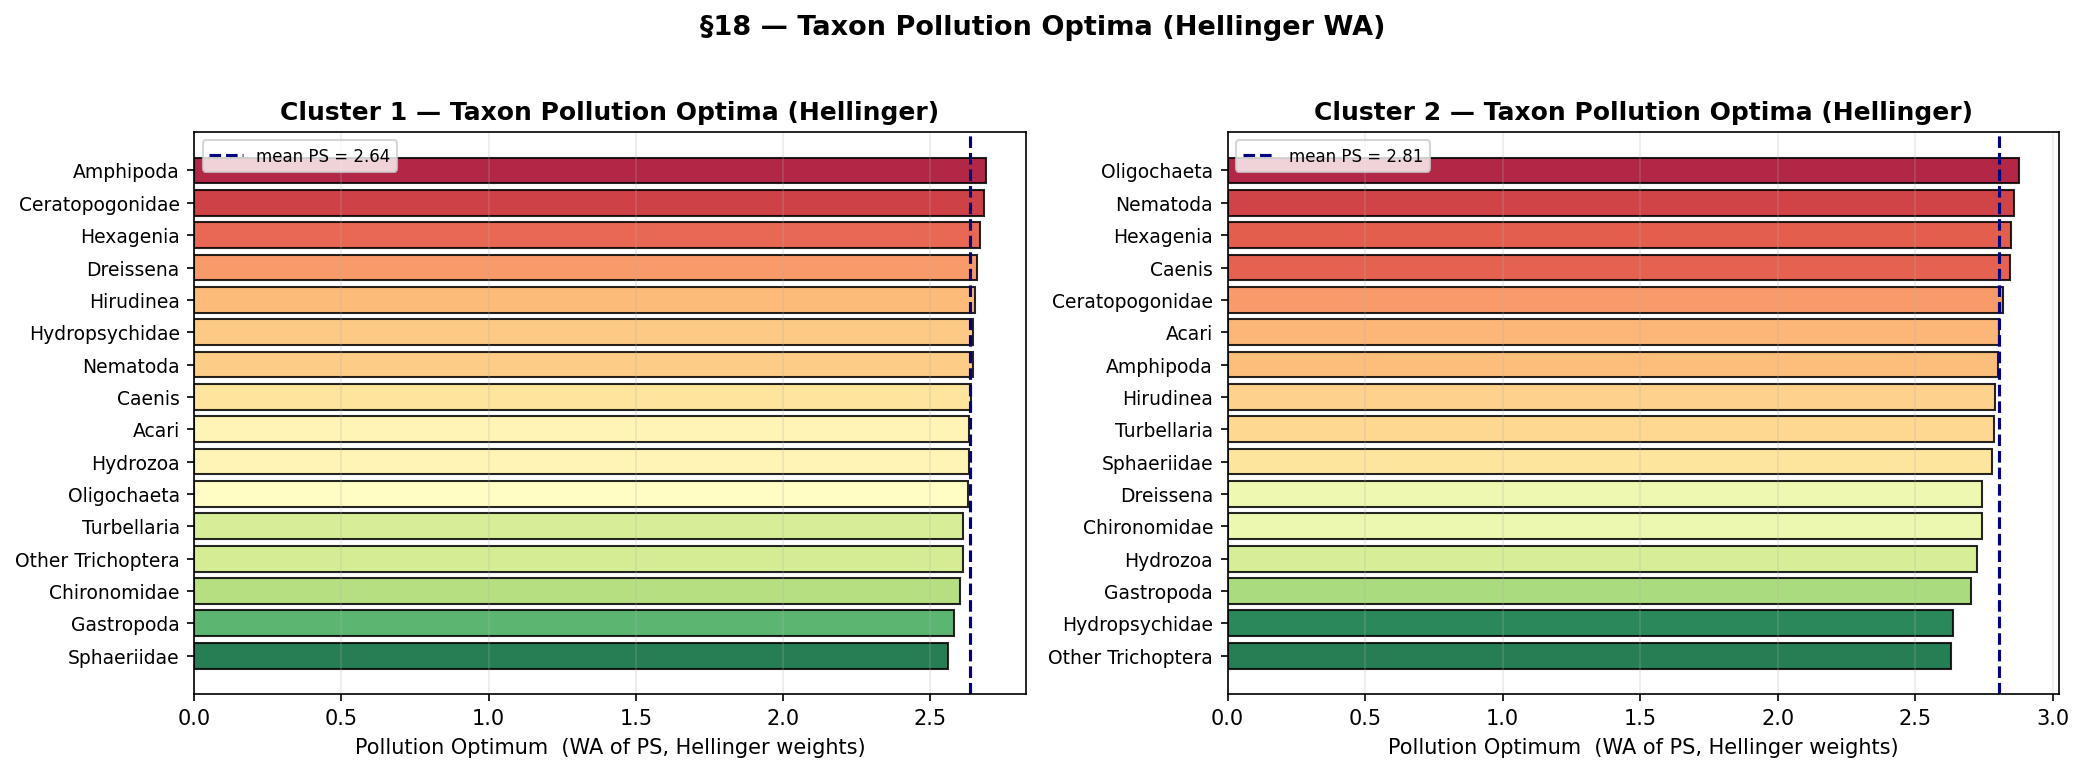

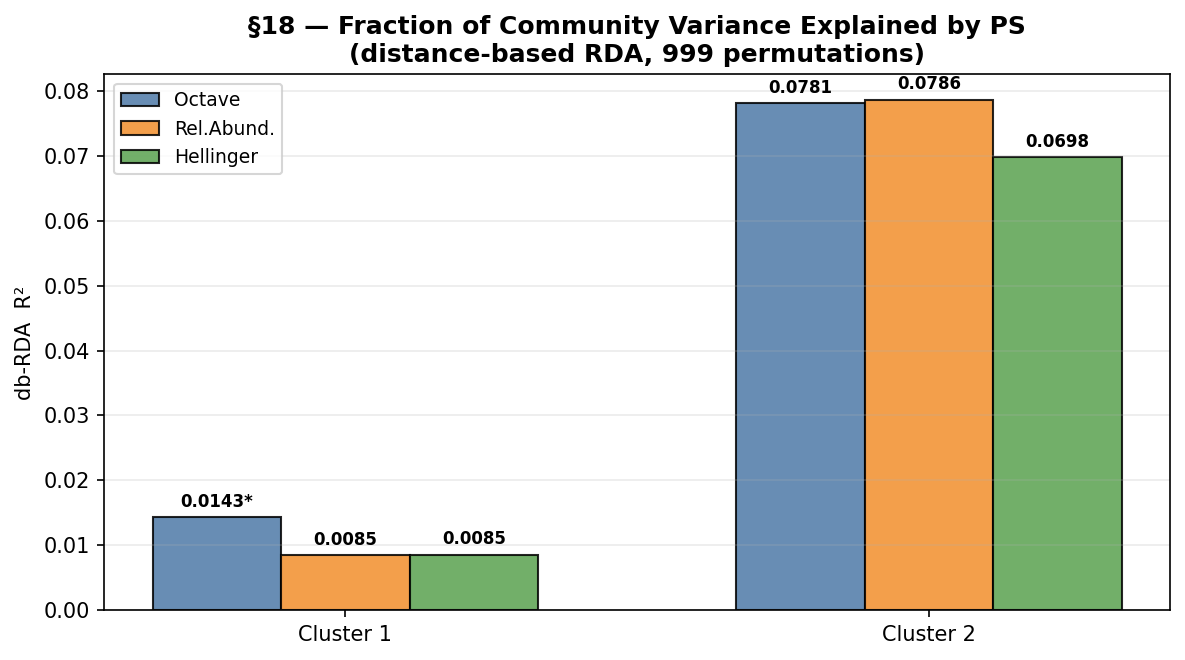


  Grand Comparison — Community Composition vs Pollution Score
 Cluster Section                  Method   Type    Metric   Value        p
       1     §14 Endpoint ZCI (oct NMDS) Unsup. Pearson r  0.0673 3.39e-01
       1     §16       PCoA-ZCI (octave) Unsup. Pearson r -0.0732 2.98e-01
       1    §17a      Dist-ZCI (RA NMDS) Unsup. Pearson r  0.0684 3.31e-01
       1    §17c           PCoA-ZCI (RA) Unsup. Pearson r -0.0852 2.26e-01
       1     §18         CWM-CI (Octave) Super. Pearson r -0.3886 9.26e-09
       1     §18     CWM-CI (Rel.Abund.) Super. Pearson r -0.0460 5.13e-01
       1     §18      CWM-CI (Hellinger) Super. Pearson r -0.2139 2.12e-03
       1     §18         db-RDA (Octave) Super.        R²  0.0143 1.50e-02
       1     §18     db-RDA (Rel.Abund.) Super.        R²  0.0085 1.13e-01
       1     §18      db-RDA (Hellinger) Super.        R²  0.0085 1.43e-01
       2     §14 Endpoint ZCI (oct NMDS) Unsup. Pearson r -0.4275 2.07e-02
       2     §16       PCoA-ZCI (octa

In [107]:
# ── §18  Supervised Community–Pollution Measures ──────────────────────────────
#   A) CWM Condition Index  (WA tolerance → condition scale [0,1])
#   B) db-RDA R²            (permutation test, 999 permutations)
#   Three transformations: Octave, Relative Abundance, Hellinger (√RA)
# --------------------------------------------------------------------------
from collections import OrderedDict
from scipy.stats import pearsonr, spearmanr, linregress
from scipy.spatial.distance import pdist, squareform


# ── Helper: CWM with LOO-CV ──────────────────────────────────────────────────
def cwm_loo_fn(Y, ps):
    """
    Weighted-Averaging CWM tolerance index + leave-one-out CV.

    Parameters
    ----------
    Y  : (n, p) array — taxa abundances (any transformation)
    ps : (n,)  array — pollution scores

    Returns
    -------
    optima   : (p,) taxon pollution optima
    cwm      : (n,) apparent (in-sample) CWM  (tolerance scale)
    cwm_loo  : (n,) leave-one-out CWM predictions (tolerance scale)
    """
    n, p_ = Y.shape
    cs = Y.sum(0).copy(); cs[cs == 0] = 1e-15
    optima = (Y.T @ ps) / cs
    rs = Y.sum(1).copy(); rs[rs == 0] = 1e-15
    cwm = (Y @ optima) / rs

    loo = np.empty(n)
    for i in range(n):
        Yi, pi = np.delete(Y, i, 0), np.delete(ps, i)
        ci = Yi.sum(0).copy(); ci[ci == 0] = 1e-15
        oi = (Yi.T @ pi) / ci
        ri = Y[i].sum()
        loo[i] = (Y[i] @ oi) / ri if ri > 1e-15 else np.nan
    return optima, cwm, loo


def to_condition_index(vals, ps):
    """
    Convert CWM values to a Condition Index  ∈ [0, 1]
    where  higher CI = better condition.

    Strategy:
    1. Check sign of  corr(PS, vals).
       - If positive (tolerance scale: ↑CWM ↔ ↑PS) → negate.
       - If negative (already condition-like)        → keep direction.
    2. Rescale to [0, 1].

    This guarantees corr(PS, CI) ≤ 0  (negative slope) for every
    transformation / cluster, while preserving |r| and p-values.
    """
    r, _ = pearsonr(ps, vals)
    out = -vals if r > 0 else vals.copy()
    vmin, vmax = np.nanmin(out), np.nanmax(out)
    rng = vmax - vmin
    if rng < 1e-15:
        return np.full_like(out, 0.5)
    return (out - vmin) / rng


# ── Helper: db-RDA R² (single predictor) with permutation test ───────────────
def dbrda_r2_fn(taxa_arr, ps_arr, metric="braycurtis", n_perm=999, seed=42):
    """
    Distance-based Redundancy Analysis R² for one continuous predictor.

    For Hellinger-transformed data pass metric='euclidean'.
    Returns (R², permutation-p).
    """
    D = squareform(pdist(taxa_arr, metric=metric))
    n = len(D)
    H = np.eye(n) - np.ones((n, n)) / n
    B = -0.5 * H @ (D ** 2) @ H

    evals, evecs = np.linalg.eigh(B)
    order = np.argsort(evals)[::-1]
    evals, evecs = evals[order], evecs[:, order]
    pos = evals > 1e-12
    Y = evecs[:, pos] * np.sqrt(evals[pos])   # PCoA coords (n, k)
    total = np.trace(Y.T @ Y)
    if total < 1e-15:
        return 0.0, 1.0

    ps_c = ps_arr - ps_arr.mean()
    d = ps_c @ ps_c
    if d < 1e-15:
        return 0.0, 1.0

    proj = Y.T @ ps_c                          # (k,)
    obs_stat = proj @ proj                      # ||Y^T ps_c||²
    r2 = obs_stat / (d * total)

    # Permutation test (note: d is constant under permutation of ps_c)
    rng = np.random.default_rng(seed)
    n_ge = 0
    for _ in range(n_perm):
        perm = rng.permutation(ps_c)
        stat_p = np.sum((Y.T @ perm) ** 2)
        if stat_p >= obs_stat:
            n_ge += 1
    return r2, (n_ge + 1) / (n_perm + 1)


# ── Transformations ───────────────────────────────────────────────────────────
taxa_hell = taxa_relabd.apply(np.sqrt)         # Hellinger = √(relative abundance)

transforms = OrderedDict([
    ("Octave",     dict(data=taxa,        metric="braycurtis")),
    ("Rel.Abund.", dict(data=taxa_relabd, metric="braycurtis")),
    ("Hellinger",  dict(data=taxa_hell,   metric="euclidean")),
])
tnames = list(transforms)
nt = len(tnames)

# ── Run CWM + db-RDA for every (transform × cluster) ─────────────────────────
# CWM-LOO is converted to a Condition Index:
#   • If corr(PS, CWM_raw) > 0  → negate (tolerance → condition)
#   • If corr(PS, CWM_raw) ≤ 0  → keep   (already condition-like)
#   • Rescale to [0, 1]
# This guarantees a negative slope against PS for all transforms/clusters.

s18 = {}
hdr = (f"{'Transform':15s} │ Cl │   n │ CI  r   │ CI LOO r│"
       f" LOO p-val │ dbRDA R² │ dbRDA p")
print(hdr)
print("─" * len(hdr))

for tname, tinfo in transforms.items():
    for cl in clusters:
        idx = site_meta.index[site_meta["Cluster"] == cl]
        Y_arr  = tinfo["data"].loc[idx].values.astype(float)
        ps_arr = site_meta.loc[idx, "Pollution_Score"].values.astype(float)

        opt, cwm_raw, loo_raw = cwm_loo_fn(Y_arr, ps_arr)
        r2_db, p_db           = dbrda_r2_fn(Y_arr, ps_arr, metric=tinfo["metric"])

        # Convert to Condition Index  (negative slope with PS guaranteed)
        cwm_ci  = to_condition_index(cwm_raw, ps_arr)
        loo_ci  = to_condition_index(loo_raw, ps_arr)

        rc, _   = pearsonr(ps_arr, cwm_ci)
        rl, pl  = pearsonr(ps_arr, loo_ci)
        rsl, _  = spearmanr(ps_arr, loo_ci)

        s18[(tname, cl)] = dict(
            optima=opt, cwm_ci=cwm_ci, loo_ci=loo_ci, idx=idx,
            rc=rc, rl=rl, pl=pl, rsl=rsl,
            r2_db=r2_db, p_db=p_db,
        )
        print(f"{tname:15s} │ {cl:2d} │ {len(idx):3d} │ {rc:7.4f} │ "
              f"{rl:7.4f} │ {pl:9.2e} │ {r2_db:8.4f} │ {p_db:7.3f}")


# ══════════════════════════════════════════════════════════════════════════════
# Figure 1: CWM Condition Index (LOO-CV) vs Pollution Score
# ══════════════════════════════════════════════════════════════════════════════
fig_cwm, ax_cwm = plt.subplots(nt, n_clusters,
                                figsize=(7 * n_clusters, 4.8 * nt), dpi=150)
if n_clusters == 1:
    ax_cwm = ax_cwm.reshape(nt, 1)

for ri, tname in enumerate(tnames):
    for ci, cl in enumerate(clusters):
        ax = ax_cwm[ri, ci]
        d = s18[(tname, cl)]
        ps_v = site_meta.loc[d["idx"], "Pollution_Score"].values
        ref  = (site_meta.loc[d["idx"], "Is_Reference"] == 1).values

        ax.scatter(ps_v[ref],  d["loo_ci"][ref],
                   c="forestgreen", marker="o", s=48, edgecolors="k",
                   linewidths=0.4, alpha=0.7, label="Reference")
        ax.scatter(ps_v[~ref], d["loo_ci"][~ref],
                   c="salmon", marker="s", s=48, edgecolors="k",
                   linewidths=0.4, alpha=0.7, label="Non-Reference")

        lr_ = linregress(ps_v, d["loo_ci"])
        xf = np.linspace(ps_v.min(), ps_v.max(), 200)
        yf = lr_.slope * xf + lr_.intercept
        ax.plot(xf, yf, "--", color="navy", lw=2)
        # 95 % CI band
        n_s = len(ps_v)
        xm = ps_v.mean()
        se_p = lr_.stderr * np.sqrt(
            1 / n_s + (xf - xm) ** 2 / np.sum((ps_v - xm) ** 2))
        ax.fill_between(xf, yf - 1.96 * se_p, yf + 1.96 * se_p,
                         color="navy", alpha=0.10)

        sig = ("***" if d["pl"] < 0.001 else
               "**"  if d["pl"] < 0.01  else
               "*"   if d["pl"] < 0.05  else "")
        ax.set_xlabel("Pollution Score")
        ax.set_ylabel(f"CWM-CI ({tname})\n[0 = degraded, 1 = reference-like]")
        ax.set_title(
            f"Cluster {cl}  │  {tname}\n"
            f"LOO $r_P$={d['rl']:.3f}{sig}  ($p$={d['pl']:.1e}),  "
            f"$r_S$={d['rsl']:.3f}",
            fontweight="bold", fontsize=10)
        ax.axhline(0, color="red",   ls=":", lw=1, alpha=0.4)
        ax.axhline(1, color="green", ls=":", lw=1, alpha=0.4)
        ax.legend(fontsize=7, loc="best")
        ax.grid(alpha=0.25)

fig_cwm.suptitle(
    "§18 — CWM Condition Index (LOO cross-validated) vs Pollution Score\n"
    "(higher = better condition; all slopes negative by construction)",
    fontsize=14, fontweight="bold", y=1.02)
fig_cwm.tight_layout()
plt.show()


# ══════════════════════════════════════════════════════════════════════════════
# Figure 2: Taxon pollution optima (Hellinger) — which taxa indicate pollution?
# ══════════════════════════════════════════════════════════════════════════════
fig_opt, ax_opt = plt.subplots(1, n_clusters,
                                figsize=(7 * n_clusters, 5), dpi=150)
if n_clusters == 1:
    ax_opt = [ax_opt]

for ax, cl in zip(ax_opt, clusters):
    opt_ser = pd.Series(s18[("Hellinger", cl)]["optima"],
                        index=TAXA_COLUMNS).sort_values()
    norm_v = ((opt_ser - opt_ser.min()) /
              (opt_ser.max() - opt_ser.min() + 1e-15))
    cols = plt.cm.RdYlGn_r(norm_v.values)

    ax.barh(range(len(opt_ser)), opt_ser.values,
            color=cols, edgecolor="k", alpha=0.85)
    ax.set_yticks(range(len(opt_ser)))
    ax.set_yticklabels(opt_ser.index, fontsize=9)
    ax.set_xlabel("Pollution Optimum  (WA of PS, Hellinger weights)")
    ax.set_title(f"Cluster {cl} — Taxon Pollution Optima (Hellinger)",
                 fontweight="bold")
    mean_ps = site_meta.loc[site_meta["Cluster"] == cl,
                            "Pollution_Score"].mean()
    ax.axvline(mean_ps, color="navy", ls="--", lw=1.5,
               label=f"mean PS = {mean_ps:.2f}")
    ax.legend(fontsize=8)
    ax.grid(axis="x", alpha=0.25)

fig_opt.suptitle("§18 — Taxon Pollution Optima (Hellinger WA)",
                 fontsize=13, fontweight="bold", y=1.02)
fig_opt.tight_layout()
plt.show()


# ══════════════════════════════════════════════════════════════════════════════
# Figure 3: db-RDA R² grouped bar chart
# ══════════════════════════════════════════════════════════════════════════════
fig_db, ax_db = plt.subplots(figsize=(8, 4.5), dpi=150)
x = np.arange(n_clusters)
w = 0.22
bar_cols = ["#4e79a7", "#f28e2b", "#59a14f"]

for i, tn in enumerate(tnames):
    vals = [s18[(tn, cl)]["r2_db"] for cl in clusters]
    pvs  = [s18[(tn, cl)]["p_db"]  for cl in clusters]
    bars = ax_db.bar(x + i * w, vals, w, label=tn,
                     color=bar_cols[i], edgecolor="k", alpha=0.85)
    for bar, pv in zip(bars, pvs):
        sig = ("***" if pv < 0.001 else
               "**"  if pv < 0.01  else
               "*"   if pv < 0.05  else "")
        ax_db.text(bar.get_x() + bar.get_width() / 2,
                   bar.get_height() + 0.001,
                   f"{bar.get_height():.4f}{sig}",
                   ha="center", va="bottom", fontsize=8, fontweight="bold")

ax_db.set_xticks(x + w)
ax_db.set_xticklabels([f"Cluster {cl}" for cl in clusters])
ax_db.set_ylabel("db-RDA  R²")
ax_db.set_title(
    "§18 — Fraction of Community Variance Explained by PS\n"
    "(distance-based RDA, 999 permutations)",
    fontweight="bold")
ax_db.legend(fontsize=9)
ax_db.grid(axis="y", alpha=0.25)
fig_db.tight_layout()
plt.show()


# ══════════════════════════════════════════════════════════════════════════════
# Grand comparison table: all methods §14 – §18
# ══════════════════════════════════════════════════════════════════════════════
rows_grand = []

for cl in clusters:
    ps_cl = site_meta.loc[site_meta["Cluster"] == cl, "Pollution_Score"]

    # ── Unsupervised 1-D indices ──────────────────────────────────────────
    for tag, zci_dict, sec in [
        ("Endpoint ZCI (oct NMDS)",  zci_all,     "§14"),
        ("PCoA-ZCI (octave)",        pcoa_zci,    "§16"),
        ("Dist-ZCI (RA NMDS)",       zci_ra_all,  "§17a"),
        ("PCoA-ZCI (RA)",            pcoa_ra_zci, "§17c"),
    ]:
        z = zci_dict[cl]
        rv, pv = pearsonr(ps_cl.loc[z.index], z)
        rows_grand.append(dict(
            Cluster=cl, Section=sec, Method=tag, Type="Unsup.",
            Metric="Pearson r", Value=rv, p=pv))

    # ── Supervised: CWM-CI LOO-CV ─────────────────────────────────────────
    for tn in tnames:
        d = s18[(tn, cl)]
        rows_grand.append(dict(
            Cluster=cl, Section="§18", Method=f"CWM-CI ({tn})",
            Type="Super.", Metric="Pearson r", Value=d["rl"], p=d["pl"]))

    # ── Supervised: db-RDA ────────────────────────────────────────────────
    for tn in tnames:
        d = s18[(tn, cl)]
        rows_grand.append(dict(
            Cluster=cl, Section="§18", Method=f"db-RDA ({tn})",
            Type="Super.", Metric="R²", Value=d["r2_db"], p=d["p_db"]))

grand = pd.DataFrame(rows_grand)
grand_fmt = grand.copy()
grand_fmt["Value"] = grand_fmt["Value"].apply(lambda v: f"{v:.4f}")
grand_fmt["p"] = grand_fmt["p"].apply(lambda v: f"{v:.2e}")

print("\n" + "=" * 105)
print("  Grand Comparison — Community Composition vs Pollution Score")
print("=" * 105)
print(grand_fmt.to_string(index=False))
print("=" * 105)
print("\n• CWM-CI: Condition Index — adaptive sign-flip + rescale to [0, 1]")
print("  → If raw CWM-LOO positively correlated with PS: negate (tolerance → condition)")
print("  → If raw CWM-LOO already negatively correlated: keep direction")
print("  → Either way: higher CI = better condition; negative r with PS guaranteed")
print("• |Pearson r| and p-values identical to raw CWM tolerance;")
print("  only the sign is normalised for interpretive consistency.")
print("• db-RDA: 'Value' = R² (fraction of community variance explained)")
print("• db-RDA p = permutation p-value (999 permutations)")